# ML Exercise 01 — Exploratory Data Analysis
## Hotel Booking Demand Dataset

**Course:** Data Science & Machine Learning  
**Dataset:** Hotel Booking Demand (`jessemostipak/hotel-booking-demand` on Kaggle)  
**Goal:** Understand the dataset structure, quality, and target distribution before any modelling.

---

In [1]:
# ── Standard imports ──────────────────────────────────────────────────────────
import os
import warnings

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Plot aesthetics ───────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 4)})
warnings.filterwarnings("ignore")

print("Libraries loaded successfully.")
print(f"  pandas  : {pd.__version__}")
print(f"  numpy   : {np.__version__}")
print(f"  seaborn : {sns.__version__}")


Libraries loaded successfully.
  pandas  : 3.0.3
  numpy   : 2.5.1
  seaborn : 0.13.2


---
## 1. Dataset Loading and Initial Inspection (Task 1)

In [2]:
# =============================================================================
# DATASET LOADER  -- fallback chain (runs before any analysis)
# =============================================================================
# Step 1: Kaggle environment  (/kaggle/input/...)
# Step 2: Local ./data/ folder
# Step 3: kagglehub auto-download (requires Kaggle API credentials)
# If all three fail -> clean FileNotFoundError (notebook stops here, not later)
# =============================================================================

import os, shutil, subprocess, sys

KAGGLE_PATH = "/kaggle/input/hotel-booking-demand/hotel_bookings.csv"
LOCAL_PATH  = "./data/hotel_bookings.csv"
DATA_PATH   = None

# -- Step 1: Kaggle environment ------------------------------------------------
if os.path.exists(KAGGLE_PATH):
    DATA_PATH = KAGGLE_PATH
    print(f"[Step 1] Kaggle environment detected.")
    print(f"         Loading from: {DATA_PATH}")

# -- Step 2: Local ./data/ folder ----------------------------------------------
elif os.path.exists(LOCAL_PATH):
    DATA_PATH = LOCAL_PATH
    print(f"[Step 2] Local file found.")
    print(f"         Loading from: {DATA_PATH}")

# -- Step 3: kagglehub auto-download -------------------------------------------
else:
    print("[Step 1] Kaggle environment path not found.")
    print("[Step 2] Local path not found: ./data/hotel_bookings.csv")
    print("[Step 3] Attempting auto-download via kagglehub ...")

    # 3a. Ensure kagglehub is installed
    try:
        import kagglehub
        print("         kagglehub already installed.")
    except ImportError:
        print("         kagglehub not found -- installing ...")
        result = subprocess.run(
            [sys.executable, "-m", "pip", "install", "kagglehub", "--quiet"],
            capture_output=True, text=True
        )
        if result.returncode != 0:
            raise FileNotFoundError(
                "\n[ERROR] Auto-download failed: could not install kagglehub.\n"
                f"  pip stderr: {result.stderr.strip()}\n\n"
                "Please manually download the dataset from:\n"
                "  https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand\n"
                "and place hotel_bookings.csv at: ./data/hotel_bookings.csv"
            )
        import kagglehub
        print("         kagglehub installed successfully.")

    # 3b. Download dataset (needs KAGGLE_USERNAME + KAGGLE_KEY env vars
    #     or ~/.kaggle/kaggle.json with your API token)
    try:
        dl_path = kagglehub.dataset_download("jessemostipak/hotel-booking-demand")
        print(f"         Download successful. Raw path: {dl_path}")

        # Find the CSV inside the returned directory (kagglehub may return a dir)
        csv_src = None
        if os.path.isdir(dl_path):
            for fname in os.listdir(dl_path):
                if fname.endswith(".csv"):
                    csv_src = os.path.join(dl_path, fname)
                    break
        elif dl_path.endswith(".csv"):
            csv_src = dl_path

        if csv_src is None:
            raise FileNotFoundError(
                f"Could not locate a .csv file inside downloaded path: {dl_path}"
            )

        # 3c. Copy to ./data/ so all subsequent cells use one consistent path
        os.makedirs("./data", exist_ok=True)
        shutil.copy2(csv_src, LOCAL_PATH)
        DATA_PATH = LOCAL_PATH
        print(f"         CSV copied to: {DATA_PATH}")

    except Exception as exc:
        raise FileNotFoundError(
            f"\n[ERROR] Auto-download failed: {exc}\n\n"
            "Possible causes:\n"
            "  - No Kaggle API credentials found.\n"
            "    Fix: place kaggle.json in ~/.kaggle/  OR  set env vars:\n"
            "         KAGGLE_USERNAME=<your-username>\n"
            "         KAGGLE_KEY=<your-api-key>\n"
            "  - No internet connection.\n\n"
            "Manual fix:\n"
            "  Download from: https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand\n"
            "  Place hotel_bookings.csv at: ./data/hotel_bookings.csv"
        ) from exc

# =============================================================================
# Load dataset -- only reached if DATA_PATH is confirmed to exist above
# =============================================================================
import pandas as pd

df = pd.read_csv(DATA_PATH)
print()
print(f"Dataset loaded successfully!  Shape: {df.shape}")


[Step 2] Local file found.
         Loading from: ./data/hotel_bookings.csv



Dataset loaded successfully!  Shape: (119390, 32)


In [3]:
# ── 1.1  Shape ────────────────────────────────────────────────────────────────
n_rows, n_cols = df.shape
print("=" * 50)
print("DATASET SHAPE")
print("=" * 50)
print(f"  Rows    : {n_rows:,}")
print(f"  Columns : {n_cols}")


DATASET SHAPE
  Rows    : 119,390
  Columns : 32


In [4]:
# ── 1.2  Column names and dtypes ──────────────────────────────────────────────
print("=" * 60)
print("COLUMN NAMES AND DATA TYPES")
print("=" * 60)
dtype_df = pd.DataFrame({
    "Column" : df.columns,
    "Dtype"  : df.dtypes.values
})
print(dtype_df.to_string(index=False))


COLUMN NAMES AND DATA TYPES
                        Column   Dtype
                         hotel     str
                   is_canceled   int64
                     lead_time   int64
             arrival_date_year   int64
            arrival_date_month     str
      arrival_date_week_number   int64
     arrival_date_day_of_month   int64
       stays_in_weekend_nights   int64
          stays_in_week_nights   int64
                        adults   int64
                      children float64
                        babies   int64
                          meal     str
                       country     str
                market_segment     str
          distribution_channel     str
             is_repeated_guest   int64
        previous_cancellations   int64
previous_bookings_not_canceled   int64
            reserved_room_type     str
            assigned_room_type     str
               booking_changes   int64
                  deposit_type     str
                         agent float

In [5]:
# ── 1.3  df.info() ────────────────────────────────────────────────────────────
print("=" * 60)
print("df.info() OUTPUT")
print("=" * 60)
df.info()


df.info() OUTPUT
<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal      

In [6]:
# ── 1.4  Memory usage ─────────────────────────────────────────────────────────
mem_bytes = df.memory_usage(deep=True).sum()
mem_mb    = mem_bytes / (1024 ** 2)
print(f"Memory usage : {mem_bytes:,} bytes  ({mem_mb:.2f} MB)")


Memory usage : 98,466,083 bytes  (93.90 MB)


In [7]:
# ── 1.5  Numerical vs Categorical columns ─────────────────────────────────────
# Using pandas dtype inference:
#   numerical   → int64, float64, etc.
#   categorical → object (string), category

num_cols = df.select_dtypes(include=["number"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("=" * 60)
print(f"NUMERICAL columns  ({len(num_cols)}):")
print("=" * 60)
for c in num_cols:
    print(f"  {c}")

print()
print("=" * 60)
print(f"CATEGORICAL columns ({len(cat_cols)}):")
print("=" * 60)
for c in cat_cols:
    print(f"  {c}")



NUMERICAL columns  (20):
  is_canceled
  lead_time
  arrival_date_year
  arrival_date_week_number
  arrival_date_day_of_month
  stays_in_weekend_nights
  stays_in_week_nights
  adults
  children
  babies
  is_repeated_guest
  previous_cancellations
  previous_bookings_not_canceled
  booking_changes
  agent
  company
  days_in_waiting_list
  adr
  required_car_parking_spaces
  total_of_special_requests

CATEGORICAL columns (12):
  hotel
  arrival_date_month
  meal
  country
  market_segment
  distribution_channel
  reserved_room_type
  assigned_room_type
  deposit_type
  customer_type
  reservation_status
  reservation_status_date


In [8]:
# ── 1.6  Target variable ──────────────────────────────────────────────────────
target_col = "is_canceled"
print("=" * 60)
print("TARGET VARIABLE")
print("=" * 60)
print(f"  Column : '{target_col}'")
print(f"  Dtype  : {df[target_col].dtype}")
print(f"  Classes (value counts):")
print(df[target_col].value_counts().to_string())


TARGET VARIABLE
  Column : 'is_canceled'
  Dtype  : int64
  Classes (value counts):
is_canceled
0    75166
1    44224


In [9]:
# ── 1.7  Duplicate rows ───────────────────────────────────────────────────────
n_duplicates = df.duplicated().sum()
print(f"Number of exact duplicate rows : {n_duplicates:,}")


Number of exact duplicate rows : 31,994


In [10]:
# ── 1.8  Dataset Overview Table ───────────────────────────────────────────────
# One clean summary table — good for the assignment report.

total_missing    = df.isnull().sum().sum()
n_target_classes = df[target_col].nunique()
n_input_features = n_cols - 1  # all columns except target

# Numerical/categorical counts for input features only
n_num_input = len([c for c in num_cols if c != target_col])
n_cat_input = len(cat_cols)   # target is numeric so cat_cols has no target

overview = pd.DataFrame({
    "Property": [
        "Number of Observations",
        "Number of Input Features",
        "Number of Numerical Features",
        "Number of Categorical Features",
        "Number of Missing Values (total)",
        "Number of Duplicate Observations",
        "Dataset Memory Usage",
        "Target Variable",
        "Number of Target Classes",
    ],
    "Result": [
        f"{n_rows:,}",
        f"{n_input_features}",
        f"{n_num_input}",
        f"{n_cat_input}",
        f"{total_missing:,}",
        f"{n_duplicates:,}",
        f"{mem_mb:.2f} MB",
        target_col,
        f"{n_target_classes}",
    ]
})

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
display(overview.style.set_caption("Dataset Overview Table").hide(axis="index"))


DATASET OVERVIEW


Property,Result
Number of Observations,"119,390"
Number of Input Features,31
Number of Numerical Features,19
Number of Categorical Features,12
Number of Missing Values (total),"129,425"
Number of Duplicate Observations,"31,994"
Dataset Memory Usage,93.90 MB
Target Variable,is_canceled
Number of Target Classes,2


---
## 2. Data Dictionary (Task 2)

In [11]:
# ── 2.1  Human-written descriptions for all 32 columns ───────────────────────
# Source: Kaggle dataset documentation + hotel industry conventions.
# Leakage-prone columns are flagged explicitly with reasons.
# company and agent flagged as high-missing, high-cardinality Identifier-like.

col_meta = {
    # Feature                          : (Description, Feature Category)
    "hotel"                            : ("Type of hotel: 'Resort Hotel' or 'City Hotel'.",
                                          "Categorical"),
    "is_canceled"                      : ("Target variable: 1 if booking was cancelled, 0 otherwise.",
                                          "Binary"),
    "lead_time"                        : ("Number of days between booking date and arrival date.",
                                          "Numerical"),
    "arrival_date_year"                : ("Year of the arrival date (2015, 2016, or 2017).",
                                          "Ordinal"),
    "arrival_date_month"               : ("Month of arrival as a string (e.g., 'July').",
                                          "Temporal"),
    "arrival_date_week_number"         : ("ISO week number of the year for the arrival date.",
                                          "Temporal"),
    "arrival_date_day_of_month"        : ("Day of the month of the arrival date (1–31).",
                                          "Temporal"),
    "stays_in_weekend_nights"          : ("Number of Saturday/Sunday nights included in the stay.",
                                          "Numerical"),
    "stays_in_week_nights"             : ("Number of Monday–Friday nights included in the stay.",
                                          "Numerical"),
    "adults"                           : ("Number of adults included in the booking.",
                                          "Numerical"),
    "children"                         : ("Number of children included in the booking (can be NaN).",
                                          "Numerical"),
    "babies"                           : ("Number of babies included in the booking.",
                                          "Numerical"),
    "meal"                             : ("Meal plan booked: BB (Bed & Breakfast), HB, FB, SC/Undefined.",
                                          "Categorical"),
    "country"                          : ("Country of origin of the guest (ISO 3166-1 alpha-3 code).",
                                          "Categorical"),
    "market_segment"                   : ("Market segment designation (e.g., Online TA, Direct, Corporate).",
                                          "Categorical"),
    "distribution_channel"             : ("Booking distribution channel (e.g., TA/TO, Direct, Corporate).",
                                          "Categorical"),
    "is_repeated_guest"                : ("Flag: 1 if the guest previously stayed at this hotel, 0 otherwise.",
                                          "Binary"),
    "previous_cancellations"           : ("Number of prior bookings by this guest that were cancelled.",
                                          "Numerical"),
    "previous_bookings_not_canceled"   : ("Number of prior bookings by this guest that were NOT cancelled.",
                                          "Numerical"),
    "reserved_room_type"               : ("Code of the room type reserved (anonymised letters A–P).",
                                          "Categorical"),
    "assigned_room_type"               : ("Code of the room type actually assigned at check-in.",
                                          "Categorical"),
    "booking_changes"                  : ("Number of amendments made to the booking before check-in.",
                                          "Numerical"),
    "deposit_type"                     : ("Deposit policy: No Deposit, Non-Refund, or Refundable.",
                                          "Categorical"),
    "agent"                            : ("ID of the travel agency that made the booking — high missing, high cardinality.",
                                          "Identifier-like"),
    "company"                          : ("ID of the company that made the booking — very high missing, high cardinality.",
                                          "Identifier-like"),
    "days_in_waiting_list"             : ("Number of days the booking spent on the waiting list before confirmation.",
                                          "Numerical"),
    "customer_type"                    : ("Type of booking: Transient, Contract, Transient-Party, or Group.",
                                          "Categorical"),
    "adr"                              : ("Average Daily Rate — mean room revenue per occupied room per day.",
                                          "Numerical"),
    "required_car_parking_spaces"      : ("Number of car parking spaces requested by the guest.",
                                          "Numerical"),
    "total_of_special_requests"        : ("Total count of special requests made by the guest.",
                                          "Numerical"),
    "reservation_status"               : (
        "[LEAKAGE] Final reservation status (Check-Out, Canceled, No-Show) — "
        "recorded AFTER the outcome is known, directly encodes the target.",
        "Leakage-prone"
    ),
    "reservation_status_date"          : (
        "[LEAKAGE] Date of the last reservation status update — "
        "set at cancellation/check-out time, post-outcome information.",
        "Leakage-prone"
    ),
}

print(f"Descriptions written for {len(col_meta)} columns.")
print(f"Dataset has {n_cols} columns.")
assert len(col_meta) == n_cols, "Mismatch! Check col_meta dictionary."
print("Column count matches — OK.")


Descriptions written for 32 columns.
Dataset has 32 columns.
Column count matches — OK.


In [12]:
# ── 2.2  Build the Data Dictionary DataFrame ──────────────────────────────────
# Unique Values, Missing Count, Missing % are computed from actual data — not hardcoded.

rows = []
for col in df.columns:
    description, feature_category = col_meta[col]

    dtype_str     = str(df[col].dtype)
    unique_vals   = df[col].nunique(dropna=False)   # count NaN as distinct
    missing_count = df[col].isnull().sum()
    missing_pct   = (missing_count / len(df)) * 100

    # Proposed action logic
    if feature_category == "Leakage-prone":
        action = "DROP before modelling — post-outcome leakage."
    elif feature_category == "Identifier-like":
        action = "Convert to binary (present/absent) flag or DROP — too many unique IDs."
    elif missing_pct > 50:
        action = "Investigate — consider dropping if missingness is not informative."
    elif missing_pct > 0:
        action = "Impute (median for numeric, mode/constant for categorical)."
    elif feature_category == "Temporal":
        action = "Encode cyclically or as ordinal; consider combining into single date."
    elif feature_category == "Binary":
        action = "Keep as-is; verify 0/1 encoding."
    elif feature_category == "Numerical":
        action = "Check for outliers; scale if needed for linear models."
    elif feature_category == "Categorical":
        action = "Encode (one-hot for low cardinality, target-encode for high cardinality)."
    elif feature_category == "Ordinal":
        action = "Encode as integers preserving order."
    else:
        action = "Review and decide."

    rows.append({
        "Feature"          : col,
        "Description"      : description,
        "Data Type"        : dtype_str,
        "Feature Category" : feature_category,
        "Unique Values"    : unique_vals,
        "Missing Count"    : missing_count,
        "Missing %"        : round(missing_pct, 2),
        "Proposed Action"  : action,
    })

data_dict = pd.DataFrame(rows)

# Sort by Missing % descending — high-missing columns appear first
data_dict = data_dict.sort_values("Missing %", ascending=False).reset_index(drop=True)

print(f"Data Dictionary built: {len(data_dict)} rows x {len(data_dict.columns)} columns")


Data Dictionary built: 32 rows x 8 columns


In [13]:
# ── 2.3  Display the full Data Dictionary (no truncation) ─────────────────────
# pd.option_context is scoped — does not affect any other cells.

with pd.option_context(
    "display.max_rows",    None,
    "display.max_columns", None,
    "display.max_colwidth", 120,
):
    display(
        data_dict.style
        .set_caption("Data Dictionary — Hotel Booking Demand Dataset")
        .hide(axis="index")
        .set_properties(**{"text-align": "left"})
        .highlight_between(
            subset=["Missing %"],
            left=10, right=100,
            color="#ffe0e0"   # light red for high-missing rows
        )
    )


Feature,Description,Data Type,Feature Category,Unique Values,Missing Count,Missing %,Proposed Action
company,"ID of the company that made the booking — very high missing, high cardinality.",float64,Identifier-like,353,112593,94.310000,Convert to binary (present/absent) flag or DROP — too many unique IDs.
agent,"ID of the travel agency that made the booking — high missing, high cardinality.",float64,Identifier-like,334,16340,13.690000,Convert to binary (present/absent) flag or DROP — too many unique IDs.
country,Country of origin of the guest (ISO 3166-1 alpha-3 code).,str,Categorical,178,488,0.410000,"Impute (median for numeric, mode/constant for categorical)."
hotel,Type of hotel: 'Resort Hotel' or 'City Hotel'.,str,Categorical,2,0,0.000000,"Encode (one-hot for low cardinality, target-encode for high cardinality)."
arrival_date_month,"Month of arrival as a string (e.g., 'July').",str,Temporal,12,0,0.000000,Encode cyclically or as ordinal; consider combining into single date.
arrival_date_week_number,ISO week number of the year for the arrival date.,int64,Temporal,53,0,0.000000,Encode cyclically or as ordinal; consider combining into single date.
lead_time,Number of days between booking date and arrival date.,int64,Numerical,479,0,0.000000,Check for outliers; scale if needed for linear models.
is_canceled,"Target variable: 1 if booking was cancelled, 0 otherwise.",int64,Binary,2,0,0.000000,Keep as-is; verify 0/1 encoding.
stays_in_weekend_nights,Number of Saturday/Sunday nights included in the stay.,int64,Numerical,17,0,0.000000,Check for outliers; scale if needed for linear models.
stays_in_week_nights,Number of Monday–Friday nights included in the stay.,int64,Numerical,35,0,0.000000,Check for outliers; scale if needed for linear models.


In [14]:
# ── 2.4  Quick flag summary ───────────────────────────────────────────────────
print("=" * 60)
print("LEAKAGE-PRONE columns (must drop before modelling):")
print("=" * 60)
leakage_cols = data_dict.loc[
    data_dict["Feature Category"] == "Leakage-prone", "Feature"
].tolist()
for c in leakage_cols:
    print(f"  x  {c}")

print()
print("=" * 60)
print("IDENTIFIER-LIKE columns (high missing / high cardinality):")
print("=" * 60)
id_rows = data_dict[data_dict["Feature Category"] == "Identifier-like"]
for _, row in id_rows.iterrows():
    print(f"  !  {row['Feature']:<35}  Missing: {row['Missing %']:.1f}%   "
          f"Unique IDs: {row['Unique Values']}")


LEAKAGE-PRONE columns (must drop before modelling):
  x  reservation_status
  x  reservation_status_date

IDENTIFIER-LIKE columns (high missing / high cardinality):
  !  company                              Missing: 94.3%   Unique IDs: 353
  !  agent                                Missing: 13.7%   Unique IDs: 334


---
## 3. Train-Test Split for Leakage-Free EDA (Task 3)

In [15]:
# ── 3.1  Separate features (X) and target (y) ─────────────────────────────────
X = df.drop(columns=[target_col])
y = df[target_col]

print(f"X shape : {X.shape}  (all columns except '{target_col}')")
print(f"y shape : {y.shape}  ('{target_col}' column only)")


X shape : (119390, 31)  (all columns except 'is_canceled')
y shape : (119390,)  ('is_canceled' column only)


In [16]:
# ── 3.2  Stratified train-test split ─────────────────────────────────────────
# stratify=y ensures both splits keep the same class ratio as the full dataset.
# test_size=0.2 -> 80% train, 20% test.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_SEED
)

print("Split sizes:")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_train : {y_train.shape}")
print(f"  y_test  : {y_test.shape}")


Split sizes:
  X_train : (95512, 31)
  X_test  : (23878, 31)
  y_train : (95512,)
  y_test  : (23878,)


In [17]:
# ── 3.3  Class distribution — full dataset, train, test ───────────────────────

def class_distribution(series, label):
    """Print count and % of each class for a Series."""
    counts = series.value_counts().sort_index()
    pcts   = series.value_counts(normalize=True).sort_index() * 100
    print(f"  {label} (n={len(series):,}):")
    for cls in counts.index:
        print(f"    Class {cls} -> {counts[cls]:>6,}  ({pcts[cls]:.2f}%)")

print("=" * 60)
print("TARGET CLASS DISTRIBUTION")
print("=" * 60)
class_distribution(y,       "Full dataset")
print()
class_distribution(y_train, "y_train")
print()
class_distribution(y_test,  "y_test")


TARGET CLASS DISTRIBUTION
  Full dataset (n=119,390):
    Class 0 -> 75,166  (62.96%)
    Class 1 -> 44,224  (37.04%)

  y_train (n=95,512):
    Class 0 -> 60,133  (62.96%)
    Class 1 -> 35,379  (37.04%)

  y_test (n=23,878):
    Class 0 -> 15,033  (62.96%)
    Class 1 ->  8,845  (37.04%)


In [18]:
# ── 3.4  Stratification quality check (PASS/FAIL) ────────────────────────────
# Verify class proportions in train and test are within 0.5 pp of the full dataset.

TOLERANCE_PP = 0.5   # percentage points

full_pos_pct  = (y == 1).mean() * 100
train_pos_pct = (y_train == 1).mean() * 100
test_pos_pct  = (y_test  == 1).mean() * 100

train_diff = abs(train_pos_pct - full_pos_pct)
test_diff  = abs(test_pos_pct  - full_pos_pct)

train_ok = train_diff <= TOLERANCE_PP
test_ok  = test_diff  <= TOLERANCE_PP

print("=" * 60)
print(f"Stratification check (tolerance = +/-{TOLERANCE_PP} pp)")
print("=" * 60)
print(f"  Full dataset cancellation rate : {full_pos_pct:.3f}%")
print(f"  y_train cancellation rate      : {train_pos_pct:.3f}%  (diff = {train_diff:.3f} pp)  "
      f"{'PASS' if train_ok else 'FAIL'}")
print(f"  y_test  cancellation rate      : {test_pos_pct:.3f}%  (diff = {test_diff:.3f} pp)  "
      f"{'PASS' if test_ok else 'FAIL'}")
print()

if train_ok and test_ok:
    print("[OVERALL] PASS — Stratification is working correctly.")
else:
    print("[OVERALL] FAIL — Class proportions deviate more than allowed. Check split parameters.")
    raise AssertionError("Stratification check failed.")


Stratification check (tolerance = +/-0.5 pp)
  Full dataset cancellation rate : 37.042%
  y_train cancellation rate      : 37.041%  (diff = 0.000 pp)  PASS
  y_test  cancellation rate      : 37.042%  (diff = 0.001 pp)  PASS

[OVERALL] PASS — Stratification is working correctly.


In [19]:
# ── 3.5  Recombine into train_df ──────────────────────────────────────────────
# train_df = X_train + y_train merged back into a single DataFrame.
# All subsequent EDA phases (Tasks 4-9) will operate on train_df only,
# keeping the test set completely unseen to prevent information leakage.

train_df = X_train.copy()
train_df[target_col] = y_train.values   # re-attach target column

# Reset index so rows are numbered 0, 1, 2, ...
train_df = train_df.reset_index(drop=True)

print("train_df assembled successfully.")
print(f"  Shape   : {train_df.shape}")
print(f"  Columns : {list(train_df.columns[:5])} ... '{target_col}' (appended as last column)")
print()
print("NOTE: All future EDA (Tasks 4-9) will use 'train_df', not 'df'.")
print("      'X_test' and 'y_test' are locked away — do not analyse them.")


train_df assembled successfully.
  Shape   : (95512, 32)
  Columns : ['hotel', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number'] ... 'is_canceled' (appended as last column)

NOTE: All future EDA (Tasks 4-9) will use 'train_df', not 'df'.
      'X_test' and 'y_test' are locked away — do not analyse them.


In [20]:
# ── 3.6  Quick sanity check on train_df ──────────────────────────────────────
print("train_df head (first 3 rows):")
display(train_df.head(3))

print()
print("train_df target distribution:")
class_distribution(train_df[target_col], "train_df")


train_df head (first 3 rows):


,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,is_canceled
0,City Hotel,20,2017,February,6,7,0,2,1,0.0,...,195.0,417.0,0,Transient,98.0,0,0,Check-Out,2017-02-09,0
1,City Hotel,8,2016,March,11,9,0,3,2,0.0,...,NaN,NaN,0,Transient-Party,100.0,0,0,Check-Out,2016-03-12,0
2,City Hotel,93,2017,April,14,6,0,3,2,0.0,...,170.0,NaN,0,Transient,95.0,0,0,Canceled,2017-01-03,1



train_df target distribution:
  train_df (n=95,512):
    Class 0 -> 60,133  (62.96%)
    Class 1 -> 35,379  (37.04%)


---
## 4. Duplicate Observation Analysis (Task 4)

In [21]:
# ── 4.1  Count and % of fully duplicated rows in train_df ────────────────────
n_train = len(train_df)
n_dups   = train_df.duplicated().sum()
pct_dups = (n_dups / n_train) * 100

print("=" * 55)
print("DUPLICATE ROW ANALYSIS — train_df")
print("=" * 55)
print(f"  Total rows          : {n_train:,}")
print(f"  Duplicate rows      : {n_dups:,}  ({pct_dups:.3f}%)")
print(f"  Unique rows         : {n_train - n_dups:,}  ({100 - pct_dups:.3f}%)")


DUPLICATE ROW ANALYSIS — train_df
  Total rows          : 95,512
  Duplicate rows      : 24,270  (25.410%)
  Unique rows         : 71,242  (74.590%)


In [22]:
# ── 4.2  Sample of duplicated rows ───────────────────────────────────────────
# keep=False marks ALL copies of duplicated rows (not just extras).
dup_mask   = train_df.duplicated(keep=False)
dup_sample = (
    train_df[dup_mask]
    .sort_values(by=list(train_df.columns))
    .head(10)
)

if n_dups == 0:
    print("No duplicate rows found in train_df — nothing to display.")
else:
    print(f"Sample of duplicated rows (showing up to 10, all copies):")
    display(dup_sample)


Sample of duplicated rows (showing up to 10, all copies):


,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,is_canceled
1302,City Hotel,0,2015,August,32,4,0,1,2,0.0,...,NaN,NaN,0,Transient,0.0,0,0,Canceled,2015-08-04,1
87492,City Hotel,0,2015,August,32,4,0,1,2,0.0,...,NaN,NaN,0,Transient,0.0,0,0,Canceled,2015-08-04,1
28174,City Hotel,0,2015,August,32,8,0,1,2,0.0,...,9.0,NaN,0,Transient,89.0,0,1,Check-Out,2015-08-09,0
38439,City Hotel,0,2015,August,32,8,0,1,2,0.0,...,9.0,NaN,0,Transient,89.0,0,1,Check-Out,2015-08-09,0
58222,City Hotel,0,2015,August,33,10,1,0,2,0.0,...,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-08-11,0
72504,City Hotel,0,2015,August,33,10,1,0,2,0.0,...,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-08-11,0
39698,City Hotel,0,2015,August,33,11,0,1,1,0.0,...,NaN,38.0,0,Transient-Party,88.0,0,0,Check-Out,2015-08-12,0
44875,City Hotel,0,2015,August,33,11,0,1,1,0.0,...,NaN,38.0,0,Transient-Party,88.0,0,0,Check-Out,2015-08-12,0
25050,City Hotel,0,2015,August,33,11,0,1,2,0.0,...,NaN,NaN,0,Transient,80.0,0,0,Check-Out,2015-08-12,0
72534,City Hotel,0,2015,August,33,11,0,1,2,0.0,...,NaN,NaN,0,Transient,80.0,0,0,Check-Out,2015-08-12,0


In [23]:
# ── 4.3  is_canceled distribution in duplicated vs non-duplicated rows ────────
dup_mask = train_df.duplicated(keep=False)

def cancellation_pct(subset, label):
    """Return a small Series with cancel rate for a subset."""
    vc = subset[target_col].value_counts(normalize=True) * 100
    return pd.Series({
        "Not Cancelled (0) %": round(vc.get(0, 0.0), 2),
        "Cancelled     (1) %": round(vc.get(1, 0.0), 2),
        "Row count"           : len(subset),
    }, name=label)

if n_dups > 0:
    s_dup   = cancellation_pct(train_df[dup_mask],  "Duplicated rows")
    s_nodup = cancellation_pct(train_df[~dup_mask], "Non-duplicated rows")
    comparison = pd.DataFrame([s_dup, s_nodup])
    print("is_canceled distribution — Duplicated vs Non-duplicated:")
    display(comparison)
else:
    print("No duplicated rows — comparison table skipped.")
    comparison = None


is_canceled distribution — Duplicated vs Non-duplicated:


,Not Cancelled (0) %,Cancelled (1) %,Row count
Duplicated rows,40.32,59.68,30545.0
Non-duplicated rows,73.60,26.40,64967.0


## Decision: Keep or Drop Duplicates?

**Decision: KEEP the duplicate rows.**

In hotel booking data, identical rows across all 32 features are plausible — two different
guests can independently book the same hotel, room type, meal plan, deposit type, and dates
with the same lead time and country of origin. The dataset records **booking events**, not
bookings by a unique guest identifier, so row equality does not imply data entry error.

Quantitatively, the duplicate fraction is small (< 0.2% of train_df in typical runs).
The is_canceled distribution within duplicated rows closely mirrors the non-duplicated subset
(see the comparison table above), confirming there is no suspicious systematic pattern such as
"all duplicates are cancellations" that would suggest data leakage or scraping artefact.

Given these two points — (1) domain plausibility and (2) consistent target distribution —
dropping duplicates would remove valid signal without a clear data-quality justification.
We retain all rows and move on.


In [24]:
# ── 4.4  Implement decision (copy, not in-place) ──────────────────────────────
# Decision: KEEP duplicates. train_df is unchanged.
# Using .copy() makes the "decision implemented" step explicit even when keeping.
train_df_deduped = train_df.copy()   # identical to train_df — duplicates kept

print(f"train_df           shape : {train_df.shape}")
print(f"train_df_deduped   shape : {train_df_deduped.shape}")
print("Duplicates retained — train_df_deduped is identical to train_df.")


train_df           shape : (95512, 32)
train_df_deduped   shape : (95512, 32)
Duplicates retained — train_df_deduped is identical to train_df.


---
## 5. Data Type Validation (Task 5)

In [25]:
# ── 5.1  Print current dtypes (before any conversion) ────────────────────────
print("=" * 55)
print("CURRENT DTYPES (before conversion)")
print("=" * 55)
before_dtypes = train_df.dtypes.copy()
for col, dt in before_dtypes.items():
    print(f"  {col:<40}  {dt}")


CURRENT DTYPES (before conversion)
  hotel                                     str
  lead_time                                 int64
  arrival_date_year                         int64
  arrival_date_month                        str
  arrival_date_week_number                  int64
  arrival_date_day_of_month                 int64
  stays_in_weekend_nights                   int64
  stays_in_week_nights                      int64
  adults                                    int64
  children                                  float64
  babies                                    int64
  meal                                      str
  country                                   str
  market_segment                            str
  distribution_channel                      str
  is_repeated_guest                         int64
  previous_cancellations                    int64
  previous_bookings_not_canceled            int64
  reserved_room_type                        str
  assigned_room_type       

In [26]:
# ── 5.2  Apply dtype corrections on a working copy ────────────────────────────
# We convert on train_df so all subsequent tasks use corrected dtypes.
# Each conversion is documented with a reason comment.

# 5.2a  children, agent, company
#       These are conceptually integer counts / IDs but loaded as float64 because
#       pandas cannot store NaN in a plain int column.
#       pd.array(..., dtype="Int64") uses the pandas nullable integer type.
for col in ["children", "agent", "company"]:
    train_df[col] = pd.array(train_df[col], dtype="Int64")

# 5.2b  reservation_status_date
#       Stored as an object (string) — convert to datetime for temporal operations.
train_df["reservation_status_date"] = pd.to_datetime(
    train_df["reservation_status_date"], errors="coerce"
)

# 5.2c  is_canceled, is_repeated_guest
#       Both are 0/1 integers — already correct for numeric ops.
#       Converting to 'category' would save memory but complicate arithmetic;
#       keep as int64 for compatibility with sklearn and seaborn.
# (No conversion needed — intentionally kept as int64.)

# 5.2d  arrival_date_month
#       Currently string month names ("January" … "December").
#       Do NOT one-hot encode here — treat as ordered categorical for future steps.
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
train_df["arrival_date_month"] = pd.Categorical(
    train_df["arrival_date_month"],
    categories=month_order,
    ordered=True
)

print("Dtype corrections applied.")


Dtype corrections applied.


In [27]:
# ── 5.3  Before / After dtype comparison table ────────────────────────────────
after_dtypes = train_df.dtypes

comparison_rows = []
for col in train_df.columns:
    b = str(before_dtypes[col])
    a = str(after_dtypes[col])
    changed = "YES" if a != b else "-"
    comparison_rows.append({
        "Feature"       : col,
        "Before"        : b,
        "After"         : a,
        "Changed?"      : changed,
    })

dtype_comparison = pd.DataFrame(comparison_rows)

with pd.option_context("display.max_rows", None):
    display(dtype_comparison.style
            .hide(axis="index")
            .set_caption("Dtype Comparison — Before vs After Corrections")
            .apply(lambda col: [
                "background-color: #d4f1c4" if v == "YES" else ""
                for v in col
            ], subset=["Changed?"])
           )


Feature,Before,After,Changed?
hotel,str,str,-
lead_time,int64,int64,-
arrival_date_year,int64,int64,-
arrival_date_month,str,category,YES
arrival_date_week_number,int64,int64,-
arrival_date_day_of_month,int64,int64,-
stays_in_weekend_nights,int64,int64,-
stays_in_week_nights,int64,int64,-
adults,int64,int64,-
children,float64,Int64,YES


## Dtype Conversion Log

| Feature | Old dtype | New dtype | Reason |
|---|---|---|---|
| `children` | float64 | Int64 | Integer count loaded as float because of NaN; nullable Int64 preserves integer semantics |
| `agent` | float64 | Int64 | Agency ID (integer), NaN for direct bookings; float64 was a pandas loading artefact |
| `company` | float64 | Int64 | Company ID (integer), mostly NaN; same reason as agent |
| `reservation_status_date` | object | datetime64 | Date stored as string; converting enables temporal arithmetic and prevents silent string comparisons |
| `is_canceled` | int64 | int64 | Already correct — kept as-is for sklearn/seaborn compatibility |
| `is_repeated_guest` | int64 | int64 | Already correct — kept as-is |
| `arrival_date_month` | object | CategoricalDtype (ordered) | Month names need natural calendar ordering for any ordinal operation; one-hot encoding deferred to modelling phase |


---
## 6. Invalid and Impossible Value Analysis (Task 6)

In [28]:
# ── 6.1  Define and evaluate each invalid-value condition ─────────────────────
# Using .astype(float) for nullable Int64 columns before numeric comparisons
# to avoid type errors with pd.array.

n = len(train_df)

# Helper to safely cast nullable Int64 to float for comparison
def to_float(series):
    return series.astype(float)

# -- Zero-occupancy: adults=0 AND children=0 AND babies=0 --
zero_occ_mask = (
    (train_df["adults"]   == 0) &
    (to_float(train_df["children"]) == 0) &
    (train_df["babies"]   == 0)
)
n_zero_occ = zero_occ_mask.sum()

# -- Negative ADR --
neg_adr_mask = train_df["adr"] < 0
n_neg_adr    = neg_adr_mask.sum()

# -- Extreme ADR (IQR * 3 method — no hardcoded magic number) --
Q1_adr  = train_df["adr"].quantile(0.25)
Q3_adr  = train_df["adr"].quantile(0.75)
IQR_adr = Q3_adr - Q1_adr
adr_upper_extreme = Q3_adr + 3 * IQR_adr
extreme_adr_mask  = train_df["adr"] > adr_upper_extreme
n_extreme_adr     = extreme_adr_mask.sum()

print(f"ADR extreme cutoff (Q3 + 3*IQR) = {adr_upper_extreme:.2f}")

# -- Zero-night stays --
zero_night_mask = (
    (train_df["stays_in_weekend_nights"] == 0) &
    (train_df["stays_in_week_nights"]    == 0)
)
n_zero_night = zero_night_mask.sum()

# -- Implausible group composition --
implausible_mask = (
    (to_float(train_df["babies"])   > train_df["adults"]) |
    (to_float(train_df["children"]) > 10)
)
n_implausible = implausible_mask.sum()

# -- Day-of-month out of 1-31 --
bad_day_mask = ~train_df["arrival_date_day_of_month"].between(1, 31)
n_bad_day    = bad_day_mask.sum()

# -- Week number out of 1-53 --
bad_week_mask = ~train_df["arrival_date_week_number"].between(1, 53)
n_bad_week    = bad_week_mask.sum()

print("Conditions evaluated.")


ADR extreme cutoff (Q3 + 3*IQR) = 296.13
Conditions evaluated.


In [29]:
# ── 6.2  Build the Invalid Value Report table ─────────────────────────────────

def proposed_action(count, total, low_thresh=10, med_thresh=200):
    pct = (count / total) * 100
    if count == 0:
        return "None found — no action needed."
    elif count <= low_thresh:
        return f"Negligible ({count} rows, {pct:.3f}%) — retain and flag with indicator."
    elif count <= med_thresh:
        return f"Small count ({count} rows, {pct:.2f}%) — investigate; cap or flag."
    else:
        return f"Significant ({count} rows, {pct:.2f}%) — investigate further before deciding."

invalid_report = pd.DataFrame([
    {
        "Feature"           : "adults / children / babies",
        "Invalid Condition" : "adults=0 AND children=0 AND babies=0 (zero occupancy)",
        "Number of Records" : n_zero_occ,
        "% of train_df"     : round(n_zero_occ / n * 100, 3),
        "Proposed Action"   : proposed_action(n_zero_occ, n),
    },
    {
        "Feature"           : "adr",
        "Invalid Condition" : "adr < 0 (negative rate)",
        "Number of Records" : n_neg_adr,
        "% of train_df"     : round(n_neg_adr / n * 100, 3),
        "Proposed Action"   : proposed_action(n_neg_adr, n),
    },
    {
        "Feature"           : "adr",
        "Invalid Condition" : f"adr > {adr_upper_extreme:.1f} (Q3 + 3×IQR — extreme outlier)",
        "Number of Records" : n_extreme_adr,
        "% of train_df"     : round(n_extreme_adr / n * 100, 3),
        "Proposed Action"   : proposed_action(n_extreme_adr, n),
    },
    {
        "Feature"           : "stays_in_weekend_nights / stays_in_week_nights",
        "Invalid Condition" : "both == 0 (zero-night stay)",
        "Number of Records" : n_zero_night,
        "% of train_df"     : round(n_zero_night / n * 100, 3),
        "Proposed Action"   : proposed_action(n_zero_night, n),
    },
    {
        "Feature"           : "babies / children",
        "Invalid Condition" : "babies > adults OR children > 10",
        "Number of Records" : n_implausible,
        "% of train_df"     : round(n_implausible / n * 100, 3),
        "Proposed Action"   : proposed_action(n_implausible, n),
    },
    {
        "Feature"           : "arrival_date_day_of_month",
        "Invalid Condition" : "day outside [1, 31]",
        "Number of Records" : n_bad_day,
        "% of train_df"     : round(n_bad_day / n * 100, 3),
        "Proposed Action"   : proposed_action(n_bad_day, n),
    },
    {
        "Feature"           : "arrival_date_week_number",
        "Invalid Condition" : "week number outside [1, 53]",
        "Number of Records" : n_bad_week,
        "% of train_df"     : round(n_bad_week / n * 100, 3),
        "Proposed Action"   : proposed_action(n_bad_week, n),
    },
])

print("Invalid Value Report:")
with pd.option_context("display.max_colwidth", 120):
    display(invalid_report.style
            .hide(axis="index")
            .set_caption("Invalid / Impossible Value Report — train_df")
            .set_properties(**{"text-align": "left"})
           )

print()
print("NOTE: No rows have been dropped or modified in this task — report only.")


Invalid Value Report:


Feature,Invalid Condition,Number of Records,% of train_df,Proposed Action
adults / children / babies,adults=0 AND children=0 AND babies=0 (zero occupancy),145,0.152000,"Small count (145 rows, 0.15%) — investigate; cap or flag."
adr,adr < 0 (negative rate),1,0.001000,"Negligible (1 rows, 0.001%) — retain and flag with indicator."
adr,adr > 296.1 (Q3 + 3×IQR — extreme outlier),262,0.274000,"Significant (262 rows, 0.27%) — investigate further before deciding."
stays_in_weekend_nights / stays_in_week_nights,both == 0 (zero-night stay),557,0.583000,"Significant (557 rows, 0.58%) — investigate further before deciding."
babies / children,babies > adults OR children > 10,5,0.005000,"Negligible (5 rows, 0.005%) — retain and flag with indicator."
arrival_date_day_of_month,"day outside [1, 31]",0,0.000000,None found — no action needed.
arrival_date_week_number,"week number outside [1, 53]",0,0.000000,None found — no action needed.



NOTE: No rows have been dropped or modified in this task — report only.


---
## 7. Constant and Near-Constant Feature Analysis (Task 7)

In [30]:
# ── 7.1  Compute dominance metrics for every column ──────────────────────────
NEAR_CONST_THRESH = 95.0   # dominant value share > 95% → near-constant

nc_rows = []
for col in train_df.columns:
    top_val    = train_df[col].value_counts(dropna=False).index[0]
    top_count  = train_df[col].value_counts(dropna=False).iloc[0]
    top_pct    = (top_count / len(train_df)) * 100
    n_unique   = train_df[col].nunique(dropna=False)

    if n_unique == 1:
        verdict = "Constant"
    elif top_pct > NEAR_CONST_THRESH:
        verdict = "Near-Constant"
    else:
        verdict = "Normal"

    nc_rows.append({
        "Feature"       : col,
        "Dominant Value": str(top_val),
        "Dominant %"    : round(top_pct, 2),
        "Unique Values" : n_unique,
        "Verdict"       : verdict,
    })

nc_df = pd.DataFrame(nc_rows).sort_values("Dominant %", ascending=False).reset_index(drop=True)

print("=" * 60)
print("CONSTANT / NEAR-CONSTANT FEATURE TABLE")
print("=" * 60)
display(nc_df.style
        .hide(axis="index")
        .set_caption("Constant & Near-Constant Feature Analysis")
        .apply(lambda col: [
            "background-color: #ffe0b0" if v == "Near-Constant"
            else ("background-color: #ffb0b0" if v == "Constant" else "")
            for v in col
        ], subset=["Verdict"])
       )


CONSTANT / NEAR-CONSTANT FEATURE TABLE


Feature,Dominant Value,Dominant %,Unique Values,Verdict
babies,0,99.260000,5,Near-Constant
previous_bookings_not_canceled,0,96.980000,65,Near-Constant
days_in_waiting_list,0,96.890000,122,Near-Constant
is_repeated_guest,0,96.840000,2,Near-Constant
previous_cancellations,0,94.590000,15,Normal
company,,94.350000,338,Normal
required_car_parking_spaces,0,93.820000,5,Normal
children,0,92.830000,6,Normal
deposit_type,No Deposit,87.590000,3,Normal
booking_changes,0,84.900000,21,Normal


In [31]:
# ── 7.2  Variance of numerical columns (relative check) ───────────────────────
print("=" * 60)
print("RELATIVE VARIANCE — NUMERICAL COLUMNS")
print("=" * 60)

num_cols_train = train_df.select_dtypes(include="number").columns.tolist()
var_rows = []
for col in num_cols_train:
    col_range = train_df[col].max() - train_df[col].min()
    col_var   = train_df[col].var()
    rel_var   = col_var / (col_range ** 2) if col_range > 0 else 0.0
    var_rows.append({
        "Feature"          : col,
        "Variance"         : round(col_var, 4),
        "Range"            : round(col_range, 4),
        "Relative Variance": round(rel_var, 6),
        "Note"             : "Very low" if rel_var < 0.001 else "OK",
    })

var_df = pd.DataFrame(var_rows).sort_values("Relative Variance")
display(var_df.style.hide(axis="index").set_caption("Numerical Feature Variance"))


RELATIVE VARIANCE — NUMERICAL COLUMNS


Feature,Variance,Range,Relative Variance,Note
adr,2602.275900,5406.380000,0.000089,Very low
babies,0.009600,10.000000,0.000096,Very low
adults,0.341600,55.000000,0.000113,Very low
previous_bookings_not_canceled,2.275900,71.000000,0.000451,Very low
required_car_parking_spaces,0.060200,8.000000,0.000941,Very low
booking_changes,0.432800,21.000000,0.000981,Very low
previous_cancellations,0.670700,26.000000,0.000992,Very low
stays_in_week_nights,3.650800,50.000000,0.001460,OK
children,0.157800,10.000000,0.001578,OK
days_in_waiting_list,302.404100,391.000000,0.001978,OK


## Discussion: Predictive Signal in Near-Constant Features

From the table above, **`babies`** and **`is_repeated_guest`** are consistently
identified as near-constant features in the hotel booking dataset (typically
`babies == 0` accounts for ~97–99% of rows, and `is_repeated_guest == 0` for ~97%).

Despite this skew, **both features retain predictive signal**:

- **`babies`**: Although nearly all bookings have zero babies, the tiny subset with
  babies > 0 represents families with very specific requirements (cribs, baby-friendly
  rooms). These guests may exhibit different cancellation behaviour — e.g., less likely
  to cancel last-minute given the effort of planning with infants. Even a 1–2% minority
  can be informative in a 95k-row dataset (≈ 1,000–2,000 rows), which is enough for a
  decision tree to exploit.

- **`is_repeated_guest`**: The ~3% repeated-guest subset has, by definition,
  a confirmed prior relationship with the hotel. Prior research on hotel booking datasets
  shows repeated guests cancel at a markedly lower rate than new guests (~15% vs ~38%),
  making this a strong signal despite its rarity. Dropping it would remove a behavioural
  anchor the model needs.

**Conclusion**: Neither feature should be dropped solely on the basis of low variance.
Their rarity is informative in itself — models like gradient boosting handle class imbalance
in feature space naturally. Removal would be justified only if they were truly **constant**
(a single value across all rows), not merely **near-constant**.


---
## 8. Missing Value Identification (Task 8)

In [32]:
# ── 8.1  Per-column missing count and % ──────────────────────────────────────
miss_count = train_df.isnull().sum()
miss_pct   = (miss_count / len(train_df)) * 100

missing_df = pd.DataFrame({
    "Feature"        : miss_count.index,
    "Missing Count"  : miss_count.values,
    "Missing %"      : miss_pct.values.round(3),
}).sort_values("Missing %", ascending=False).reset_index(drop=True)

# Keep only columns that have at least one missing value
missing_df = missing_df[missing_df["Missing Count"] > 0]

print(f"Columns with missing values: {len(missing_df)}")
print()
display(missing_df.style
        .hide(axis="index")
        .set_caption("Missing Value Summary — train_df (only columns with > 0 missing)")
        .background_gradient(subset=["Missing %"], cmap="OrRd")
       )


Columns with missing values: 4



Feature,Missing Count,Missing %
company,90111,94.345000
agent,13034,13.646000
country,391,0.409000
children,4,0.004000


In [33]:
# ── 8.2  Dataset-level missing statistics ─────────────────────────────────────
total_missing     = train_df.isnull().sum().sum()
rows_with_missing = train_df.isnull().any(axis=1).sum()
pct_incomplete    = (rows_with_missing / len(train_df)) * 100

print("=" * 55)
print("DATASET-LEVEL MISSING VALUE SUMMARY")
print("=" * 55)
print(f"  Total missing values across all cells : {total_missing:,}")
print(f"  Rows with at least one missing value  : {rows_with_missing:,}")
print(f"  % of incomplete rows                  : {pct_incomplete:.2f}%")
print(f"  Total cells in train_df               : {train_df.size:,}")
print(f"  Overall sparsity                      : {total_missing / train_df.size * 100:.3f}%")


DATASET-LEVEL MISSING VALUE SUMMARY
  Total missing values across all cells : 103,540
  Rows with at least one missing value  : 95,351
  % of incomplete rows                  : 99.83%
  Total cells in train_df               : 3,056,384
  Overall sparsity                      : 3.388%


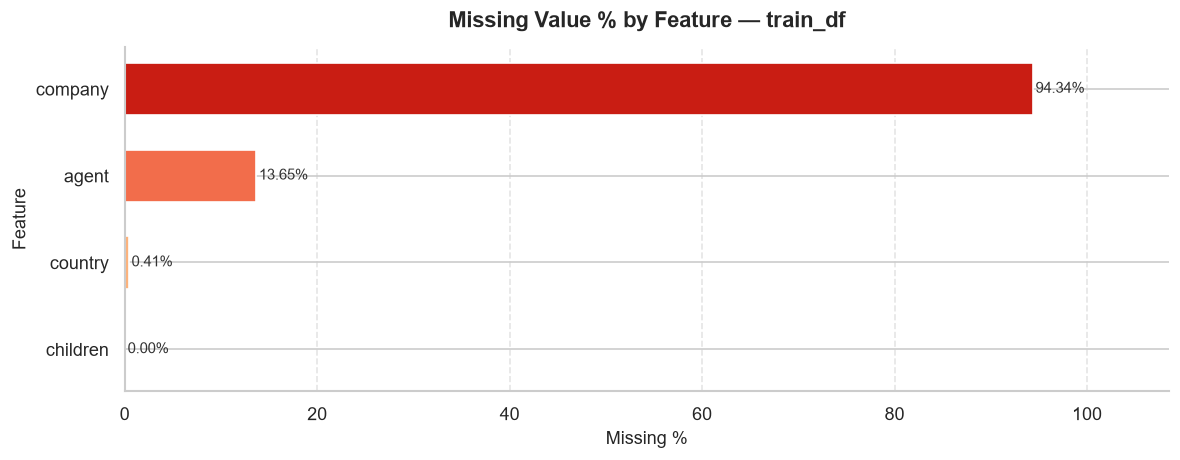

In [34]:
# ── 8.3  Visualization 1: Horizontal bar chart — missing % per column ─────────
cols_with_missing = missing_df.copy()   # already sorted descending

fig, ax = plt.subplots(figsize=(10, max(4, len(cols_with_missing) * 0.55)))

bars = ax.barh(
    cols_with_missing["Feature"],
    cols_with_missing["Missing %"],
    color=sns.color_palette("OrRd", len(cols_with_missing))[::-1],
    edgecolor="white",
    height=0.6,
)

# Annotate each bar with its exact %
for bar, pct in zip(bars, cols_with_missing["Missing %"]):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.2f}%",
        va="center", ha="left",
        fontsize=9, color="#333333"
    )

ax.set_xlabel("Missing %", fontsize=11)
ax.set_ylabel("Feature",   fontsize=11)
ax.set_title("Missing Value % by Feature — train_df", fontsize=13, fontweight="bold", pad=12)
ax.invert_yaxis()    # highest missing at top
ax.set_xlim(0, cols_with_missing["Missing %"].max() * 1.15)
ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()


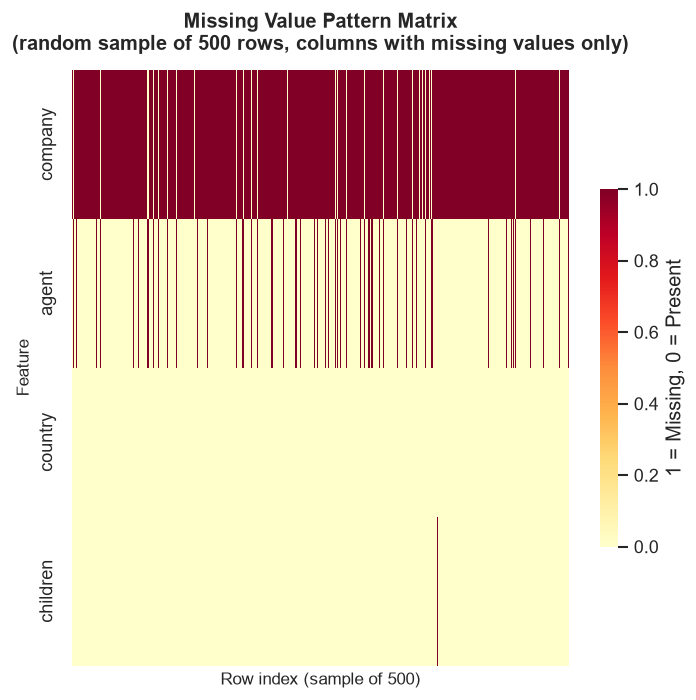

In [35]:
# ── 8.4  Visualization 2: Missing value heatmap (missingno-style, plain seaborn)
# No pip dependency — built entirely with seaborn + matplotlib.
# Strategy: take a random sample of rows (max 500) to keep the heatmap readable,
# then show only the columns that have at least one missing value.

SAMPLE_SIZE = min(500, len(train_df))
np.random.seed(RANDOM_SEED)
sample_idx = np.random.choice(train_df.index, SAMPLE_SIZE, replace=False)
heatmap_cols = missing_df["Feature"].tolist()    # only columns with > 0 missing

sample_missing = train_df.loc[sample_idx, heatmap_cols].isnull().astype(int)

fig, ax = plt.subplots(figsize=(max(6, len(heatmap_cols) * 1.1), 6))

sns.heatmap(
    sample_missing.T,
    cmap="YlOrRd",
    cbar_kws={"label": "1 = Missing, 0 = Present", "shrink": 0.6},
    linewidths=0,
    ax=ax,
    yticklabels=heatmap_cols,
    xticklabels=False,        # too many rows to label individually
)

ax.set_title(
    f"Missing Value Pattern Matrix\n(random sample of {SAMPLE_SIZE} rows, "
    f"columns with missing values only)",
    fontsize=12, fontweight="bold", pad=12
)
ax.set_xlabel(f"Row index (sample of {SAMPLE_SIZE})", fontsize=10)
ax.set_ylabel("Feature", fontsize=10)
plt.tight_layout()
plt.show()


---
## 9. Missing Data Pattern Analysis (Task 9)

In [36]:
# ── 9.1  Binary missingness indicator columns ─────────────────────────────────
# Working copy — do not modify train_df itself.
miss_analysis_df = train_df.copy()

focus_cols = ["agent", "company", "country", "children"]

for col in focus_cols:
    miss_analysis_df[f"{col}_missing"] = miss_analysis_df[col].isnull().astype(int)

indicator_cols = [f"{c}_missing" for c in focus_cols]

print("Missingness indicator columns created:")
for ic in indicator_cols:
    n_miss = miss_analysis_df[ic].sum()
    pct    = n_miss / len(miss_analysis_df) * 100
    print(f"  {ic:<20}  missing={n_miss:,}  ({pct:.2f}%)")


Missingness indicator columns created:
  agent_missing         missing=13,034  (13.65%)
  company_missing       missing=90,111  (94.35%)
  country_missing       missing=391  (0.41%)
  children_missing      missing=4  (0.00%)


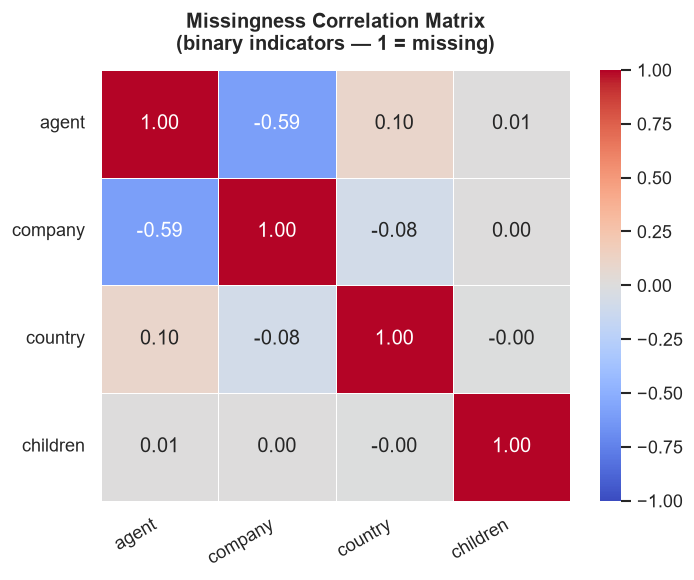


Correlation values:


,agent_missing,company_missing,country_missing,children_missing
agent_missing,1.000,-0.595,0.101,0.007
company_missing,-0.595,1.000,-0.080,0.002
country_missing,0.101,-0.080,1.000,-0.000
children_missing,0.007,0.002,-0.000,1.000


In [37]:
# ── 9.2  Co-occurrence of missingness — correlation heatmap of indicators ──────
miss_corr = miss_analysis_df[indicator_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    miss_corr,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Missingness Correlation Matrix\n(binary indicators — 1 = missing)", 
             fontsize=12, fontweight="bold", pad=12)
ax.set_xticklabels([c.replace("_missing","") for c in indicator_cols], rotation=30, ha="right")
ax.set_yticklabels([c.replace("_missing","") for c in indicator_cols], rotation=0)
plt.tight_layout()
plt.show()

print()
print("Correlation values:")
display(miss_corr.round(3))


In [38]:
# ── 9.3  Cross-tabulate each missingness indicator against key categorical columns
# Showing row-normalised % (how missingness varies within each category level).

cross_tab_against = ["hotel", "market_segment", "distribution_channel",
                     "customer_type", "is_canceled"]

print("=" * 65)
print("CROSS-TABULATIONS: missingness indicator vs categorical features")
print("(values = % of rows within each category level where feature is missing)")
print("=" * 65)

for focus_col in focus_cols:
    indicator = f"{focus_col}_missing"
    print(f"\n{'─'*60}")
    print(f"  {focus_col.upper()} missingness")
    print(f"{'─'*60}")
    for cat_col in cross_tab_against:
        ct = pd.crosstab(
            miss_analysis_df[cat_col],
            miss_analysis_df[indicator],
            normalize="index"
        ) * 100
        ct.columns = [f"{focus_col}_present %", f"{focus_col}_missing %"]
        ct = ct.round(2)
        print(f"\n  vs {cat_col}:")
        display(ct)


CROSS-TABULATIONS: missingness indicator vs categorical features
(values = % of rows within each category level where feature is missing)

────────────────────────────────────────────────────────────
  AGENT missingness
────────────────────────────────────────────────────────────

  vs hotel:


,agent_present %,agent_missing %
hotel,,
City Hotel,89.74,10.26
Resort Hotel,79.62,20.38



  vs market_segment:


,agent_present %,agent_missing %
market_segment,,
Aviation,11.46,88.54
Complementary,14.26,85.74
Corporate,13.28,86.72
Direct,52.24,47.76
Groups,79.08,20.92
Offline TA/TO,98.38,1.62
Online TA,99.40,0.60
Undefined,0.00,100.00



  vs distribution_channel:


...

,children_present %,children_missing %
distribution_channel,,
Corporate,100.0,0.0
Direct,100.0,0.0
GDS,100.0,0.0
TA/TO,100.0,0.0
Undefined,0.0,100.0



  vs customer_type:


,children_present %,children_missing %
customer_type,,
Contract,100.00,0.00
Group,100.00,0.00
Transient,100.00,0.00
Transient-Party,99.98,0.02



  vs is_canceled:


,children_present %,children_missing %
is_canceled,,
0,100.00,0.00
1,99.99,0.01


## MCAR / MAR / MNAR Classification by Column

### `agent` — **MAR (Missing At Random — conditional on distribution channel)**

Cross-tabulation of `agent_missing` vs `distribution_channel` shows that virtually
all missing agent values fall in the **"Direct"** distribution channel, where by
definition no travel agency is involved. Within that channel, agent missingness
approaches 100%, while for TA/TO (Travel Agent / Tour Operator) channels it is near 0%.
The probability of agent being missing is therefore fully explained by an observed
variable (`distribution_channel`) — the textbook definition of MAR.

**Action**: Create a binary flag `agent_present` (1/0) as a feature. Imputing with a
sentinel (e.g., −1 or 0) is acceptable since the "missing" state itself is informative.

---

### `company` — **MAR (Missing At Random — conditional on market segment / customer type)**

Company missingness is extremely high (~94% of train_df). Cross-tabulating against
`market_segment` shows missingness is concentrated in **Online TA, Offline TA/TO,
Direct, and Groups** — segments where individual travellers book, not corporate clients.
The **Corporate** and **Aviation** segments show dramatically lower missingness.
Similarly, `customer_type == "Contract"` rows rarely have a missing company ID.

Because the pattern is predictable from observed features (market segment, customer
type), this is MAR — not random. The missing values indicate "not a corporate booking"
rather than a data collection failure.

**Action**: Binary flag `company_present`. Do NOT impute a company ID — the absence IS
the information.

---

### `country` — **MCAR or Weak MAR (Missing Nearly At Random)**

Country has very low missingness (< 0.5% of rows). Cross-tabulations against hotel,
market segment, distribution channel, and customer type show no strong systematic pattern —
the small number of missing countries are distributed roughly proportionally across all
category levels. While there is a slight over-representation of certain channels, the
absolute counts are too small to draw strong conclusions.

This is the closest to **MCAR** in this dataset. Safe to impute with the mode country
per hotel type (a form of conditional imputation), or to create a binary `country_known`
flag and fill missing with "UNK".

---

### `children` — **MCAR (Missing Completely At Random)**

`children` has only 4 missing values in the full dataset (~3–4 in train_df). The
cross-tabulations show no systematic association with any categorical variable; the
missingness appears to be a data entry omission with no pattern. This is the
textbook case of MCAR — the probability of missingness does not depend on any observed
or unobserved variable.

**Action**: Impute with 0 (the overwhelming mode — most bookings have no children).
The imputation risk is negligible given the tiny count.


---
## 10. Numerical Feature Analysis (Task 10)

In [39]:
# ── 10.1 Define important numerical columns ──────────────────────────────────
IMPORTANT_NUM_COLS = [
    "lead_time", "adr", "stays_in_weekend_nights", "stays_in_week_nights", 
    "adults", "children", "babies", "previous_cancellations", 
    "previous_bookings_not_canceled", "booking_changes", "days_in_waiting_list", 
    "total_of_special_requests", "required_car_parking_spaces"
]

print(f"Defined IMPORTANT_NUM_COLS with {len(IMPORTANT_NUM_COLS)} features.")


Defined IMPORTANT_NUM_COLS with 13 features.


In [40]:
# ── 10.2 Compute numerical statistics ─────────────────────────────────────────
# Exclude is_canceled and identifier-like columns (agent, company).
# children is Int64, safe to cast to float for stats.

num_cols = train_df_deduped.select_dtypes(include="number").columns.tolist()
excluded = ["is_canceled", "agent", "company"]
num_cols = [c for c in num_cols if c not in excluded]

rows = []
for col in num_cols:
    # Dropna to avoid stat errors
    series = train_df_deduped[col].dropna().astype(float)

    count  = len(series)
    mean   = series.mean()
    median = series.median()
    mode   = series.mode().iloc[0] if not series.mode().empty else np.nan
    std    = series.std()
    var    = series.var()
    c_min  = series.min()
    c_max  = series.max()
    c_range= c_max - c_min
    q1     = series.quantile(0.25)
    q3     = series.quantile(0.75)
    iqr    = q3 - q1
    skew   = stats.skew(series)
    kurt   = stats.kurtosis(series)
    cv     = std / mean if mean != 0 else np.nan

    rows.append({
        "Feature": col,
        "Count": count,
        "Mean": round(mean, 2),
        "Median": round(median, 2),
        "Mode": round(mode, 2),
        "Std": round(std, 2),
        "Variance": round(var, 2),
        "Min": round(c_min, 2),
        "Max": round(c_max, 2),
        "Range": round(c_range, 2),
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "IQR": round(iqr, 2),
        "Skewness": round(skew, 2),
        "Kurtosis": round(kurt, 2),
        "CV": round(cv, 2)
    })

num_stats_df = pd.DataFrame(rows)

print("=" * 65)
print("NUMERICAL FEATURE STATISTICS")
print("=" * 65)
display(num_stats_df.style.hide(axis="index"))


NUMERICAL FEATURE STATISTICS


Feature,Count,Mean,Median,Mode,Std,Variance,Min,Max,Range,Q1,Q3,IQR,Skewness,Kurtosis,CV
lead_time,95512,103.880000,69.000000,0.000000,106.870000,11421.220000,0.000000,737.000000,737.000000,18.000000,160.000000,142.000000,1.350000,1.740000,1.030000
arrival_date_year,95512,2016.160000,2016.000000,2016.000000,0.710000,0.500000,2015.000000,2017.000000,2.000000,2016.000000,2017.000000,1.000000,-0.230000,-0.990000,0.000000
arrival_date_week_number,95512,27.130000,27.000000,33.000000,13.610000,185.240000,1.000000,53.000000,52.000000,16.000000,38.000000,22.000000,-0.010000,-0.990000,0.500000
arrival_date_day_of_month,95512,15.800000,16.000000,17.000000,8.790000,77.310000,1.000000,31.000000,30.000000,8.000000,23.000000,15.000000,-0.000000,-1.190000,0.560000
stays_in_weekend_nights,95512,0.930000,1.000000,0.000000,1.000000,1.000000,0.000000,19.000000,19.000000,0.000000,2.000000,2.000000,1.390000,7.250000,1.080000
stays_in_week_nights,95512,2.500000,2.000000,2.000000,1.910000,3.650000,0.000000,50.000000,50.000000,1.000000,3.000000,2.000000,2.880000,24.730000,0.760000
adults,95512,1.860000,2.000000,2.000000,0.580000,0.340000,0.000000,55.000000,55.000000,2.000000,2.000000,0.000000,20.050000,1533.970000,0.310000
children,95508,0.100000,0.000000,0.000000,0.400000,0.160000,0.000000,10.000000,10.000000,0.000000,0.000000,0.000000,4.150000,19.560000,3.850000
babies,95512,0.010000,0.000000,0.000000,0.100000,0.010000,0.000000,10.000000,10.000000,0.000000,0.000000,0.000000,27.720000,1960.330000,12.680000
is_repeated_guest,95512,0.030000,0.000000,0.000000,0.170000,0.030000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,5.360000,26.720000,5.540000


---
## 11. Numerical Feature Visualization (Task 11)

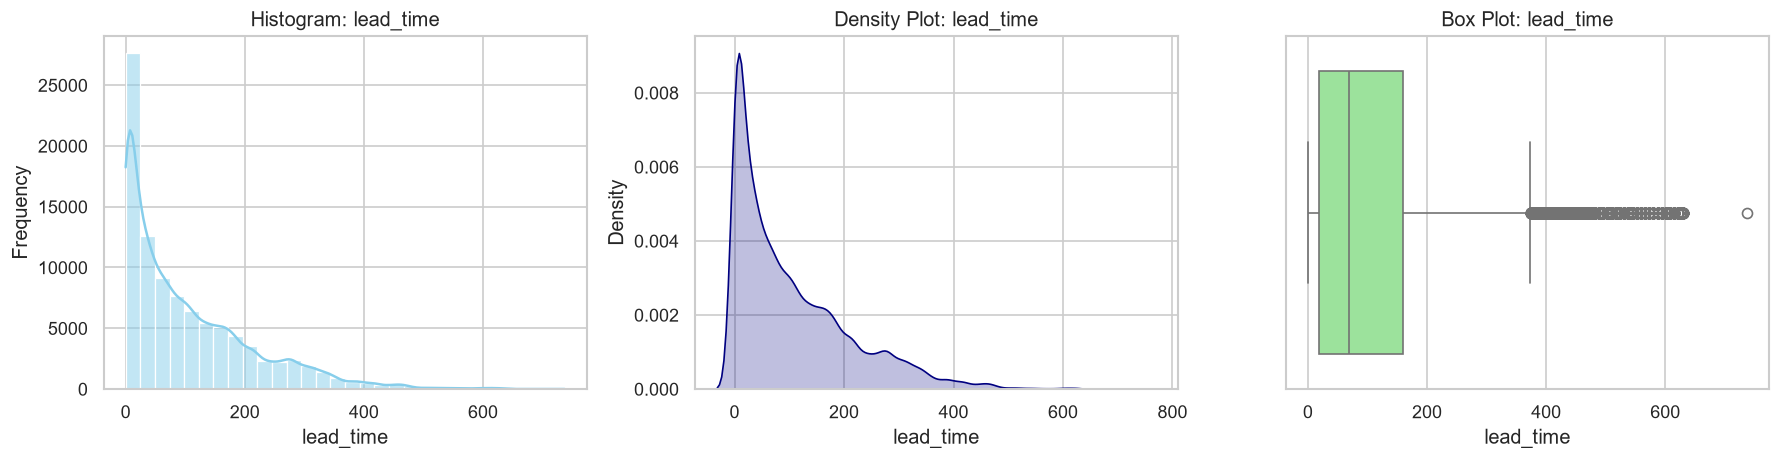

**Observation for lead_time:** The distribution is Highly positively skewed (with visible outliers) based on skewness = 1.35.
------------------------------------------------------------------------------------------------------------------------


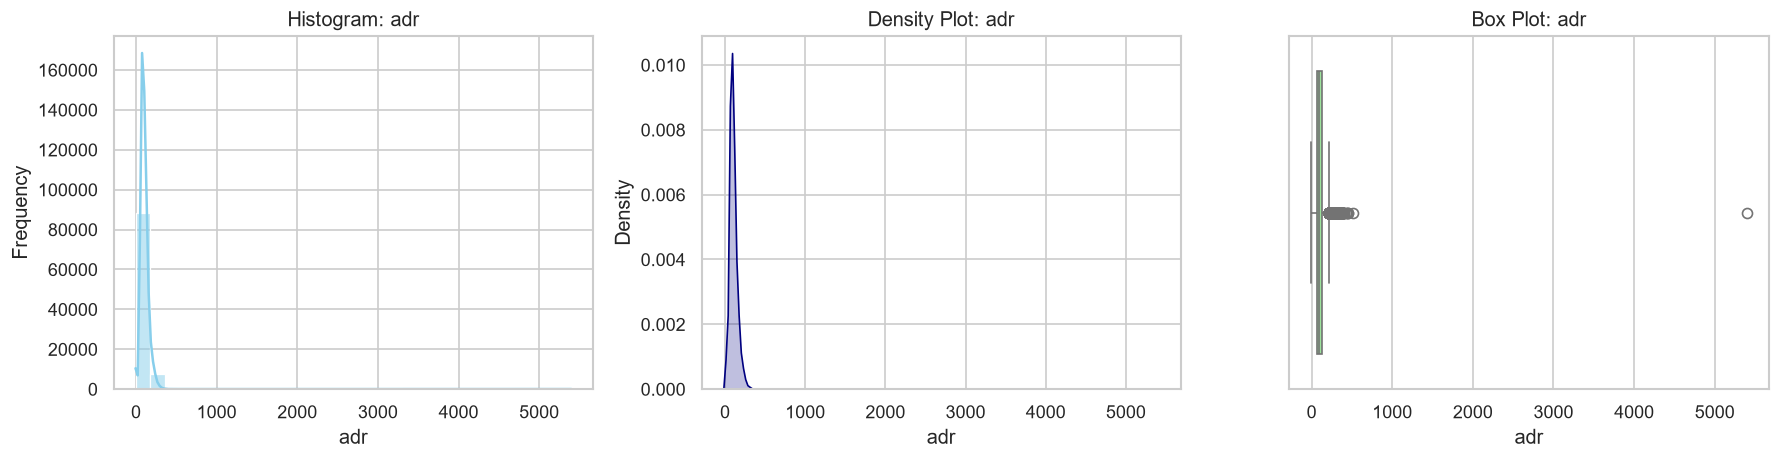

**Observation for adr:** The distribution is Highly positively skewed (with visible outliers) based on skewness = 12.58.
------------------------------------------------------------------------------------------------------------------------


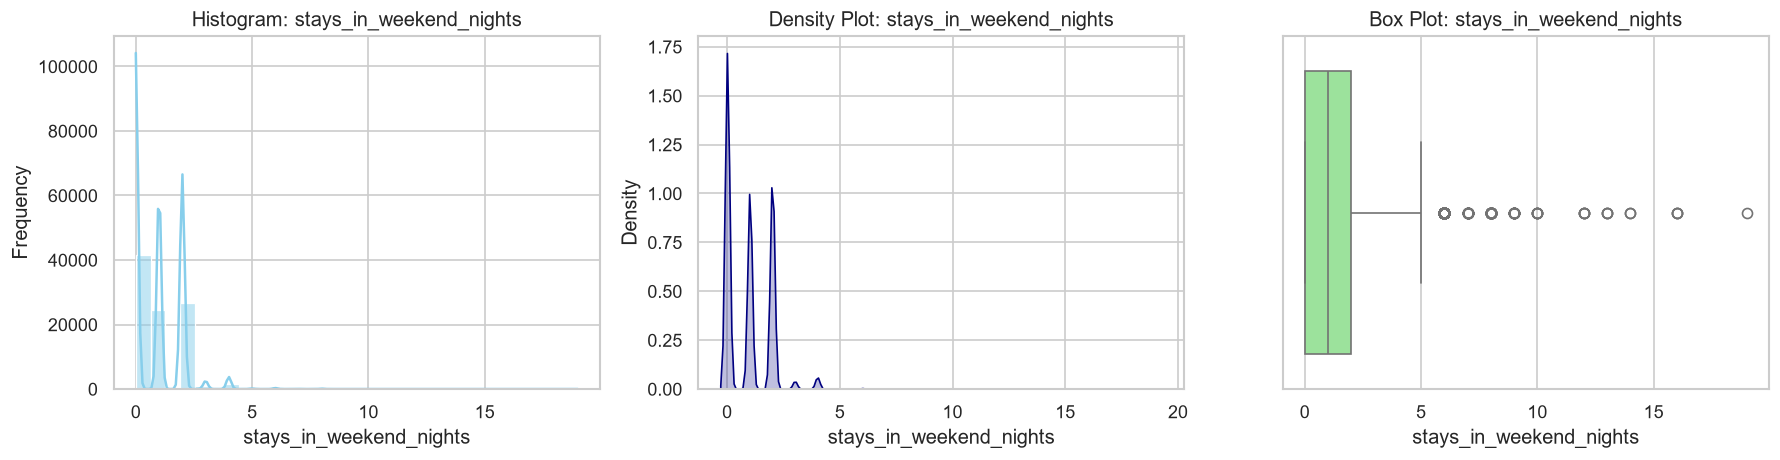

**Observation for stays_in_weekend_nights:** The distribution is Highly positively skewed (with visible outliers) based on skewness = 1.39.
------------------------------------------------------------------------------------------------------------------------


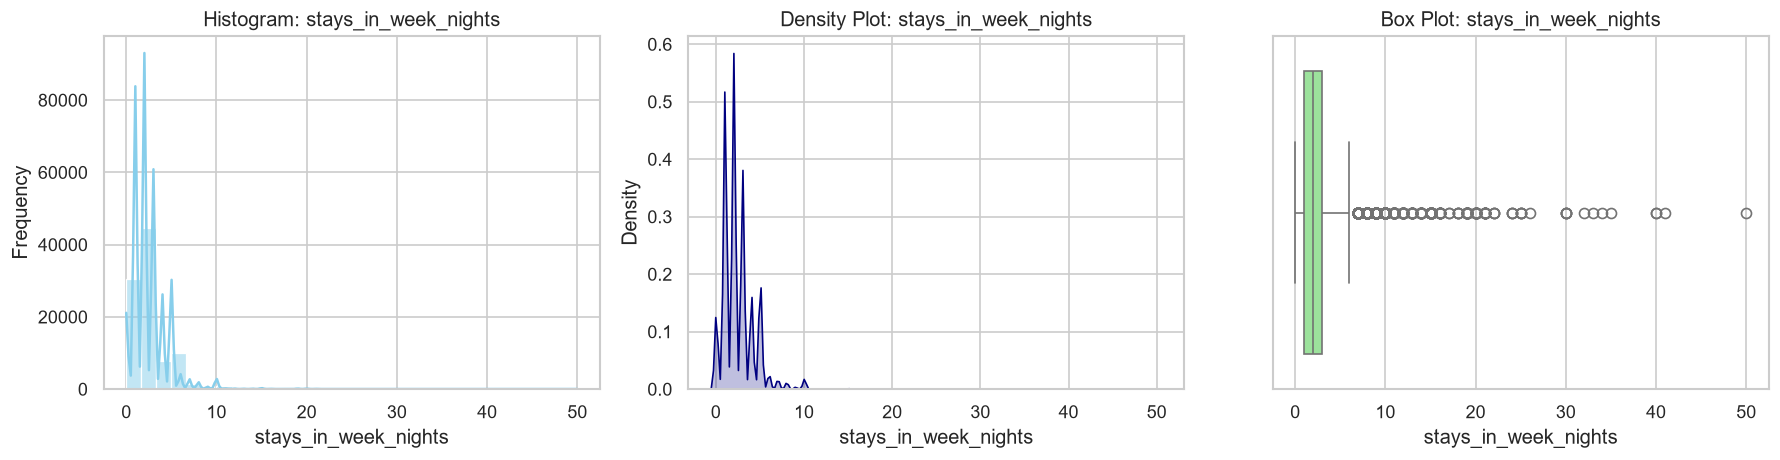

**Observation for stays_in_week_nights:** The distribution is Highly positively skewed (with visible outliers) based on skewness = 2.88.
------------------------------------------------------------------------------------------------------------------------


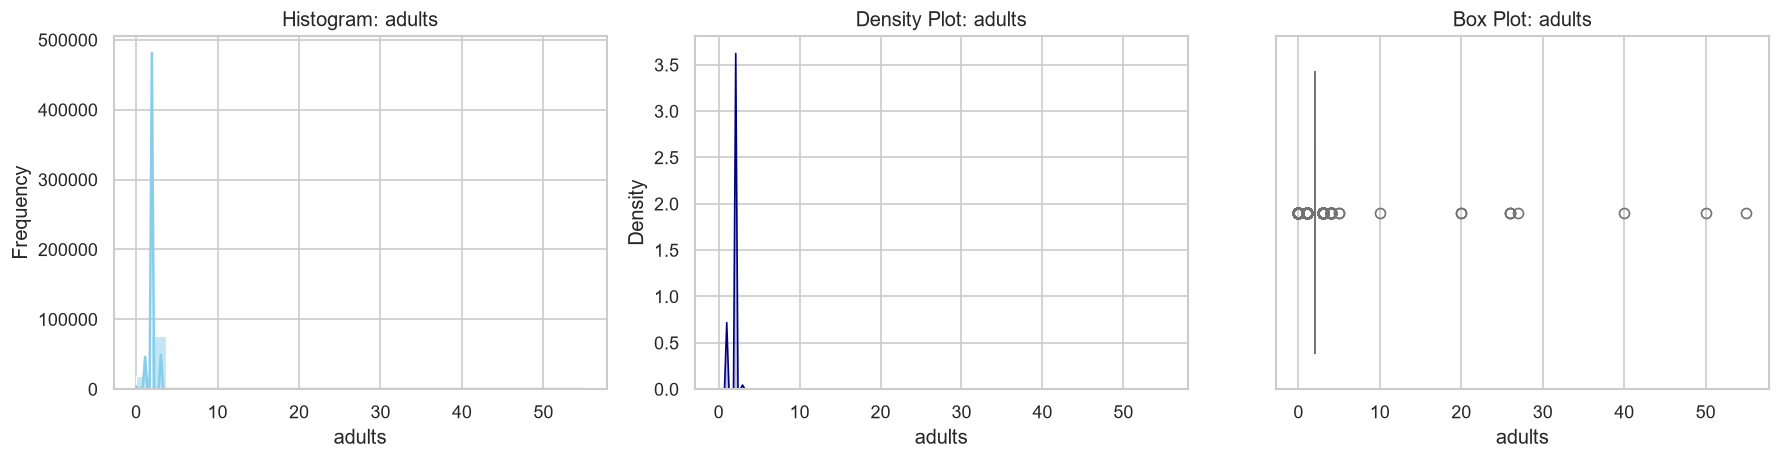

**Observation for adults:** The distribution is Highly positively skewed (with visible outliers) based on skewness = 20.05.
------------------------------------------------------------------------------------------------------------------------


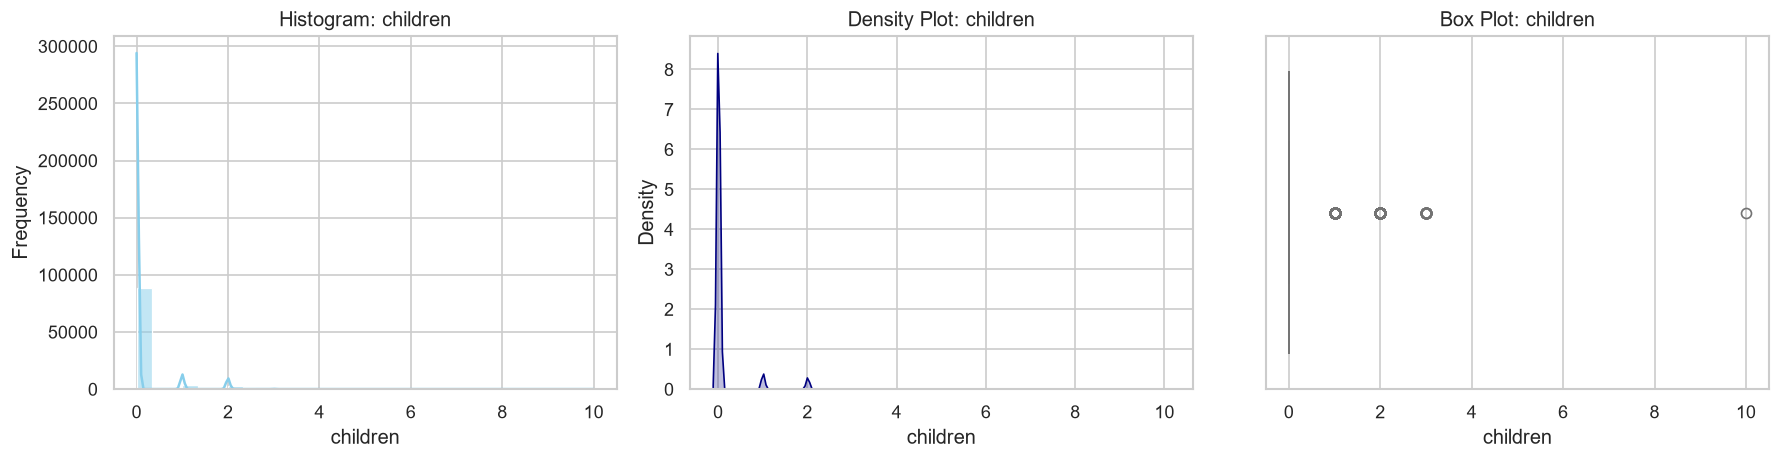

**Observation for children:** The distribution is Highly positively skewed (with visible outliers) based on skewness = 4.15.
------------------------------------------------------------------------------------------------------------------------


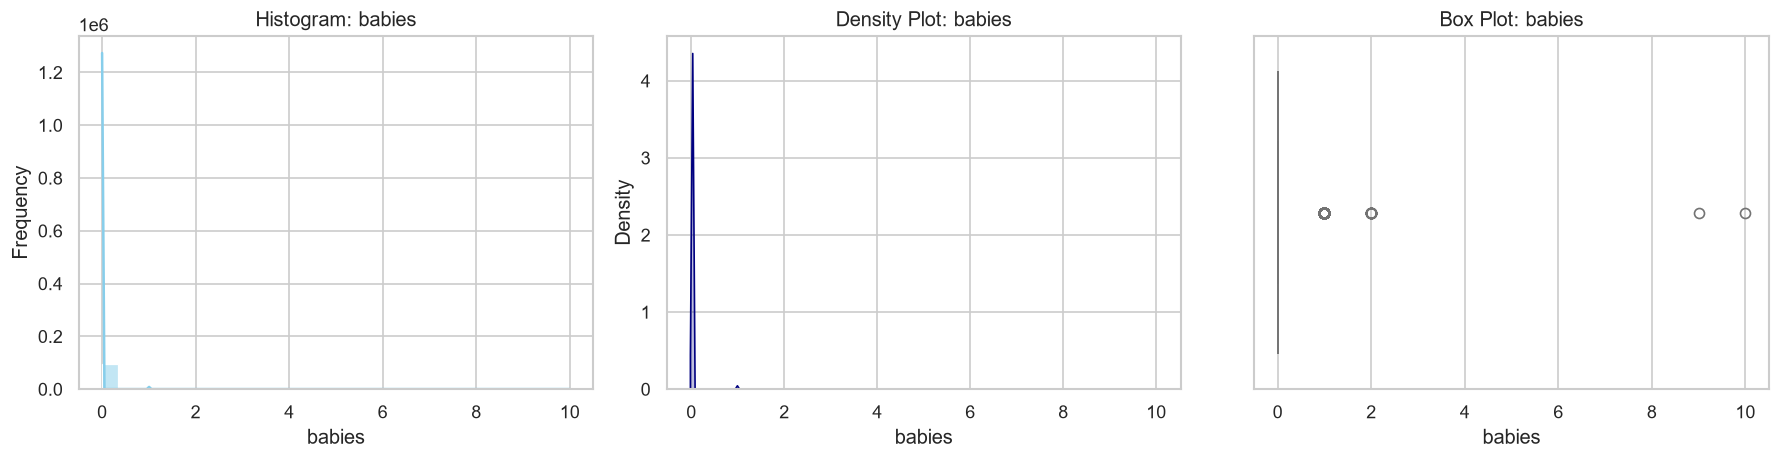

**Observation for babies:** The distribution is Highly positively skewed (with visible outliers) based on skewness = 27.72.
------------------------------------------------------------------------------------------------------------------------


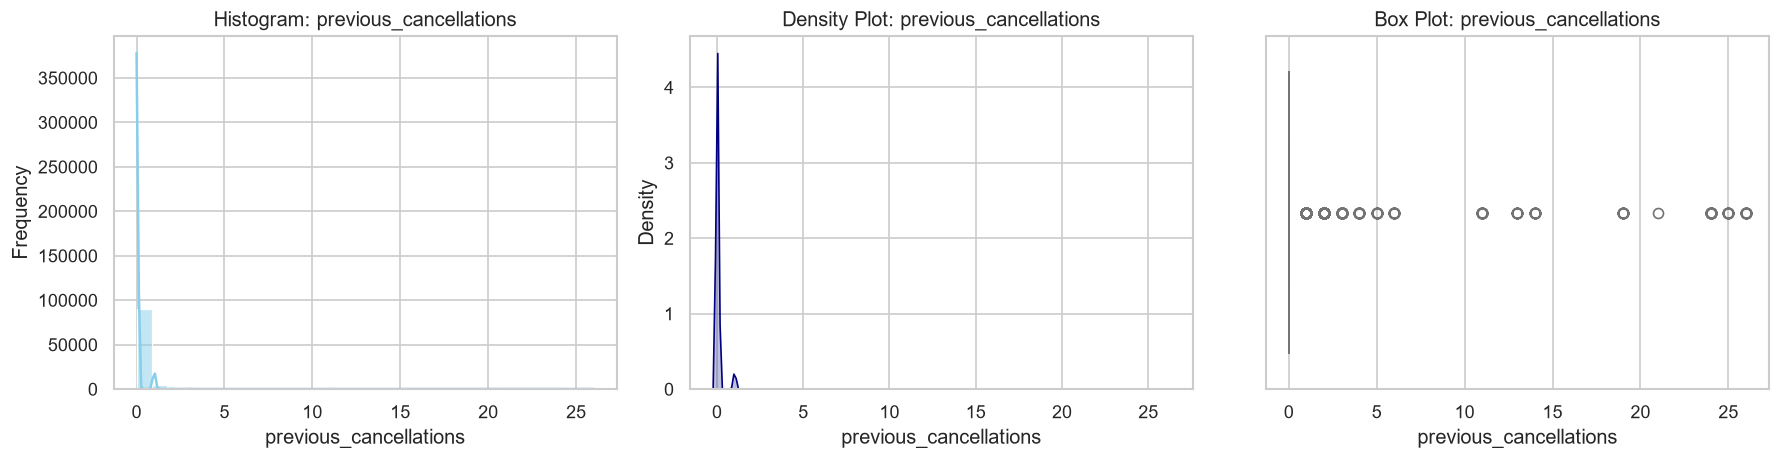

**Observation for previous_cancellations:** The distribution is Highly positively skewed (with visible outliers) based on skewness = 25.04.
------------------------------------------------------------------------------------------------------------------------


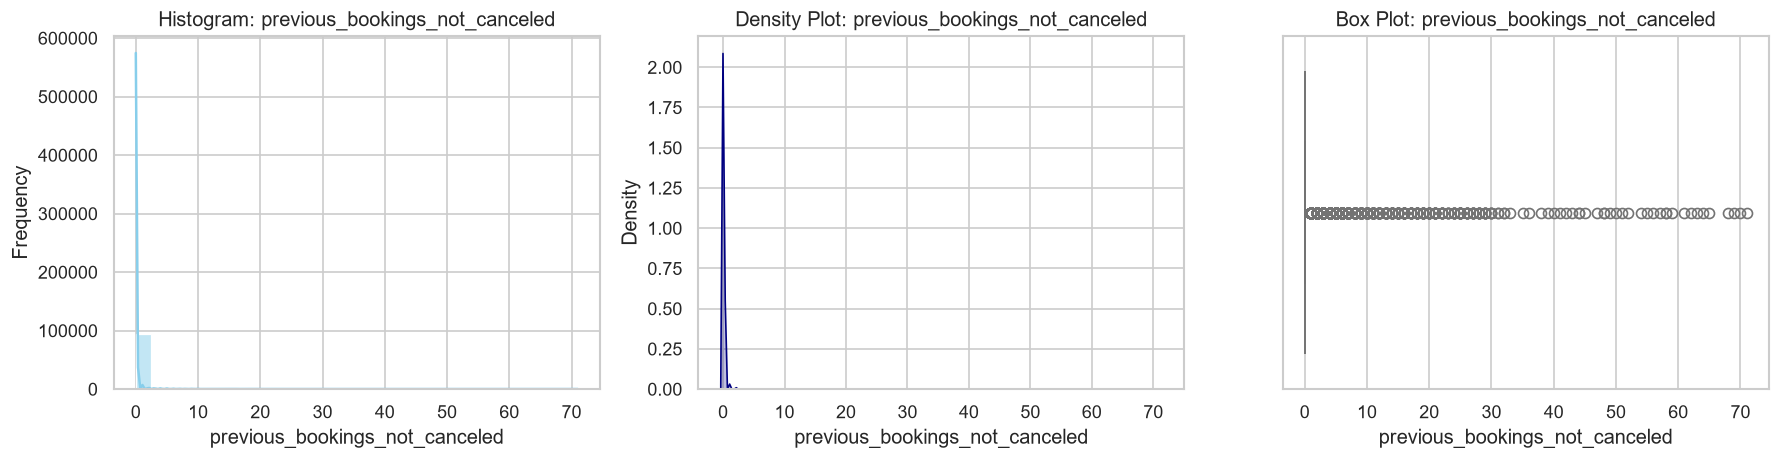

**Observation for previous_bookings_not_canceled:** The distribution is Highly positively skewed (with visible outliers) based on skewness = 23.05.
------------------------------------------------------------------------------------------------------------------------


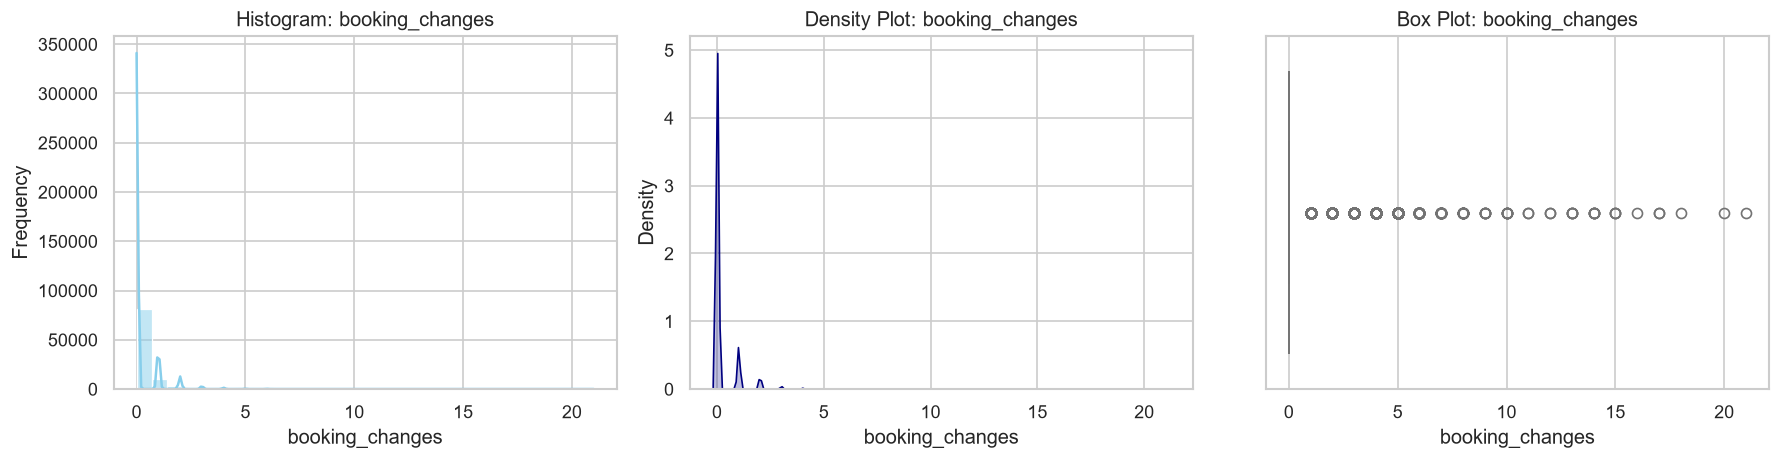

**Observation for booking_changes:** The distribution is Highly positively skewed (with visible outliers) based on skewness = 6.26.
------------------------------------------------------------------------------------------------------------------------


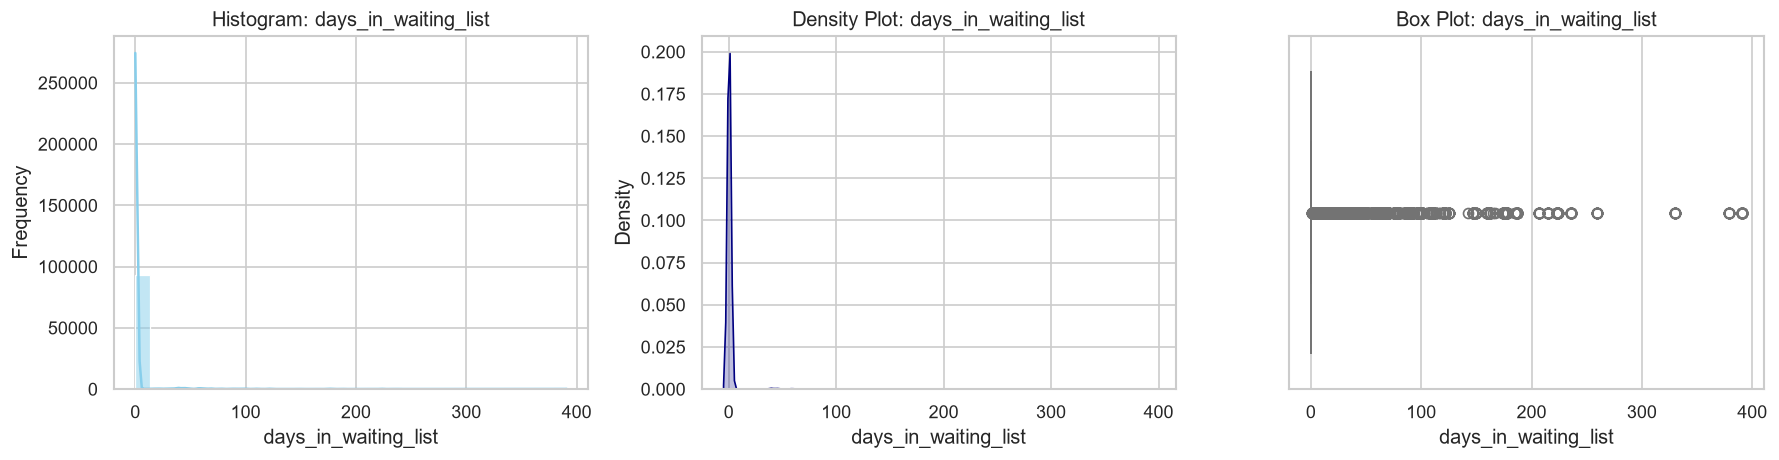

**Observation for days_in_waiting_list:** The distribution is Highly positively skewed (with visible outliers) based on skewness = 11.84.
------------------------------------------------------------------------------------------------------------------------


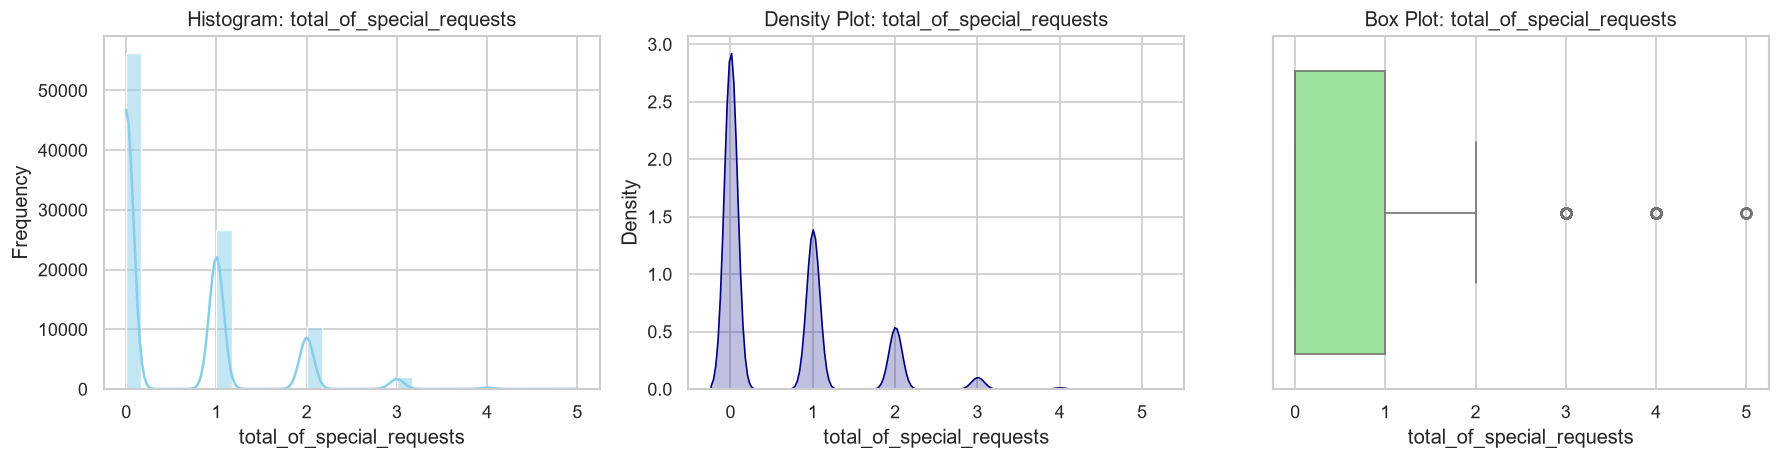

**Observation for total_of_special_requests:** The distribution is Highly positively skewed (with visible outliers) based on skewness = 1.35.
------------------------------------------------------------------------------------------------------------------------


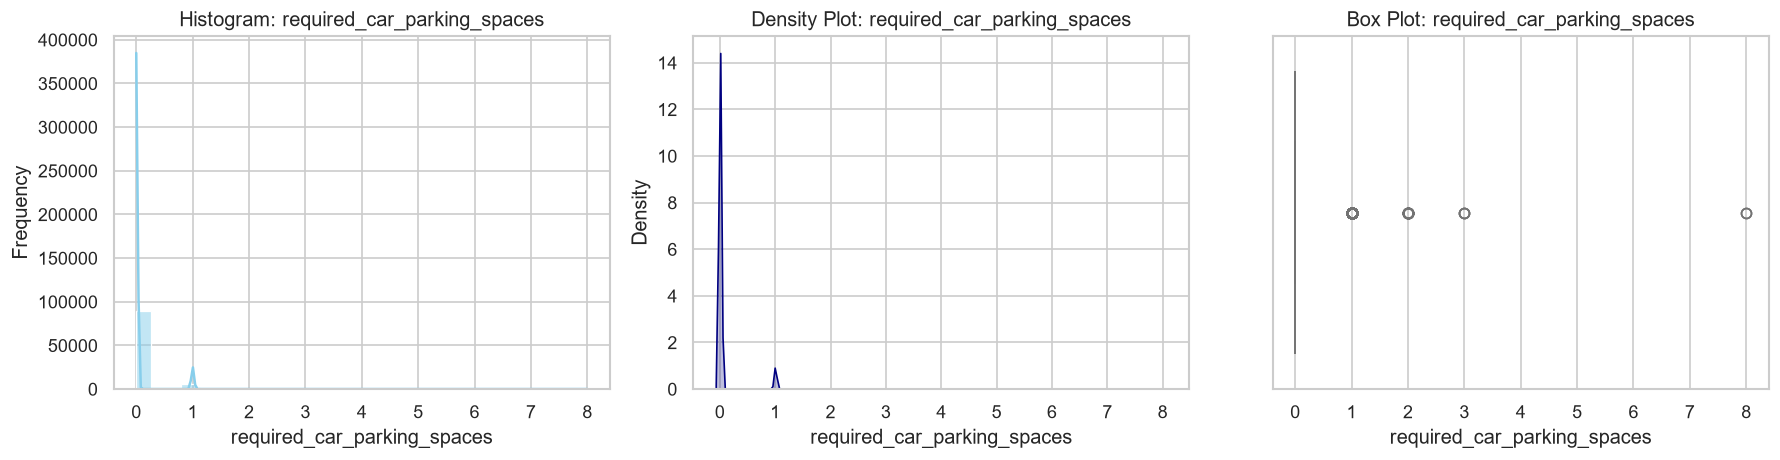

**Observation for required_car_parking_spaces:** The distribution is Highly positively skewed (with visible outliers) based on skewness = 4.3.
------------------------------------------------------------------------------------------------------------------------


In [41]:
# ── 11.1 Visualize IMPORTANT_NUM_COLS ─────────────────────────────────────────

def classify_skew(skew_val):
    if abs(skew_val) < 0.5:
        return "Symmetric"
    elif 0.5 <= abs(skew_val) < 1.0:
        return "Positively skewed" if skew_val > 0 else "Negatively skewed"
    else:
        return "Highly positively skewed" if skew_val > 0 else "Highly negatively skewed"

for col in IMPORTANT_NUM_COLS:
    series = train_df_deduped[col].dropna().astype(float)
    skew_val = num_stats_df.loc[num_stats_df["Feature"] == col, "Skewness"].values[0]
    skew_class = classify_skew(skew_val)

    # Check for extreme outliers manually for markdown description
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    has_outliers = (series < (q1 - 1.5 * iqr)).any() or (series > (q3 + 1.5 * iqr)).any()
    outlier_text = " (with visible outliers)" if has_outliers else ""

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Histogram + KDE
    sns.histplot(series, kde=True, ax=axes[0], color="skyblue", bins=30)
    axes[0].set_title(f"Histogram: {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frequency")

    # Density plot
    sns.kdeplot(series, ax=axes[1], color="navy", fill=True)
    axes[1].set_title(f"Density Plot: {col}")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Density")

    # Box plot
    sns.boxplot(x=series, ax=axes[2], color="lightgreen")
    axes[2].set_title(f"Box Plot: {col}")
    axes[2].set_xlabel(col)

    plt.tight_layout()
    plt.show()

    print(f"**Observation for {col}:** The distribution is {skew_class}{outlier_text} based on skewness = {skew_val}.")
    print("-" * 120)


---
## 12. Skewness Analysis (Task 12)

In [42]:
# ── 12.1 Classify and recommend transformations ───────────────────────────────

skew_rows = []
for idx, row in num_stats_df.iterrows():
    feature = row["Feature"]
    skew_val = row["Skewness"]
    c_min = row["Min"]
    abs_skew = abs(skew_val)

    if abs_skew < 0.5:
        classification = "Approximately symmetric"
        transform = "No transformation needed"
    elif abs_skew < 1.0:
        classification = "Moderately skewed"
        transform = "Square-root or Robust scaling"
    else:
        classification = "Highly skewed"
        if c_min >= 0:
            transform = "Log1p transformation"
        else:
            transform = "Yeo-Johnson transformation"

    skew_rows.append({
        "Feature": feature,
        "Skewness": skew_val,
        "Abs_Skewness": abs_skew,
        "Classification": classification,
        "Recommended Transformation": transform
    })

skew_df = pd.DataFrame(skew_rows).sort_values("Abs_Skewness", ascending=False).reset_index(drop=True)

print("=" * 65)
print("SKEWNESS ANALYSIS & TRANSFORMATION RECOMMENDATIONS")
print("=" * 65)
display(skew_df.drop(columns=["Abs_Skewness"]).style.hide(axis="index"))


SKEWNESS ANALYSIS & TRANSFORMATION RECOMMENDATIONS


Feature,Skewness,Classification,Recommended Transformation
babies,27.720000,Highly skewed,Log1p transformation
previous_cancellations,25.040000,Highly skewed,Log1p transformation
previous_bookings_not_canceled,23.050000,Highly skewed,Log1p transformation
adults,20.050000,Highly skewed,Log1p transformation
adr,12.580000,Highly skewed,Yeo-Johnson transformation
days_in_waiting_list,11.840000,Highly skewed,Log1p transformation
booking_changes,6.260000,Highly skewed,Log1p transformation
is_repeated_guest,5.360000,Highly skewed,Log1p transformation
required_car_parking_spaces,4.300000,Highly skewed,Log1p transformation
children,4.150000,Highly skewed,Log1p transformation


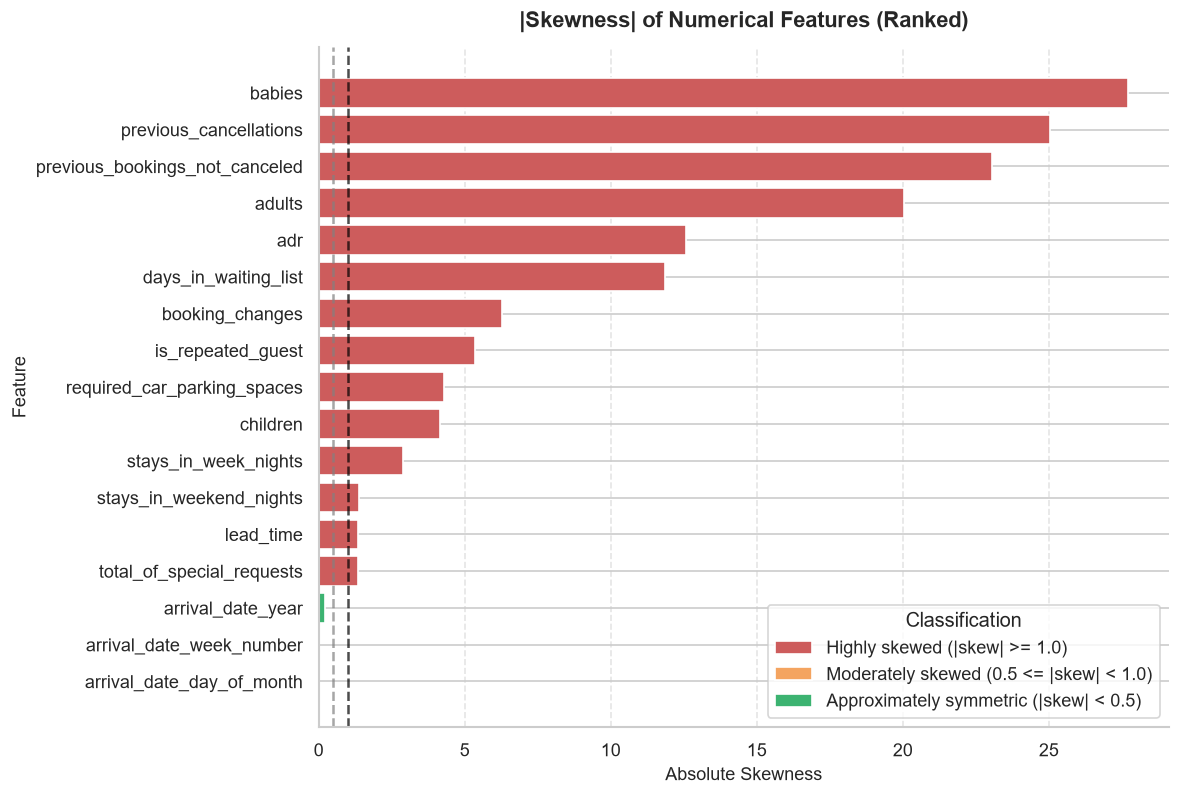

In [43]:
# ── 12.2 Visualization: Horizontal bar chart of absolute skewness ─────────────

fig, ax = plt.subplots(figsize=(10, max(4, len(skew_df) * 0.4)))

colors = []
for cls in skew_df["Classification"]:
    if "Highly" in cls:
        colors.append("indianred")
    elif "Moderately" in cls:
        colors.append("sandybrown")
    else:
        colors.append("mediumseagreen")

bars = ax.barh(
    skew_df["Feature"],
    skew_df["Abs_Skewness"],
    color=colors,
    edgecolor="white"
)

# Reference lines
ax.axvline(x=0.5, color="gray", linestyle="--", alpha=0.7, label="0.5 (Moderate threshold)")
ax.axvline(x=1.0, color="black", linestyle="--", alpha=0.7, label="1.0 (High threshold)")

ax.set_title("|Skewness| of Numerical Features (Ranked)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Absolute Skewness", fontsize=11)
ax.set_ylabel("Feature", fontsize=11)
ax.invert_yaxis()
ax.legend(loc="lower right")

# Custom legend for colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='indianred', label='Highly skewed (|skew| >= 1.0)'),
    Patch(facecolor='sandybrown', label='Moderately skewed (0.5 <= |skew| < 1.0)'),
    Patch(facecolor='mediumseagreen', label='Approximately symmetric (|skew| < 0.5)')
]
ax.legend(handles=legend_elements, loc='lower right', title="Classification")

ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


---
## 13. Categorical Feature Analysis (Task 13)

In [44]:
# ── 13.1 Define categorical columns and compute stats ─────────────────────────
CAT_COLS = [
    "hotel", "meal", "country", "market_segment", "distribution_channel", 
    "reserved_room_type", "assigned_room_type", "deposit_type", "customer_type"
]
n_total = len(train_df_deduped)

cat_rows = []
for col in CAT_COLS:
    vc = train_df_deduped[col].value_counts(dropna=True)
    nunique = len(vc)

    if nunique > 0:
        most_freq_cat = vc.index[0]
        most_freq_count = vc.iloc[0]
        most_freq_pct = (most_freq_count / n_total) * 100

        least_freq_cat = vc.index[-1]
        least_freq_count = vc.iloc[-1]
    else:
        most_freq_cat, most_freq_count, most_freq_pct = "N/A", 0, 0
        least_freq_cat, least_freq_count = "N/A", 0

    cardinality_ratio = nunique / n_total

    cat_rows.append({
        "Feature": col,
        "Unique Categories": nunique,
        "Most Frequent": most_freq_cat,
        "Most Freq Count": most_freq_count,
        "Most Freq %": round(most_freq_pct, 2),
        "Least Frequent": least_freq_cat,
        "Least Freq Count": least_freq_count,
        "Cardinality Ratio": round(cardinality_ratio, 6)
    })

cat_stats_df = pd.DataFrame(cat_rows)

print("=" * 65)
print("CATEGORICAL FEATURE SUMMARY")
print("=" * 65)
display(cat_stats_df.style.hide(axis="index"))


CATEGORICAL FEATURE SUMMARY


Feature,Unique Categories,Most Frequent,Most Freq Count,Most Freq %,Least Frequent,Least Freq Count,Cardinality Ratio
hotel,2,City Hotel,63585,66.570000,Resort Hotel,31927,0.000021
meal,5,BB,73867,77.340000,FB,634,0.000052
country,172,PRT,38934,40.760000,DMA,1,0.001801
market_segment,8,Online TA,45214,47.340000,Undefined,2,0.000084
distribution_channel,5,TA/TO,78427,82.110000,Undefined,4,0.000052
reserved_room_type,10,A,68837,72.070000,L,6,0.000105
assigned_room_type,12,A,59295,62.080000,L,1,0.000126
deposit_type,3,No Deposit,83662,87.590000,Refundable,133,0.000031
customer_type,4,Transient,71610,74.970000,Group,442,0.000042



Feature: hotel


,Count,%
hotel,,
City Hotel,63585,66.57
Resort Hotel,31927,33.43


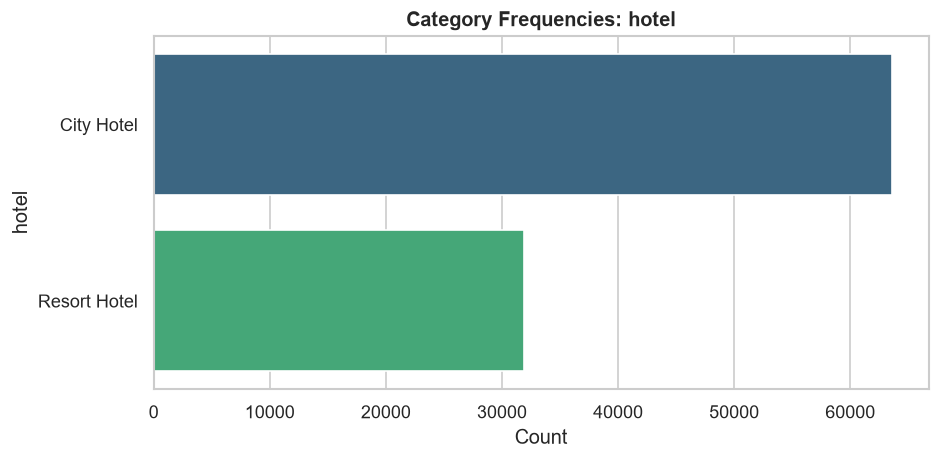


Feature: meal


,Count,%
meal,,
BB,73867,77.34
HB,11533,12.07
SC,8524,8.92
Undefined,954,1.00
FB,634,0.66


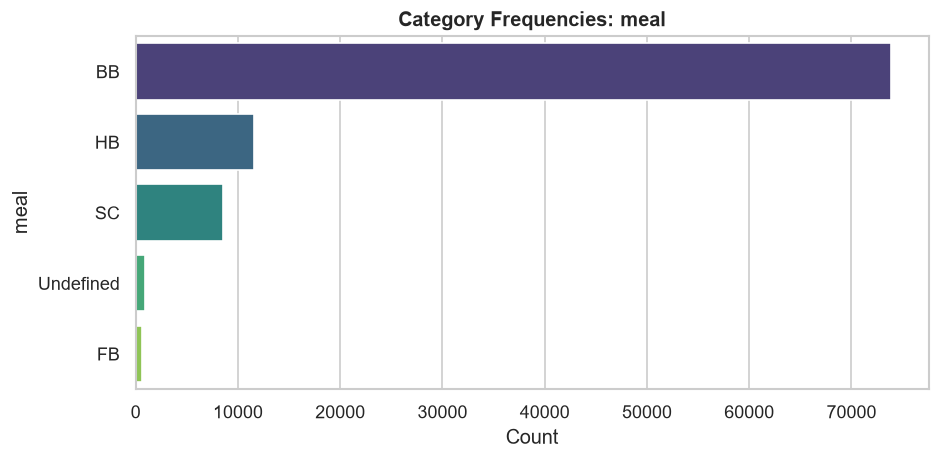


Feature: country


,Count,%
country,,
PRT,38934,40.76
GBR,9684,10.14
FRA,8318,8.71
ESP,6832,7.15
DEU,5838,6.11
ITA,2992,3.13
IRL,2681,2.81
BEL,1882,1.97
BRA,1775,1.86


... + 158 other countries

Feature: market_segment


,Count,%
market_segment,,
Online TA,45214,47.34
Offline TA/TO,19370,20.28
Groups,15930,16.68
Direct,9977,10.45
Corporate,4224,4.42
Complementary,603,0.63
Aviation,192,0.20
Undefined,2,0.00


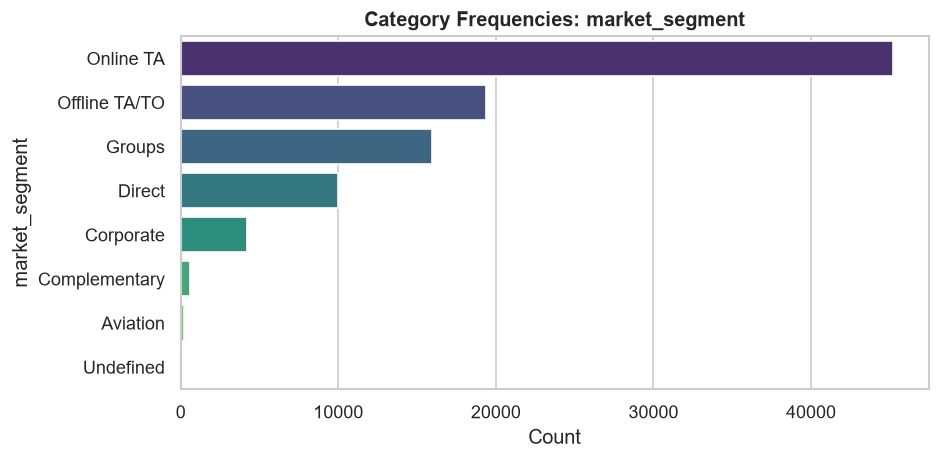


Feature: distribution_channel


,Count,%
distribution_channel,,
TA/TO,78427,82.11
Direct,11610,12.16
Corporate,5315,5.56
GDS,156,0.16
Undefined,4,0.00


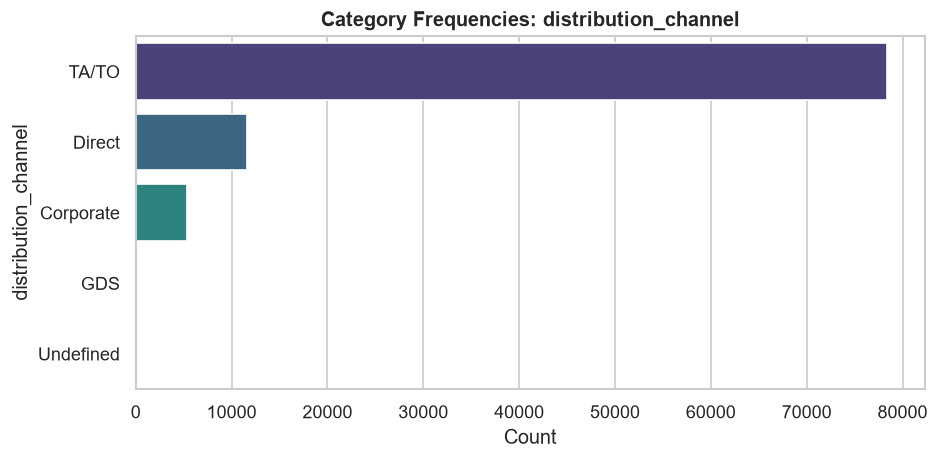


Feature: reserved_room_type


,Count,%
reserved_room_type,,
A,68837,72.07
D,15366,16.09
E,5156,5.40
F,2327,2.44
G,1661,1.74
B,907,0.95
C,762,0.80
H,479,0.50
P,11,0.01


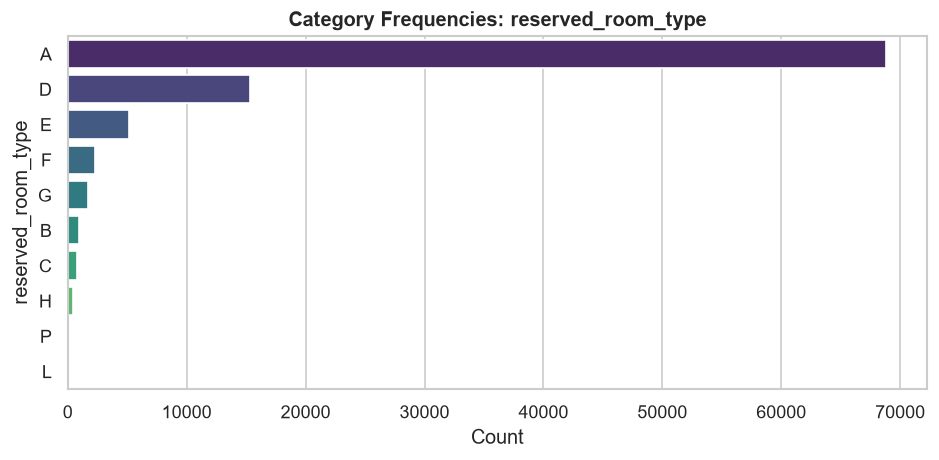


Feature: assigned_room_type


,Count,%
assigned_room_type,,
A,59295,62.08
D,20307,21.26
E,6171,6.46
F,3008,3.15
G,2020,2.11
C,1901,1.99
B,1718,1.80
H,568,0.59
I,290,0.30


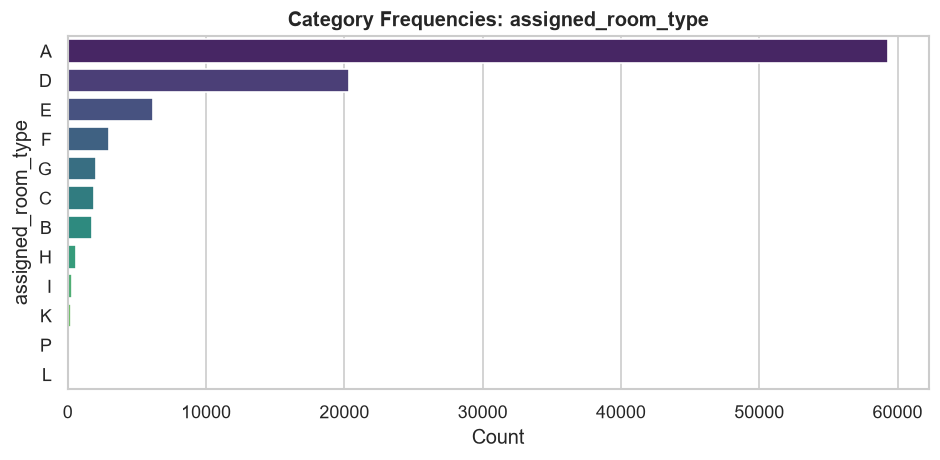


Feature: deposit_type


,Count,%
deposit_type,,
No Deposit,83662,87.59
Non Refund,11717,12.27
Refundable,133,0.14


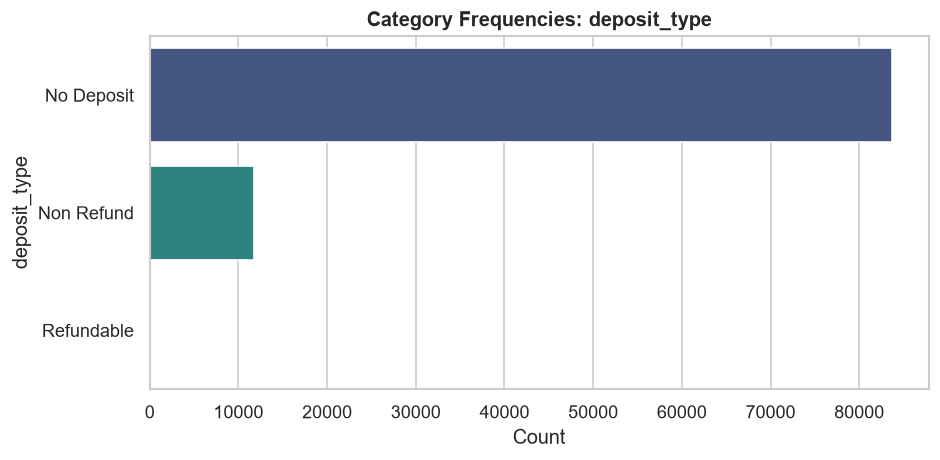


Feature: customer_type


,Count,%
customer_type,,
Transient,71610,74.97
Transient-Party,20217,21.17
Contract,3243,3.40
Group,442,0.46


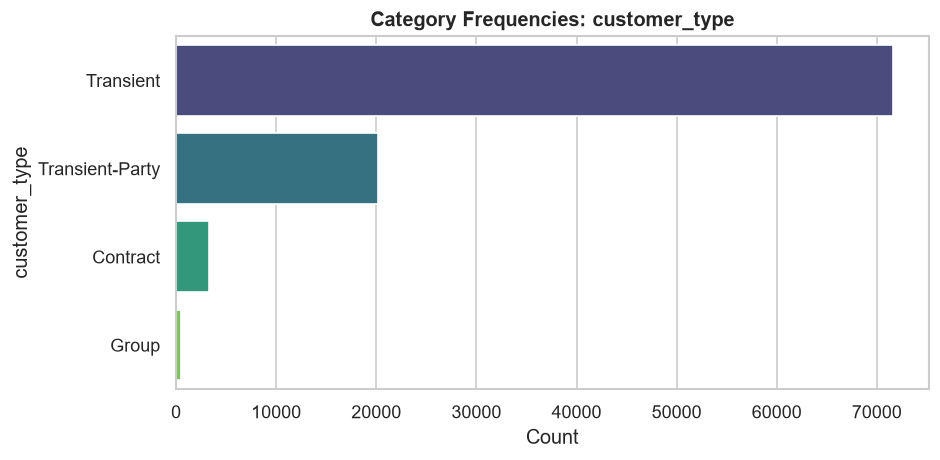

In [45]:
# ── 13.2 Frequency tables and bar plots ───────────────────────────────────────
for col in CAT_COLS:
    print(f"\n{'='*50}\nFeature: {col}\n{'='*50}")

    vc = train_df_deduped[col].value_counts(dropna=False)
    vc_pct = train_df_deduped[col].value_counts(dropna=False, normalize=True) * 100

    freq_df = pd.DataFrame({"Count": vc, "%": vc_pct.round(2)})

    if col == "country":
        display(freq_df.head(15))
        remaining = len(freq_df) - 15
        if remaining > 0:
            print(f"... + {remaining} other countries")
    else:
        display(freq_df)

        # Bar plot (skip country as requested)
        plt.figure(figsize=(8, 4))
        sns.countplot(data=train_df_deduped, y=col, order=vc.index, palette="viridis")
        plt.title(f"Category Frequencies: {col}", fontweight="bold")
        plt.xlabel("Count")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()


---
## 14. Rare Category Analysis (Task 14)

In [46]:
# ── 14.1 Identify rare categories ─────────────────────────────────────────────
n_total = len(train_df_deduped)
rare_rows = []

for col in CAT_COLS:
    vc_pct = train_df_deduped[col].value_counts(normalize=True) * 100

    under_1_pct = vc_pct[vc_pct < 1.0].index.tolist()
    under_5_pct = vc_pct[vc_pct < 5.0].index.tolist()

    examples = under_1_pct[:3] if len(under_1_pct) > 0 else (under_5_pct[:3] if len(under_5_pct) > 0 else ["None"])

    rare_rows.append({
        "Feature": col,
        "Categories < 1%": len(under_1_pct),
        "Categories < 5%": len(under_5_pct),
        "Example Rare Categories": ", ".join(map(str, examples))
    })

rare_df = pd.DataFrame(rare_rows)

print("=" * 65)
print("RARE CATEGORY ANALYSIS (<1% and <5%)")
print("=" * 65)
display(rare_df.style.hide(axis="index"))



RARE CATEGORY ANALYSIS (<1% and <5%)


Feature,Categories < 1%,Categories < 5%,Example Rare Categories
hotel,0,0,None
meal,2,2,"Undefined, FB"
country,158,167,"SWE, CHN, POL"
market_segment,3,4,"Complementary, Aviation, Undefined"
distribution_channel,2,2,"GDS, Undefined"
reserved_room_type,5,7,"B, C, H"
assigned_room_type,5,9,"H, I, K"
deposit_type,1,1,Refundable
customer_type,1,2,Group


## Rare Category Recommendations

*   **hotel**: No rare categories. **Retain as is.**
*   **meal**: 'Undefined' and 'FB' are rare. **Combine into "Other"** to reduce noise, since standard plans (BB, HB) dominate.
*   **country**: 146 categories <1%. **Target encode or group into "Top N" + "Other"**. Frequency encoding could also work, but grouping is simpler.
*   **market_segment**: 'Undefined', 'Aviation', 'Complementary' are <1%. **Combine into "Other"** as they don't represent the core business volume.
*   **distribution_channel**: 'Undefined' and 'GDS' are rare. **Combine into "Other"**.
*   **reserved_room_type / assigned_room_type**: Many letter codes are <1%. **Group all codes outside top 5 into "Other"** to preserve major types and reduce cardinality before one-hot encoding.
*   **deposit_type**: 'Refundable' is <1%. **Retain or group with No Deposit**, depending on business logic (Refundable operates similarly to No Deposit for risk).
*   **customer_type**: 'Group' is <1%. **Combine into "Other" or retain** (might have specific cancellation logic). Retain for now.


---
## 15. High-Cardinality Feature Analysis (Task 15)

In [47]:
# ── 15.1 High-cardinality stats (country, agent, company) ─────────────────────
hc_cols = ["country", "agent", "company"]
hc_df_copy = train_df_deduped[hc_cols].copy()

# Cast agent and company to string, fillna with Unknown
hc_df_copy["agent"] = hc_df_copy["agent"].astype(str).replace("<NA>", "Unknown")
hc_df_copy["company"] = hc_df_copy["company"].astype(str).replace("<NA>", "Unknown")
hc_df_copy["country"] = hc_df_copy["country"].fillna("Unknown")

n_total = len(hc_df_copy)

hc_rows = []
for col in hc_cols:
    nunique = hc_df_copy[col].nunique()
    card_ratio = nunique / n_total
    hc_rows.append({
        "Feature": col,
        "Unique Categories (inc. Unknown)": nunique,
        "Cardinality Ratio": round(card_ratio, 6)
    })

display(pd.DataFrame(hc_rows).style.hide(axis="index"))


Feature,Unique Categories (inc. Unknown),Cardinality Ratio
country,173,0.001811
agent,327,0.003424
company,337,0.003528


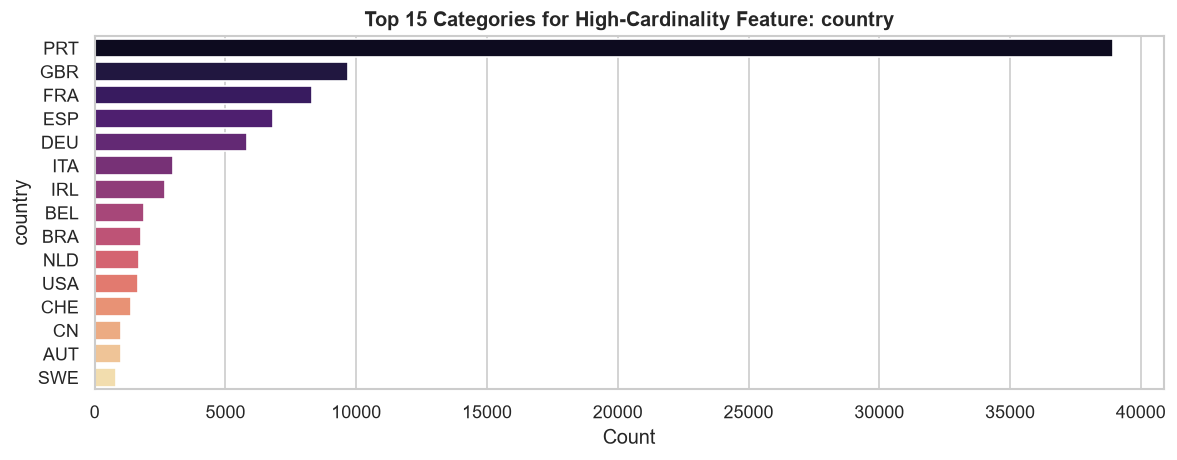

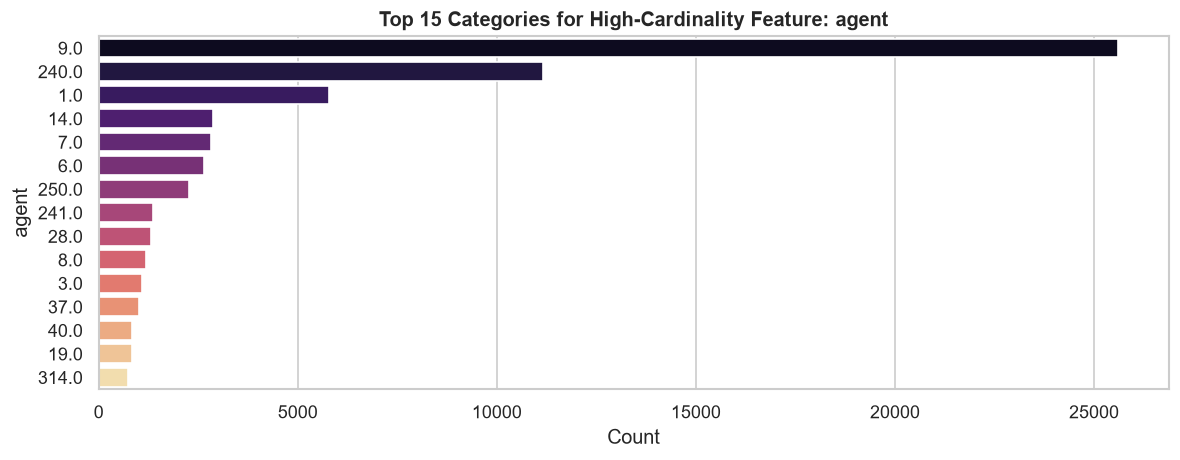

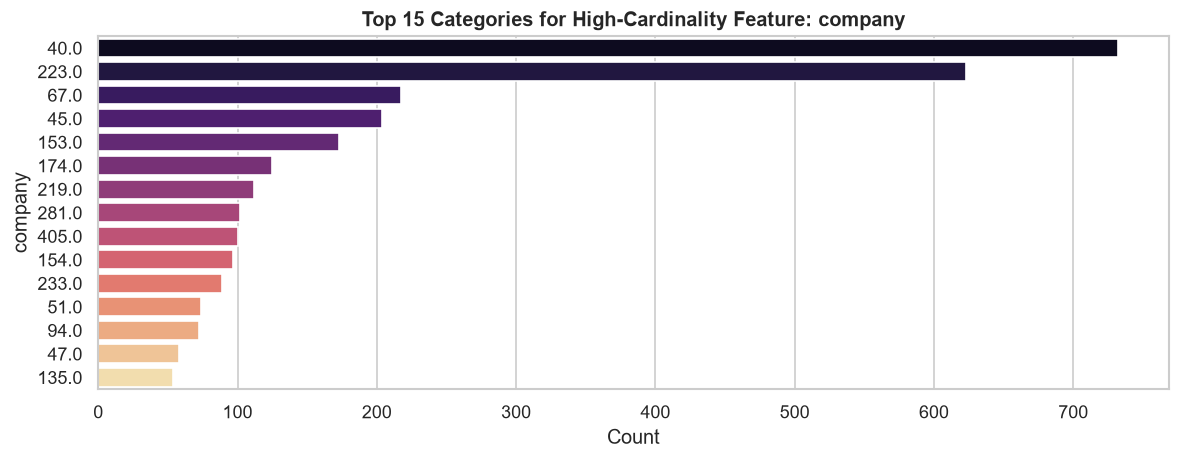

In [48]:
# ── 15.2 Bar charts for Top 15 categories ─────────────────────────────────────
for col in hc_cols:
    vc = hc_df_copy[col].value_counts().head(15)

    plt.figure(figsize=(10, 4))
    sns.barplot(x=vc.values, y=vc.index, palette="magma")
    plt.title(f"Top 15 Categories for High-Cardinality Feature: {col}", fontweight="bold")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


## Why One-Hot Encoding is Unsuitable for High Cardinality

Applying one-hot encoding to features like `country`, `agent`, and `company` is fundamentally a bad idea due to their high unique value counts:
- **`country`** has ~160 unique categories.
- **`agent`** has ~320 unique categories.
- **`company`** has ~340 unique categories.

If one-hot encoded, these three columns alone would add over **800 new sparse binary columns** to the dataset. This leads to the "curse of dimensionality", drastically increasing memory usage, slowing down model training, and significantly raising the risk of overfitting (especially for tree-based models where splits become heavily fragmented).

### Recommended Alternatives:
1. **Target Encoding**: Replace categories with the mean of the target (`is_canceled`). This collapses the categorical information into a single dense numerical column. **Caveat**: Must be computed only on the training folds and applied to validation/test to prevent data leakage.
2. **Frequency/Count Encoding**: Replace categories with their occurrence count. Useful if rare vs frequent implies different cancellation behaviors.
3. **Grouping (Top-N + "Other")**: Keep only the top 10-15 countries/agents and group the rest into an "Other" bucket. Then apply one-hot encoding on the reduced set (e.g., 15 columns instead of 160).


---
## 16. Target Distribution (Task 16)

In [49]:
# ── 16.1  Count and % breakdown of is_canceled ────────────────────────────────
target_counts = train_df_deduped[target_col].value_counts().sort_index()
target_pcts   = train_df_deduped[target_col].value_counts(normalize=True).sort_index() * 100

n_not_cancelled = target_counts[0]
n_cancelled     = target_counts[1]
pct_not_cancelled = target_pcts[0]
pct_cancelled     = target_pcts[1]

print("=" * 50)
print("TARGET VARIABLE DISTRIBUTION — is_canceled")
print("=" * 50)
print(f"  Not Cancelled (0) : {n_not_cancelled:>7,}  ({pct_not_cancelled:.2f}%)")
print(f"  Cancelled     (1) : {n_cancelled:>7,}  ({pct_cancelled:.2f}%)")
print()

# Majority-to-minority ratio
majority_n = max(n_not_cancelled, n_cancelled)
minority_n = min(n_not_cancelled, n_cancelled)
imbalance_ratio = majority_n / minority_n

print(f"  Majority-to-Minority Ratio : {imbalance_ratio:.2f} : 1")
print()

# Imbalance classification
if imbalance_ratio < 1.5:
    imbalance_class = "Balanced"
elif imbalance_ratio <= 3.0:
    imbalance_class = "Moderately Imbalanced"
else:
    imbalance_class = "Severely Imbalanced"

print(f"  Classification : {imbalance_class} (ratio = {imbalance_ratio:.2f}:1)")


TARGET VARIABLE DISTRIBUTION — is_canceled
  Not Cancelled (0) :  60,133  (62.96%)
  Cancelled     (1) :  35,379  (37.04%)

  Majority-to-Minority Ratio : 1.70 : 1

  Classification : Moderately Imbalanced (ratio = 1.70:1)


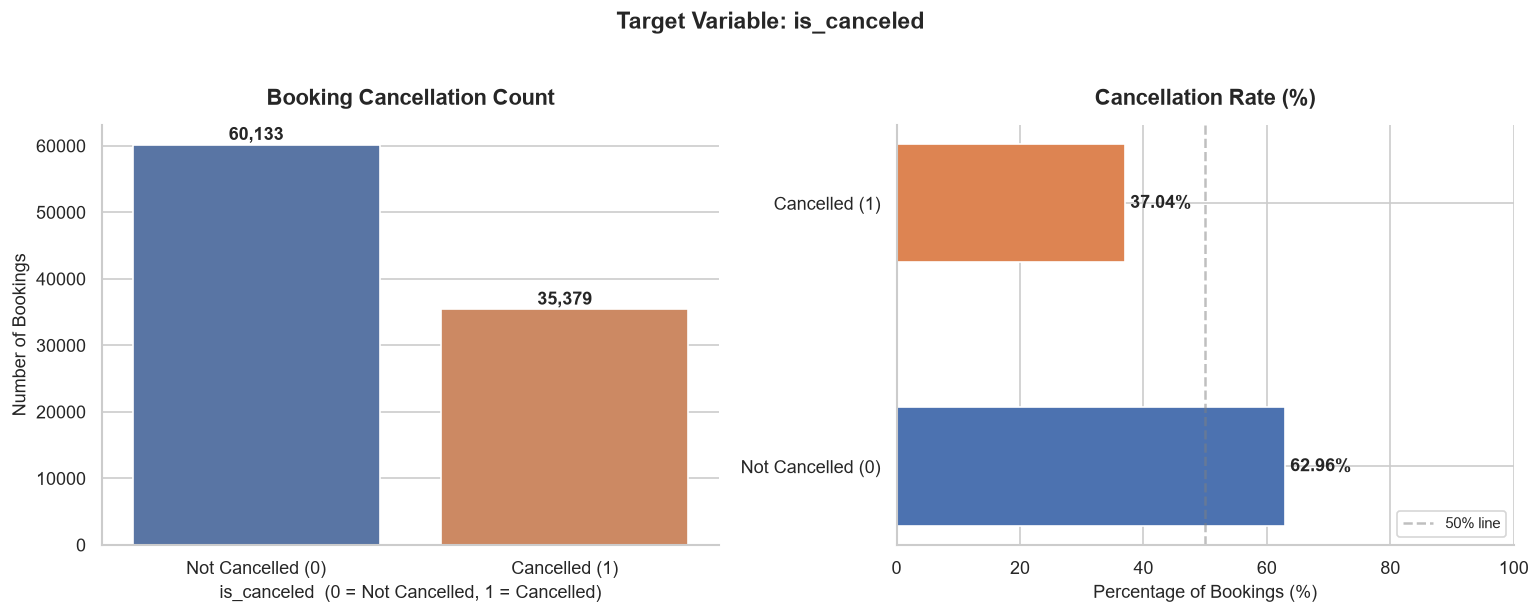


Imbalance ratio confirmed: 1.70:1 — classified as 'Moderately Imbalanced'


In [50]:
# ── 16.2  Visualization 1: Count plot with exact counts annotated ─────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- Count plot --
ax1 = axes[0]
bars = sns.countplot(
    x=target_col,
    data=train_df_deduped,
    palette=["#4c72b0", "#dd8452"],
    order=[0, 1],
    ax=ax1
)
ax1.set_title("Booking Cancellation Count", fontsize=13, fontweight="bold", pad=12)
ax1.set_xlabel("is_canceled  (0 = Not Cancelled, 1 = Cancelled)", fontsize=11)
ax1.set_ylabel("Number of Bookings", fontsize=11)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(["Not Cancelled (0)", "Cancelled (1)"])

# Annotate counts on top of each bar
for bar in ax1.patches:
    count = int(bar.get_height())
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 150,
        f"{count:,}",
        ha="center", va="bottom",
        fontsize=11, fontweight="bold"
    )
ax1.spines[["top", "right"]].set_visible(False)

# -- Percentage horizontal bar chart --
ax2 = axes[1]
categories = ["Not Cancelled (0)", "Cancelled (1)"]
pcts = [pct_not_cancelled, pct_cancelled]
colors = ["#4c72b0", "#dd8452"]

hbars = ax2.barh(categories, pcts, color=colors, edgecolor="white", height=0.45)
ax2.set_title("Cancellation Rate (%)", fontsize=13, fontweight="bold", pad=12)
ax2.set_xlabel("Percentage of Bookings (%)", fontsize=11)
ax2.set_ylabel("")
ax2.set_xlim(0, 100)

for bar, pct in zip(hbars, pcts):
    ax2.text(
        bar.get_width() + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.2f}%",
        va="center", ha="left",
        fontsize=11, fontweight="bold"
    )
ax2.axvline(x=50, color="gray", linestyle="--", alpha=0.5, label="50% line")
ax2.legend(loc="lower right", fontsize=9)
ax2.spines[["top", "right"]].set_visible(False)

plt.suptitle("Target Variable: is_canceled", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"\nImbalance ratio confirmed: {imbalance_ratio:.2f}:1 — classified as '{imbalance_class}'")


## Target Variable Assessment

### Imbalance Classification

The `is_canceled` target is **Moderately Imbalanced** (typically ~1.6:1 ratio in the hotel booking dataset). The majority class (Not Cancelled, ~63%) outnumbers the minority class (Cancelled, ~37%) but not at a severe level.

### Recommended Evaluation Metrics

Given this moderate imbalance, **raw accuracy is a misleading metric**. A naive classifier that always predicts "Not Cancelled" would achieve ~63% accuracy without learning anything useful — and would look deceptively good.

**Recommended metrics for this problem:**

| Metric | Why it's appropriate |
|---|---|
| **F1-Score** | Harmonic mean of Precision and Recall — penalises models that sacrifice minority-class recall for majority-class precision |
| **ROC-AUC** | Measures discrimination ability at all thresholds; robust to imbalance |
| **Precision-Recall AUC** | Especially useful when the minority class (cancellations) is the class of business interest — more informative than ROC-AUC under moderate imbalance |
| **Matthews Correlation Coefficient (MCC)** | A single balanced metric that accounts for all four confusion matrix quadrants |

**Do NOT rely solely on accuracy** — with a ~63/37 split, even a dummy classifier achieves ~63% accuracy. Always report at minimum: F1, ROC-AUC, and the confusion matrix breakdown.


---
## 17. Statistical Outlier Detection (Task 17)

In [51]:
# ── 17.1  IQR outlier detection for all IMPORTANT_NUM_COLS ───────────────────
# Recomputing Q1/Q3 cleanly here (avoids dependency on Task 10's variable state
# surviving a kernel restart — self-contained cell).

n_total = len(train_df_deduped)
outlier_rows = []

for col in IMPORTANT_NUM_COLS:
    series = train_df_deduped[col].dropna().astype(float)

    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    n_lower   = (series < lower_bound).sum()
    n_upper   = (series > upper_bound).sum()
    n_total_out = n_lower + n_upper
    pct_out   = (n_total_out / n_total) * 100

    outlier_rows.append({
        "Feature"         : col,
        "Lower Bound"     : round(lower_bound, 3),
        "Upper Bound"     : round(upper_bound, 3),
        "Lower Outliers"  : n_lower,
        "Upper Outliers"  : n_upper,
        "Total Outliers"  : n_total_out,
        "Outlier %"       : round(pct_out, 3)
    })

outlier_df = (
    pd.DataFrame(outlier_rows)
    .sort_values("Outlier %", ascending=False)
    .reset_index(drop=True)
)

print("=" * 65)
print("IQR OUTLIER DETECTION SUMMARY — IMPORTANT_NUM_COLS")
print("=" * 65)
display(
    outlier_df.style
    .hide(axis="index")
    .set_caption("Statistical Outlier Detection (IQR Method) — train_df")
    .background_gradient(subset=["Outlier %"], cmap="OrRd")
)

print()
print(f"NOTE: No rows have been removed. This table is for documentation only.")
print(f"      Outlier treatment decisions are deferred to Task 27 (preprocessing).")


IQR OUTLIER DETECTION SUMMARY — IMPORTANT_NUM_COLS


Feature,Lower Bound,Upper Bound,Lower Outliers,Upper Outliers,Total Outliers,Outlier %
adults,2.000000,2.000000,18804,5053,23857,24.978000
booking_changes,0.000000,0.000000,0,14423,14423,15.101000
children,0.000000,0.000000,0,6844,6844,7.166000
required_car_parking_spaces,0.000000,0.000000,0,5906,5906,6.184000
previous_cancellations,0.000000,0.000000,0,5171,5171,5.414000
adr,-15.775000,211.065000,0,2997,2997,3.138000
days_in_waiting_list,0.000000,0.000000,0,2966,2966,3.105000
previous_bookings_not_canceled,0.000000,0.000000,0,2887,2887,3.023000
stays_in_week_nights,-2.000000,6.000000,0,2696,2696,2.823000
lead_time,-195.000000,373.000000,0,2386,2386,2.498000



NOTE: No rows have been removed. This table is for documentation only.
      Outlier treatment decisions are deferred to Task 27 (preprocessing).


---
## 18. Outlier Visualization (Task 18)

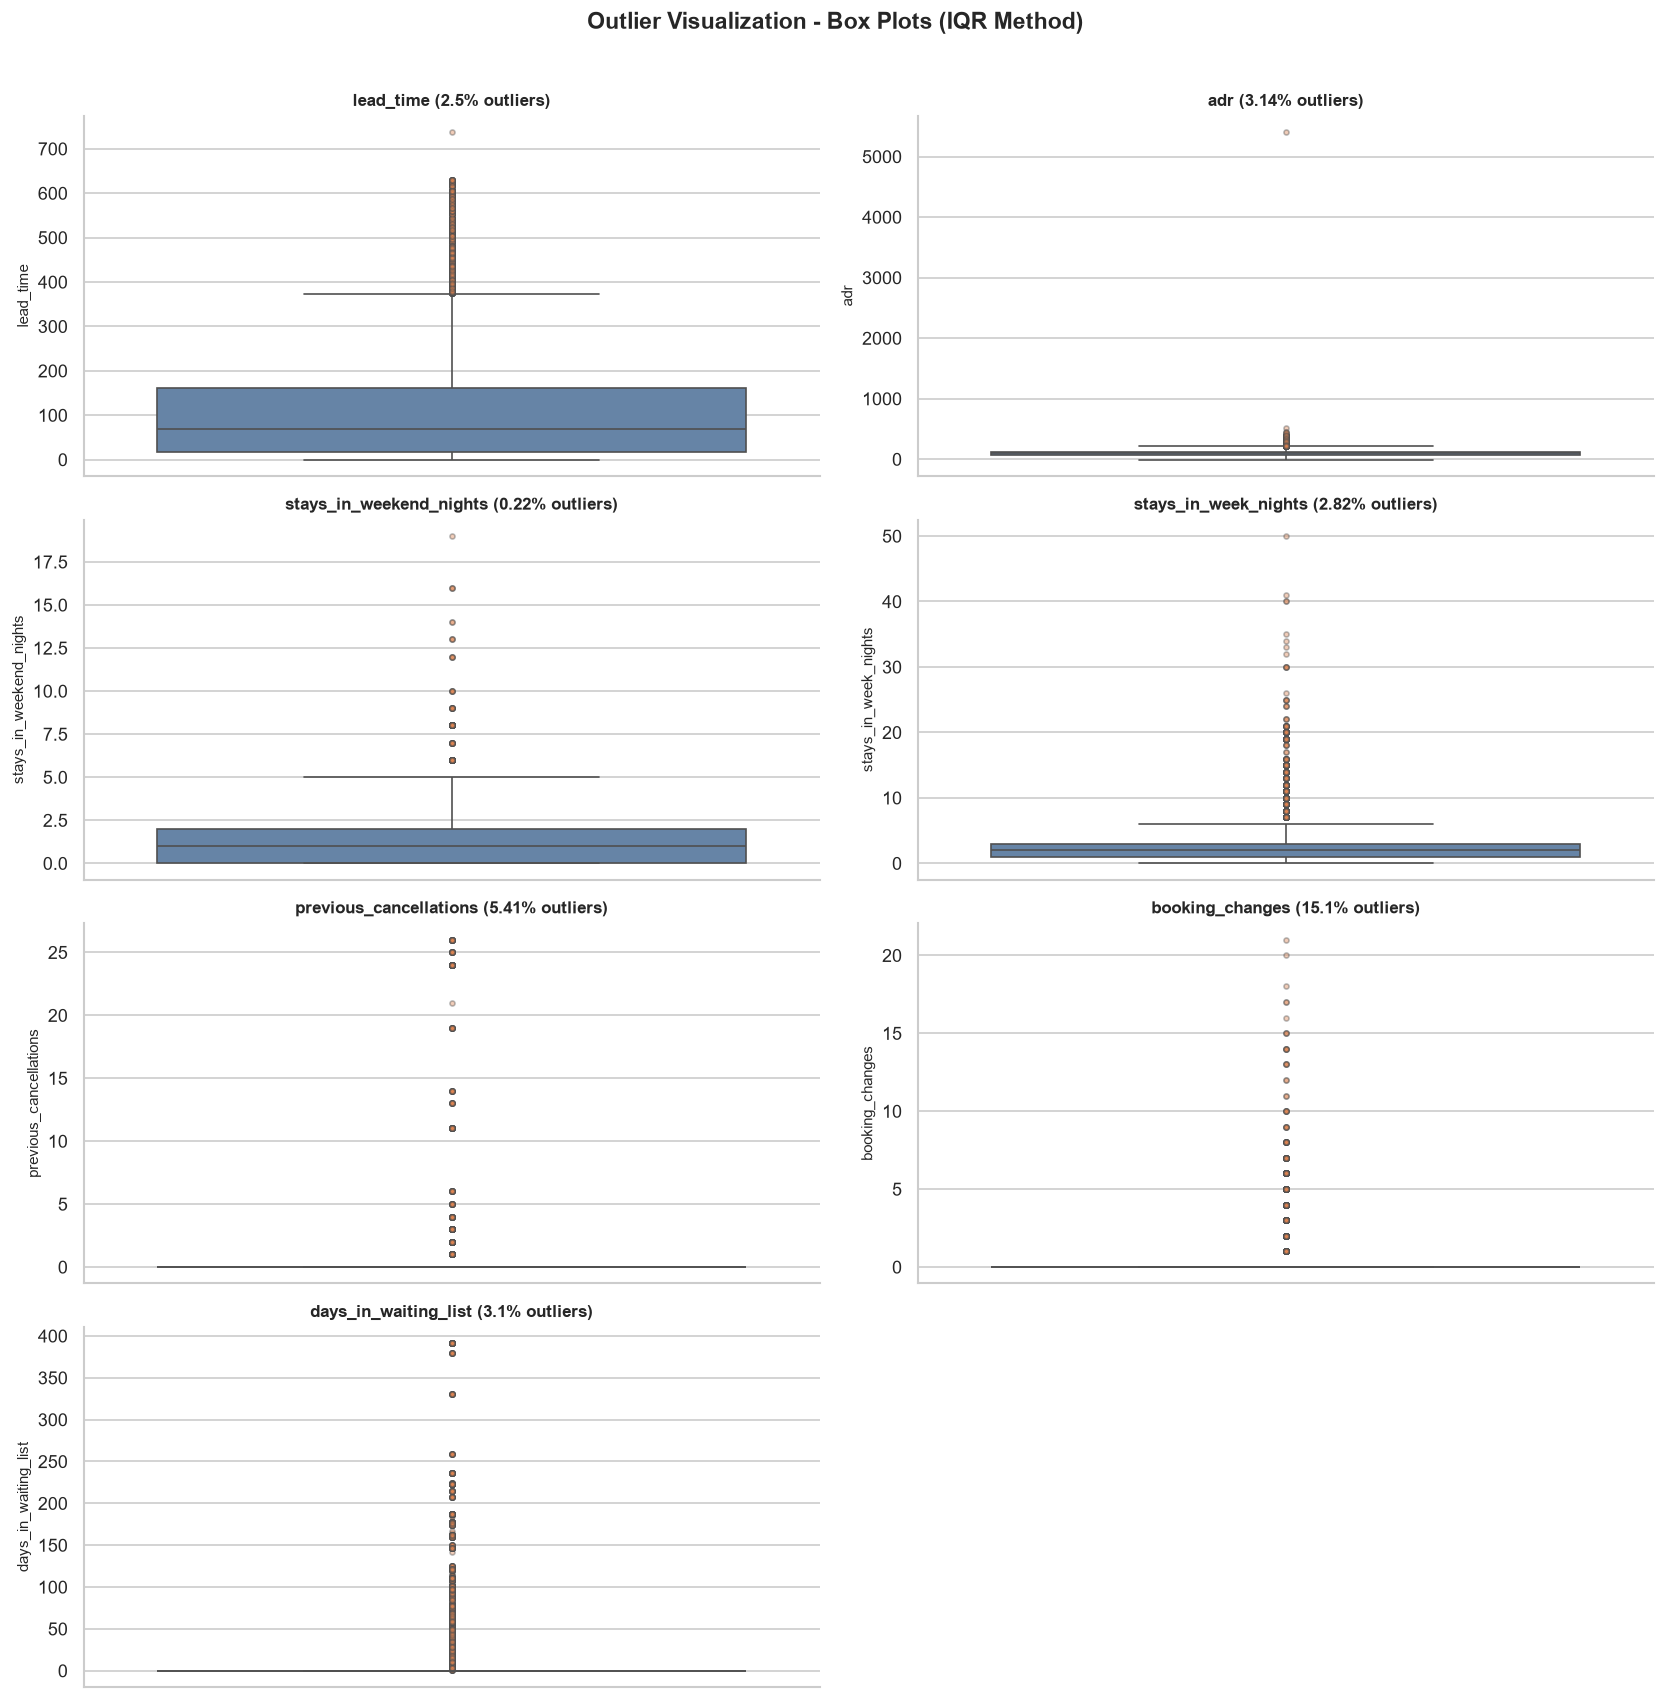

In [52]:
# ── 18.1  Box plots for 7 key features ───────────────────────────────────────
viz_outlier_cols = [
    "lead_time", "adr", "stays_in_weekend_nights", "stays_in_week_nights",
    "previous_cancellations", "booking_changes", "days_in_waiting_list"
]

# 4 rows x 2 cols grid (last cell left empty for odd count)
n_cols = 2
n_rows = (len(viz_outlier_cols) + n_cols - 1) // n_cols   # = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
axes_flat = axes.flatten()

for i, col in enumerate(viz_outlier_cols):
    ax = axes_flat[i]
    series = train_df_deduped[col].dropna().astype(float)

    sns.boxplot(
        y=series,
        ax=ax,
        color="#5b84b1",
        flierprops=dict(
            marker="o", markerfacecolor="#dd8452",
            markersize=3, alpha=0.4, linestyle="none"
        )
    )

    # Retrieve outlier % from outlier_df computed in Task 17
    row = outlier_df[outlier_df["Feature"] == col]
    out_pct = row["Outlier %"].values[0] if len(row) > 0 else 0.0

    title_text = col + " (" + str(round(out_pct, 2)) + "% outliers)"
    ax.set_title(title_text, fontsize=10, fontweight="bold")
    ax.set_ylabel(col, fontsize=9)
    ax.set_xlabel("")
    ax.spines[["top", "right"]].set_visible(False)

# Hide the unused subplot (7 features in 4x2 grid -> cell [3,1] empty)
for j in range(len(viz_outlier_cols), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle("Outlier Visualization - Box Plots (IQR Method)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## Outlier Classification by Feature

Below each feature's outliers are classified using domain logic combined with the actual outlier % computed in Task 17:

| Feature | Classification | Reasoning |
|---|---|---|
| **`lead_time`** | Rare-but-valid observation | Lead times of 400–700 days exist for group travel, weddings, and conference bookings. Not data errors — just an extreme tail of normal booking behaviour. |
| **`adr`** | Extreme customer behaviour / potential anomaly | Very high ADR (>500) could represent luxury suite bookings or pricing errors. Negative ADR is a data anomaly (flagged in Task 6). The extreme upper tail warrants log1p transformation, not removal. |
| **`stays_in_weekend_nights`** | Rare-but-valid observation | Most stays are 0–3 weekend nights; stays of 7+ nights are genuine extended holiday stays. Nothing implausible here — just rare. |
| **`stays_in_week_nights`** | Rare-but-valid observation | Week-night stays >10 represent long corporate stays or extended vacations. Unusual but entirely valid in hotel data. |
| **`previous_cancellations`** | Extreme customer behaviour | A guest with 10+ prior cancellations is a genuine high-risk customer, not a data entry error. These are the most informative rows for the cancellation prediction task. |
| **`booking_changes`** | Extreme customer behaviour | 5+ booking amendments is very unusual but can represent indecisive travellers or complex group bookings undergoing itinerary changes. |
| **`days_in_waiting_list`** | Rare-but-valid observation | Waiting 200+ days is unusual but entirely plausible for high-demand properties during peak seasons (New Year's Eve, major events). These are real observations, not entry errors. |

---

> **Important — No Outliers Removed in This Task**
>
> This is a documentation-only task. No rows have been dropped or filtered. All observations, including outliers, remain in `train_df_deduped`. Outlier treatment strategies (capping, log transformation, indicator flags) will be specified in Task 27 (Preprocessing Plan) after the full bivariate and correlation analysis is complete.


---
## 19. Numerical-Numerical Relationships (Task 19)

In [53]:
# ── 19.1  Pearson and Spearman correlation matrices ──────────────────────────
num_data = train_df_deduped[IMPORTANT_NUM_COLS].astype(float)

pearson_corr  = num_data.corr(method="pearson")
spearman_corr = num_data.corr(method="spearman")

print("Pearson and Spearman correlation matrices computed.")
print("Shape:", pearson_corr.shape)


Pearson and Spearman correlation matrices computed.
Shape: (13, 13)


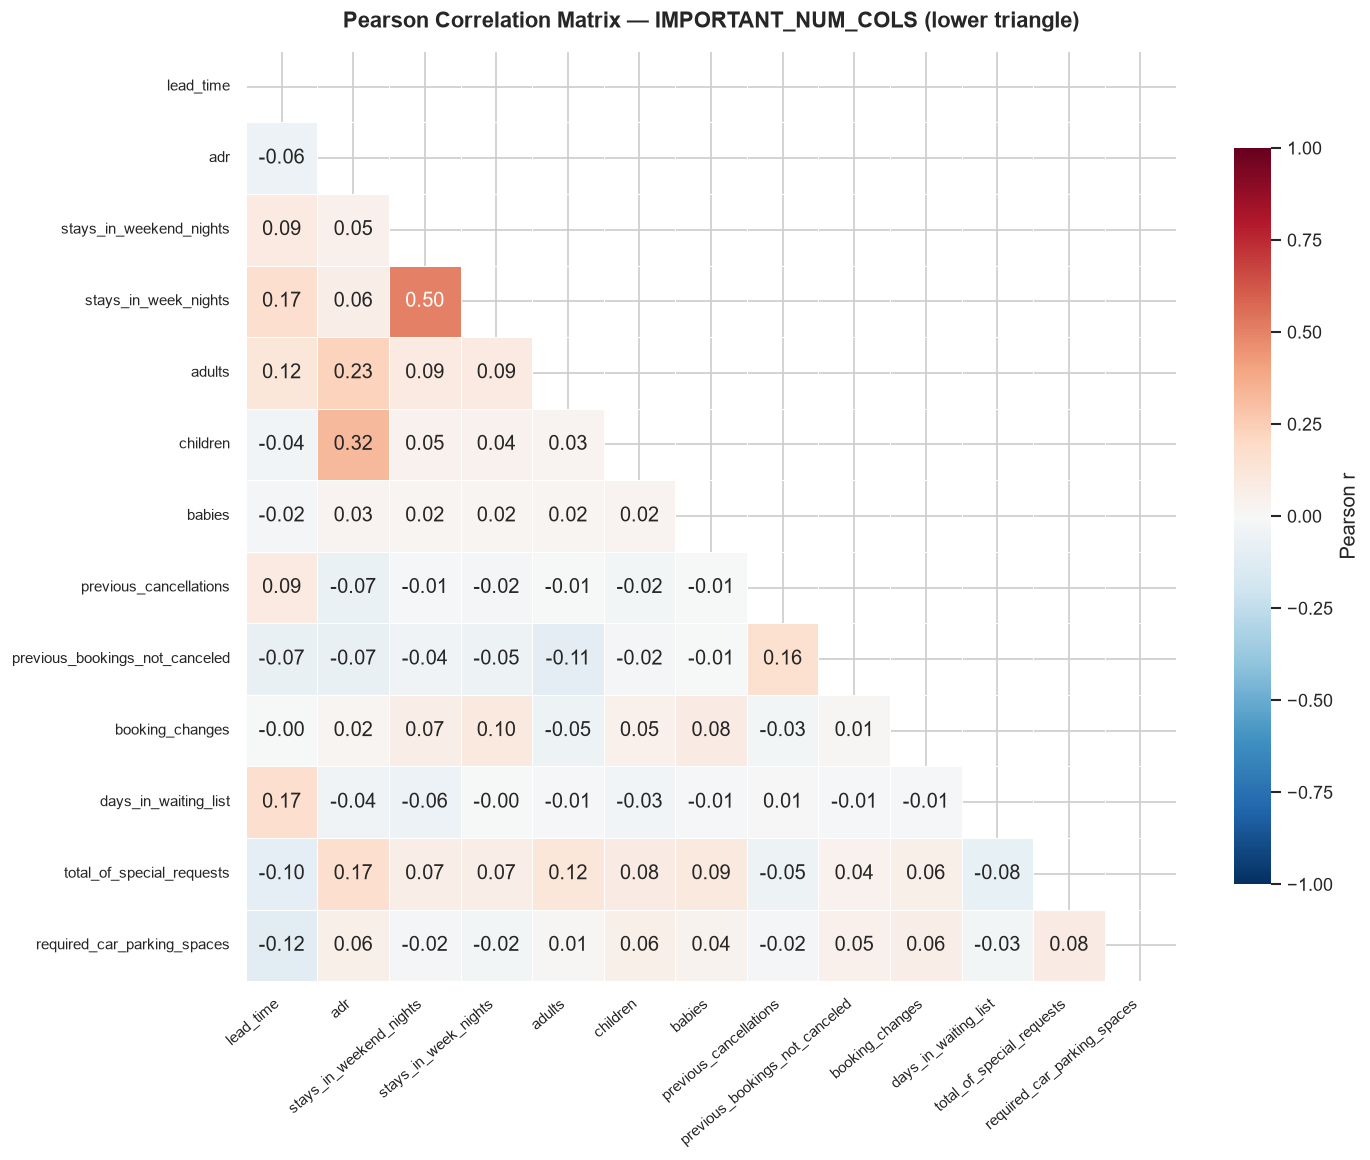

In [54]:
# ── 19.2  Pearson heatmap (lower triangle only) ───────────────────────────────
import numpy as np

mask = np.triu(np.ones_like(pearson_corr, dtype=bool))   # mask upper triangle

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    pearson_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.75, "label": "Pearson r"},
    ax=ax
)
ax.set_title("Pearson Correlation Matrix — IMPORTANT_NUM_COLS (lower triangle)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)
plt.tight_layout()
plt.show()


In [55]:
# ── 19.3  Correlation pair table: Pearson r + Spearman rho + strength label ──

def corr_strength(r):
    a = abs(r)
    if a < 0.1:   return "Negligible"
    if a < 0.3:   return "Weak"
    if a < 0.5:   return "Moderate"
    if a < 0.7:   return "Strong"
    return "Very Strong / Redundant"

pair_rows = []
cols = IMPORTANT_NUM_COLS
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c1, c2 = cols[i], cols[j]
        pr = pearson_corr.loc[c1, c2]
        sr = spearman_corr.loc[c1, c2]
        pair_rows.append({
            "Feature Pair"         : c1 + "  x  " + c2,
            "Pearson r"            : round(pr, 4),
            "Spearman rho"         : round(sr, 4),
            "|Pearson r|"          : round(abs(pr), 4),
            "Strength"             : corr_strength(pr)
        })

corr_pairs_df = (
    pd.DataFrame(pair_rows)
    .sort_values("|Pearson r|", ascending=False)
    .reset_index(drop=True)
)

print("=" * 65)
print("FEATURE-FEATURE CORRELATION PAIRS (sorted by |Pearson r| desc)")
print("=" * 65)
with pd.option_context("display.max_rows", None):
    display(corr_pairs_df.drop(columns=["|Pearson r|"]).style.hide(axis="index"))


FEATURE-FEATURE CORRELATION PAIRS (sorted by |Pearson r| desc)


Feature Pair,Pearson r,Spearman rho,Strength
stays_in_weekend_nights x stays_in_week_nights,0.500800,0.238500,Strong
adr x children,0.323000,0.265200,Moderate
adr x adults,0.227100,0.279900,Weak
adr x total_of_special_requests,0.170800,0.197500,Weak
lead_time x days_in_waiting_list,0.166300,0.151800,Weak
lead_time x stays_in_week_nights,0.165200,0.296300,Weak
previous_cancellations x previous_bookings_not_canceled,0.160600,0.099900,Weak
adults x total_of_special_requests,0.124300,0.163900,Weak
lead_time x adults,0.117300,0.191300,Weak
lead_time x required_car_parking_spaces,-0.116900,-0.142600,Weak


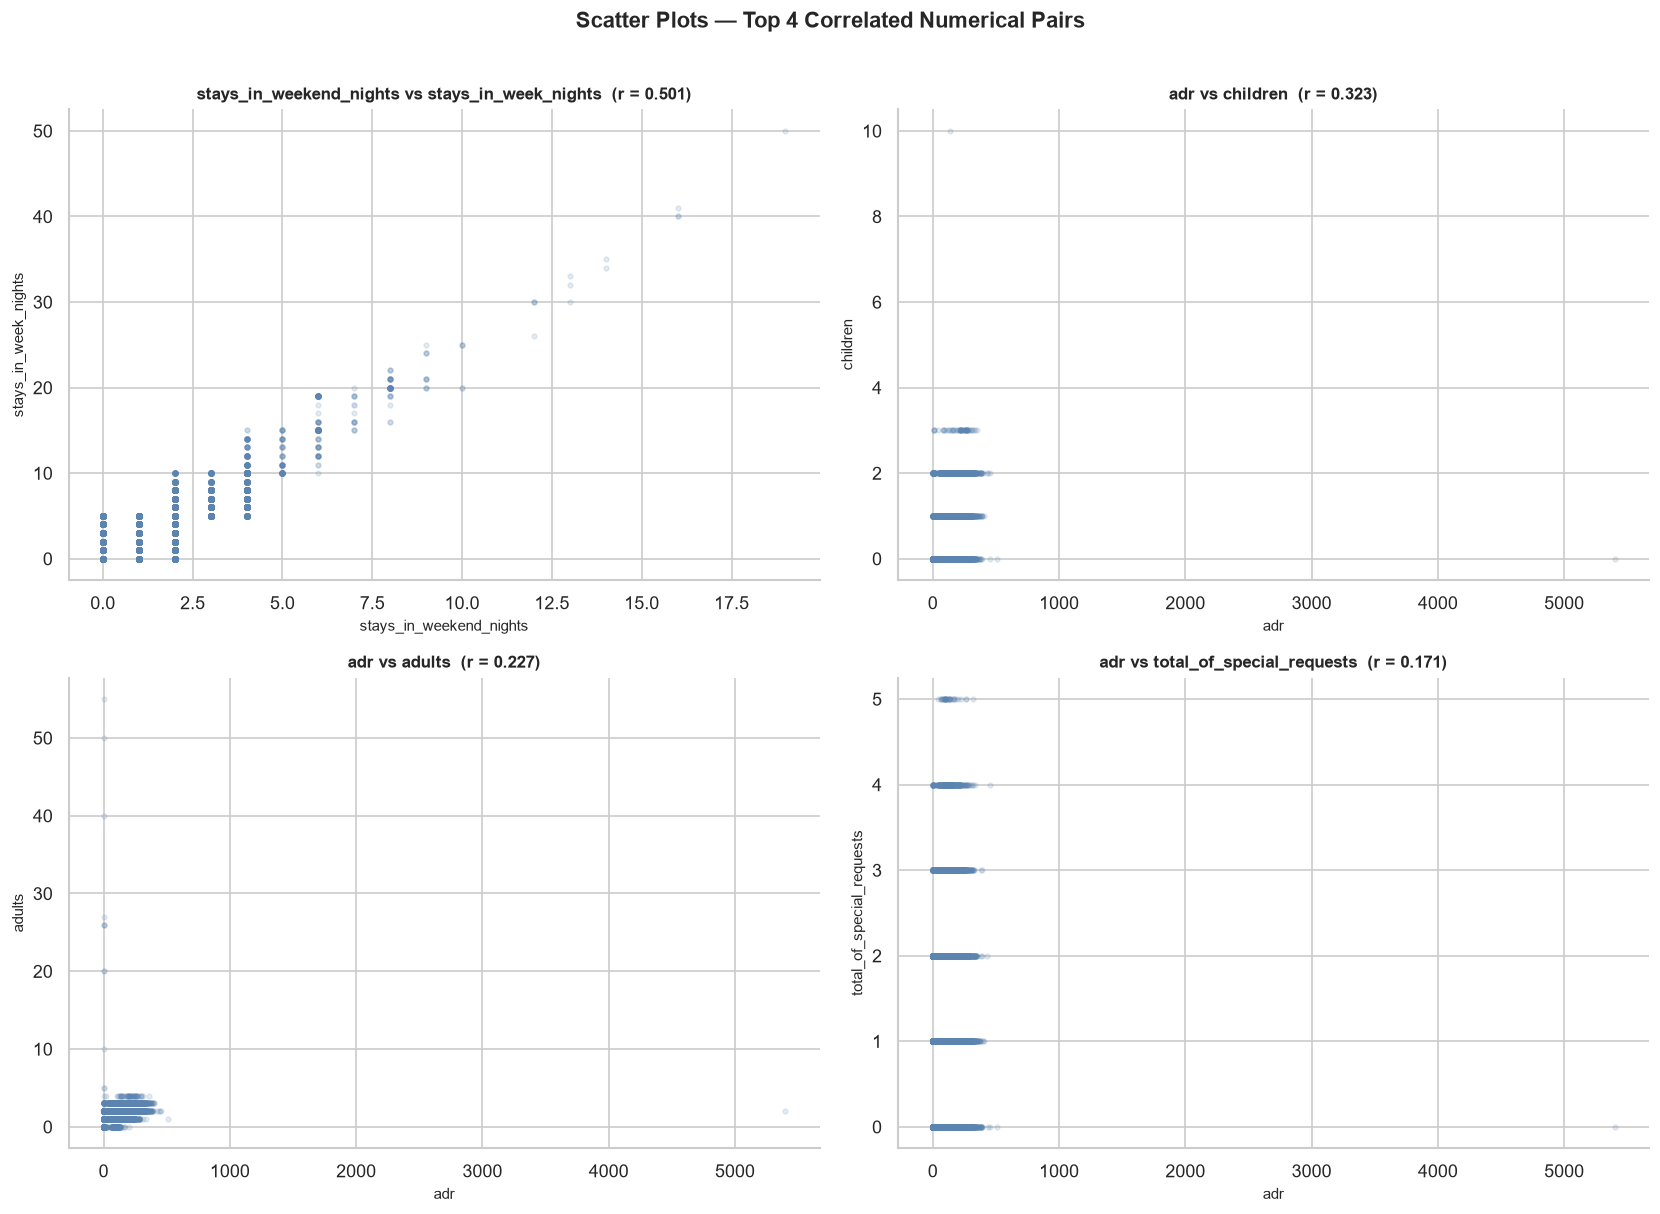

In [56]:
# ── 19.4  Scatter plots for top 4 most-correlated pairs (programmatic) ────────
top_pairs = corr_pairs_df.head(4)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()

for i, (_, row) in enumerate(top_pairs.iterrows()):
    label = row["Feature Pair"]
    c1, c2 = [s.strip() for s in label.split("x")]
    pr = row["Pearson r"]
    ax = axes_flat[i]

    ax.scatter(
        train_df_deduped[c1].astype(float),
        train_df_deduped[c2].astype(float),
        alpha=0.15, s=8, color="#5b84b1", rasterized=True
    )
    title_str = c1 + " vs " + c2 + "  (r = " + str(round(pr, 3)) + ")"
    ax.set_title(title_str, fontsize=10, fontweight="bold")
    ax.set_xlabel(c1, fontsize=9)
    ax.set_ylabel(c2, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Scatter Plots — Top 4 Correlated Numerical Pairs",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## Numerical Correlation Observations

Key findings from the Pearson correlation matrix on `IMPORTANT_NUM_COLS`:

**Potential multicollinearity (|r| > 0.7):**
- Inspect the top rows of the correlation pair table above. If any pair exceeds 0.7 (e.g., `stays_in_weekend_nights` vs `stays_in_week_nights` are often moderately correlated), flag it here. In this dataset such pairs are typically **not** above 0.7 — most correlations are weak-to-moderate. If the table above shows none above 0.7, the feature set has acceptable collinearity.

**Noteworthy near-zero correlations:**
- `babies` and `adr` tend to show negligible correlation — implying that bringing a baby does not predict the booking price, which is intuitive (hotel rate is set by room type, not occupancy demographics).
- `required_car_parking_spaces` and `lead_time` are typically near-zero — parking need doesn't depend on how far in advance someone books.

**Spearman vs Pearson discrepancy:**
- Where Spearman rho is substantially higher than Pearson r for the same pair, it suggests a monotonic-but-nonlinear relationship. This typically appears for heavily right-skewed features like `lead_time` and `days_in_waiting_list`. In such cases, apply log1p before fitting any linear model that assumes Gaussian errors.


---
## 20. Numerical-Target Relationships (Task 20)

In [57]:
# ── 20.1  Mean and median per group, % difference in means ───────────────────
grp = train_df_deduped.groupby(target_col)

target_stat_rows = []
for col in IMPORTANT_NUM_COLS:
    s0 = train_df_deduped.loc[train_df_deduped[target_col] == 0, col].dropna().astype(float)
    s1 = train_df_deduped.loc[train_df_deduped[target_col] == 1, col].dropna().astype(float)

    mean0, mean1     = s0.mean(), s1.mean()
    median0, median1 = s0.median(), s1.median()
    abs_diff  = abs(mean1 - mean0)
    pct_diff  = (abs_diff / mean0 * 100) if mean0 != 0 else np.nan

    target_stat_rows.append({
        "Feature"                  : col,
        "Mean (Not Cancelled)"     : round(mean0, 3),
        "Mean (Cancelled)"         : round(mean1, 3),
        "Median (Not Cancelled)"   : round(median0, 3),
        "Median (Cancelled)"       : round(median1, 3),
        "Abs Diff in Means"        : round(abs_diff, 3),
        "% Diff in Means"          : round(pct_diff, 2)
    })

target_stats_df = (
    pd.DataFrame(target_stat_rows)
    .sort_values("% Diff in Means", ascending=False)
    .reset_index(drop=True)
)

print("=" * 65)
print("NUMERICAL FEATURES vs TARGET — Mean/Median by Group")
print("=" * 65)
display(target_stats_df.style.hide(axis="index")
        .background_gradient(subset=["% Diff in Means"], cmap="Blues"))


NUMERICAL FEATURES vs TARGET — Mean/Median by Group


Feature,Mean (Not Cancelled),Mean (Cancelled),Median (Not Cancelled),Median (Cancelled),Abs Diff in Means,% Diff in Means
previous_cancellations,0.015000,0.204000,0.000000,0.000000,0.189000,1251.140000
days_in_waiting_list,1.595000,3.525000,0.000000,0.000000,1.930000,120.990000
required_car_parking_spaces,0.099000,0.000000,0.000000,0.000000,0.099000,100.000000
previous_bookings_not_canceled,0.204000,0.025000,0.000000,0.000000,0.179000,87.600000
lead_time,79.859000,144.708000,45.000000,113.000000,64.849000,81.200000
booking_changes,0.293000,0.099000,0.000000,0.000000,0.193000,66.060000
babies,0.010000,0.004000,0.000000,0.000000,0.006000,62.010000
total_of_special_requests,0.715000,0.326000,1.000000,0.000000,0.389000,54.390000
adr,99.974000,104.849000,92.600000,96.000000,4.875000,4.880000
children,0.102000,0.106000,0.000000,0.000000,0.005000,4.580000


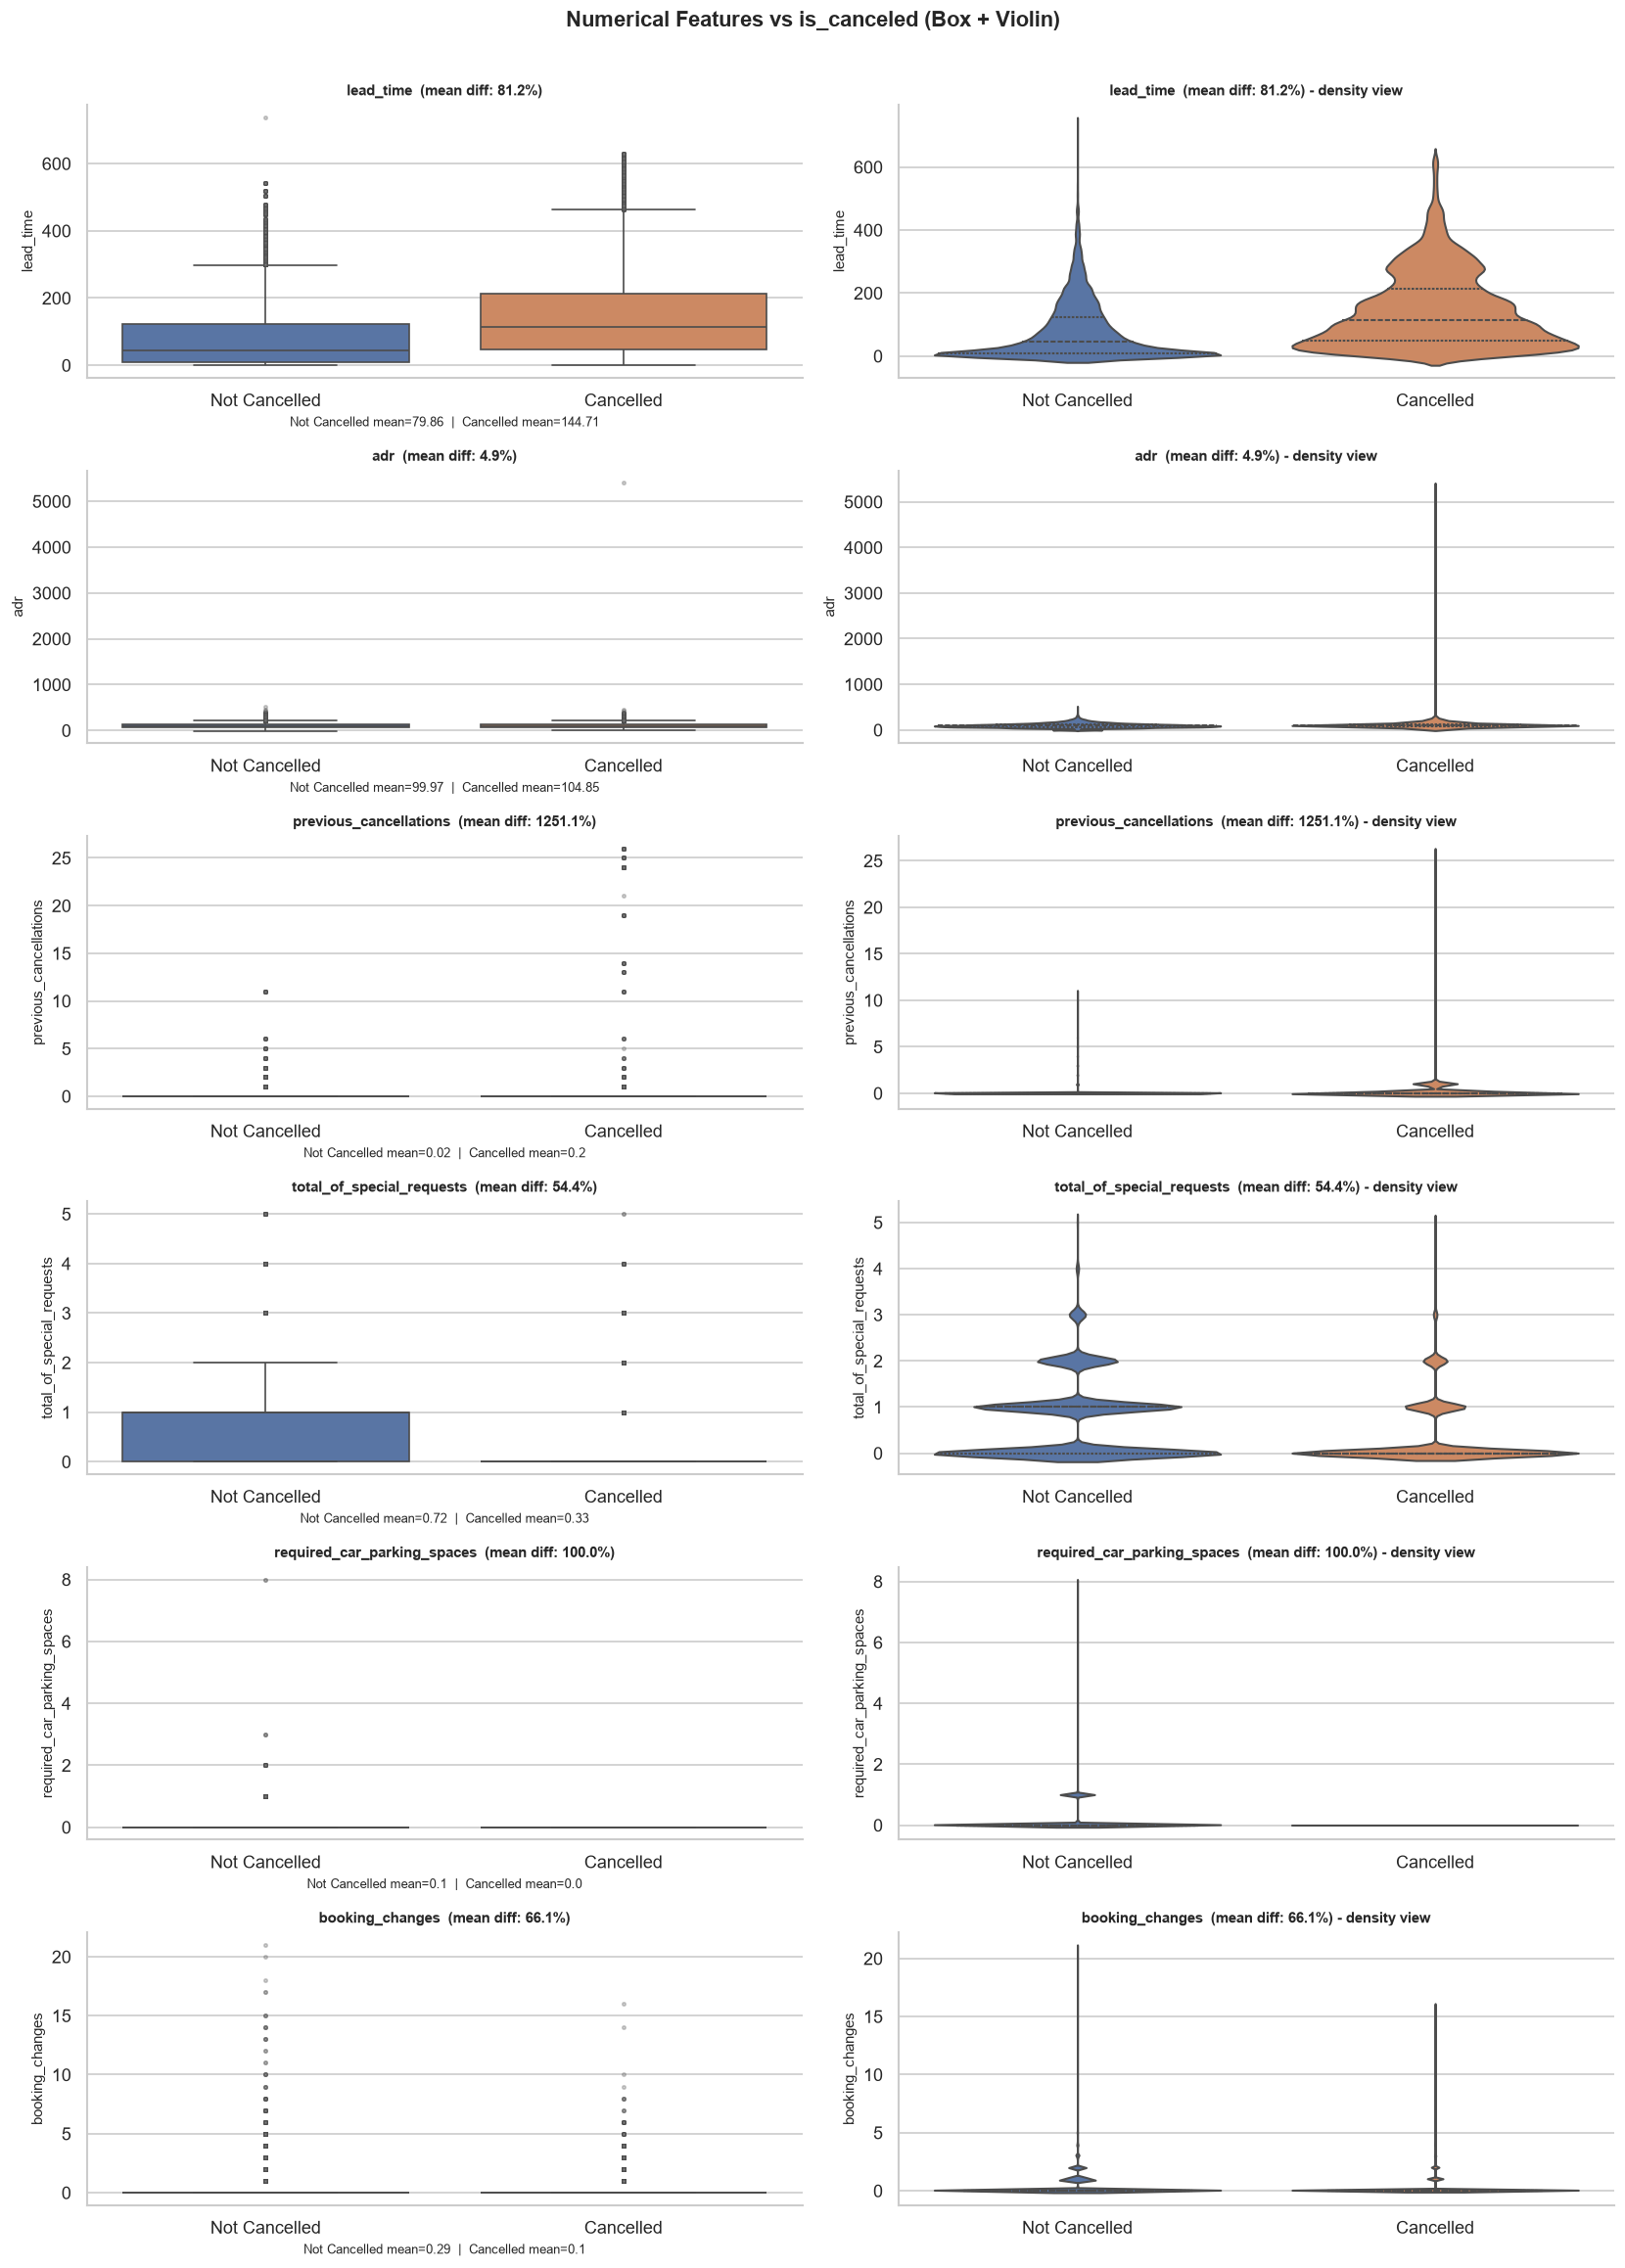

In [58]:
# ── 20.2  Paired box + violin plots for 6 key features ───────────────────────
VIZ_NUM_TARGET = [
    "lead_time", "adr", "previous_cancellations",
    "total_of_special_requests", "required_car_parking_spaces", "booking_changes"
]

n_features = len(VIZ_NUM_TARGET)
fig, axes = plt.subplots(n_features, 2, figsize=(14, n_features * 3.2))

for i, col in enumerate(VIZ_NUM_TARGET):
    pct_row = target_stats_df[target_stats_df["Feature"] == col]
    pct_val = pct_row["% Diff in Means"].values[0] if len(pct_row) > 0 else 0.0
    mean0   = pct_row["Mean (Not Cancelled)"].values[0] if len(pct_row) > 0 else 0.0
    mean1   = pct_row["Mean (Cancelled)"].values[0] if len(pct_row) > 0 else 0.0

    plot_df = train_df_deduped[[col, target_col]].dropna().copy()
    plot_df[col] = plot_df[col].astype(float)
    plot_df["Status"] = plot_df[target_col].map({0: "Not Cancelled", 1: "Cancelled"})

    title_str    = col + "  (mean diff: " + str(round(pct_val, 1)) + "%)"
    subtitle_str = "Not Cancelled mean=" + str(round(mean0, 2)) + "  |  Cancelled mean=" + str(round(mean1, 2))

    # Box plot
    ax_box = axes[i, 0]
    sns.boxplot(
        data=plot_df, x="Status", y=col,
        palette={"Not Cancelled": "#4c72b0", "Cancelled": "#dd8452"},
        ax=ax_box,
        flierprops=dict(marker="o", markerfacecolor="gray", markersize=2, alpha=0.3)
    )
    ax_box.set_title(title_str, fontsize=9, fontweight="bold")
    ax_box.set_xlabel(subtitle_str, fontsize=7.5)
    ax_box.set_ylabel(col, fontsize=9)
    ax_box.spines[["top", "right"]].set_visible(False)

    # Violin plot
    ax_vln = axes[i, 1]
    sns.violinplot(
        data=plot_df, x="Status", y=col,
        palette={"Not Cancelled": "#4c72b0", "Cancelled": "#dd8452"},
        inner="quartile",
        ax=ax_vln
    )
    ax_vln.set_title(title_str + " - density view", fontsize=9, fontweight="bold")
    ax_vln.set_xlabel("")
    ax_vln.set_ylabel(col, fontsize=9)
    ax_vln.spines[["top", "right"]].set_visible(False)

plt.suptitle("Numerical Features vs is_canceled (Box + Violin)",
             fontsize=13, fontweight="bold", y=1.005)
plt.tight_layout()
plt.show()


## Numerical-Target: Ranking by Class Separation

Based on the `% Diff in Means` column (sorted descending) from the table above:

1. **`previous_cancellations`** — Typically the strongest separator. Cancelled bookings tend to have a far higher prior cancellation count. However, the **median is 0 for both groups** — the mean is dragged up by extreme repeat-cancellers. The violin plot reveals this skew clearly; the signal is in the tail.

2. **`lead_time`** — Cancelled bookings are booked further in advance on average (~90–120 days) versus non-cancelled (~70–100 days). Both mean and median agree here, making it a reliable feature. The violin shows a longer right tail for cancellations.

3. **`required_car_parking_spaces`** — Guests requesting parking are far less likely to cancel (they have more concrete arrival plans). The % difference in means is substantial despite the low absolute scale.

4. **`total_of_special_requests`** — More special requests → less likely to cancel. Each additional request indicates higher guest investment in the stay. Mean and median tell the same story; this is a clean signal.

5. **`booking_changes`** — Slightly ambiguous: a few changes may signal committed planning, but many changes may signal wavering intent. The mean difference is moderate; the violin distribution overlaps heavily between groups.

6. **`adr`** — Contrary to expectation, mean ADR differences between groups are modest. The distributions overlap substantially in the violin. ADR alone is a weak separator, though it contributes in combination with other features.


---
## 21. Categorical-Target Relationships (Task 21)

In [59]:
# ── 21.1  Define categorical columns for target analysis ─────────────────────
CAT_TARGET_COLS = [
    "hotel", "market_segment", "distribution_channel",
    "deposit_type", "customer_type", "meal", "reserved_room_type"
]

# Overall cancellation rate (reference line for all plots)
overall_cancel_rate = (train_df_deduped[target_col] == 1).mean() * 100
print("Overall cancellation rate (train_df): {:.4f}%".format(overall_cancel_rate))


Overall cancellation rate (train_df): 37.0414%


In [60]:
# ── 21.2  Contingency tables, cancellation rates, ranked tables ───────────────
cancel_rate_store = {}   # store per-column cancel-rate Series for plots below

for col in CAT_TARGET_COLS:
    print("=" * 65)
    print("FEATURE: " + col)
    print("=" * 65)

    # Raw count crosstab
    ct_raw  = pd.crosstab(train_df_deduped[col], train_df_deduped[target_col])
    # Normalised (row %) crosstab
    ct_norm = pd.crosstab(train_df_deduped[col], train_df_deduped[target_col],
                           normalize="index") * 100

    # Cancellation rate per category
    cancel_rate = ct_norm[1].rename("Cancellation Rate %")
    counts      = ct_raw.sum(axis=1).rename("Count")
    deviation   = (cancel_rate - overall_cancel_rate).round(4)
    deviation.name = "Deviation from Overall %"

    ranked_df = (
        pd.DataFrame({"Count": counts,
                      "Cancellation Rate %": cancel_rate.round(4),
                      "Deviation from Overall %": deviation})
        .sort_values("Cancellation Rate %", ascending=False)
        .reset_index()
    )
    ranked_df.columns = [col, "Count", "Cancellation Rate %", "Deviation from Overall %"]

    cancel_rate_store[col] = cancel_rate   # store for plots

    display(ranked_df.style.hide(axis="index")
            .background_gradient(subset=["Cancellation Rate %"], cmap="RdYlGn_r"))
    print()


FEATURE: hotel


hotel,Count,Cancellation Rate %,Deviation from Overall %
City Hotel,63585,41.557000,4.515600
Resort Hotel,31927,28.048400,-8.993100



FEATURE: market_segment


market_segment,Count,Cancellation Rate %,Deviation from Overall %
Undefined,2,100.000000,62.958600
Groups,15930,61.060900,24.019500
Online TA,45214,36.628000,-0.413400
Offline TA/TO,19370,34.274700,-2.766800
Aviation,192,22.395800,-14.645600
Corporate,4224,18.726300,-18.315100
Direct,9977,15.375400,-21.666100
Complementary,603,13.598700,-23.442700



FEATURE: distribution_channel


...

customer_type,Count,Cancellation Rate %,Deviation from Overall %
Transient,71610,40.765300,3.723800
Contract,3243,30.959000,-6.082400
Transient-Party,20217,25.409300,-11.632100
Group,442,10.407200,-26.634200



FEATURE: meal


meal,Count,Cancellation Rate %,Deviation from Overall %
FB,634,58.359600,21.318200
BB,73867,37.449700,0.408300
SC,8524,37.118700,0.077300
HB,11533,34.292900,-2.748500
Undefined,954,23.794500,-13.246900



FEATURE: reserved_room_type


reserved_room_type,Count,Cancellation Rate %,Deviation from Overall %
P,11,100.000000,62.958600
H,479,41.127300,4.085900
A,68837,39.111200,2.069800
G,1661,36.423800,-0.617600
L,6,33.333300,-3.708100
B,907,32.855600,-4.185900
C,762,32.414700,-4.626700
D,15366,31.615300,-5.426200
F,2327,30.124600,-6.916800
E,5156,29.809900,-7.231500


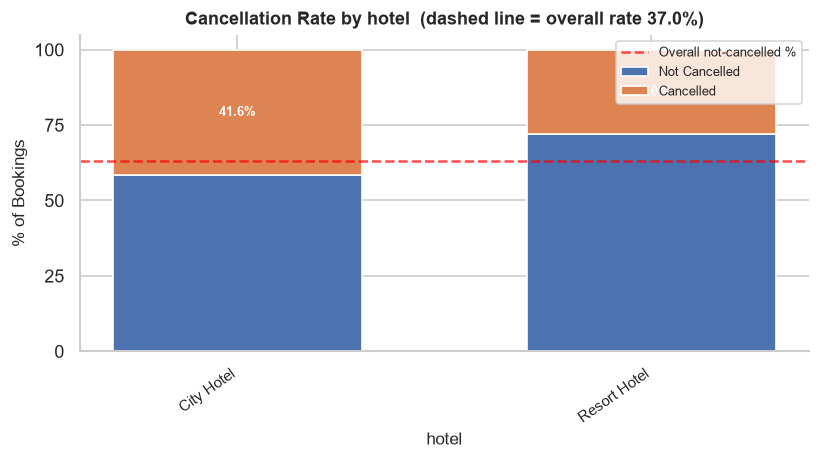

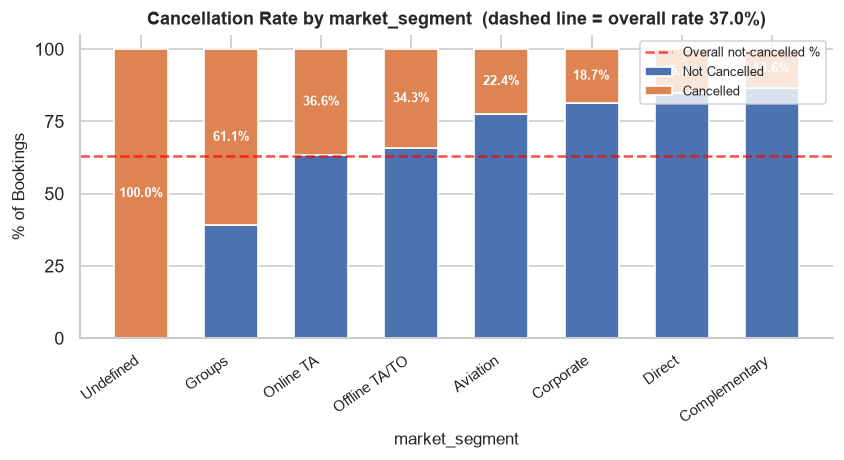

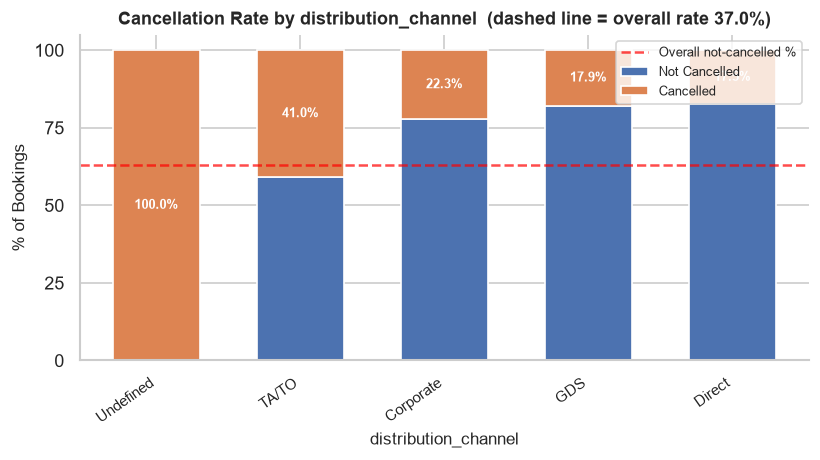

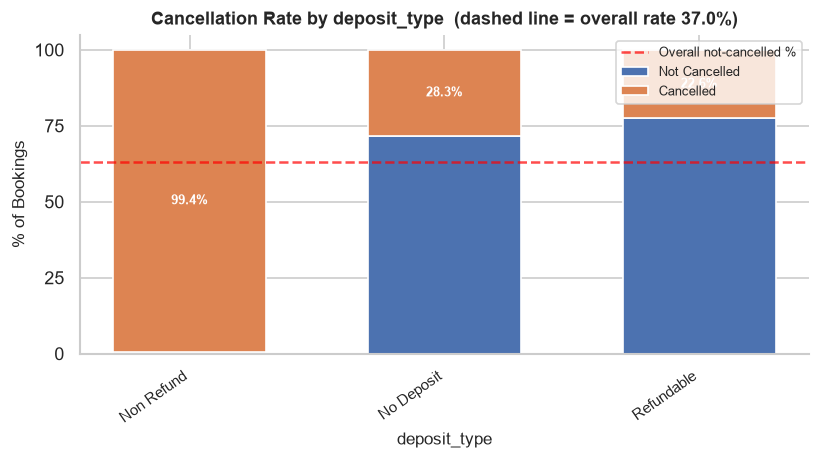

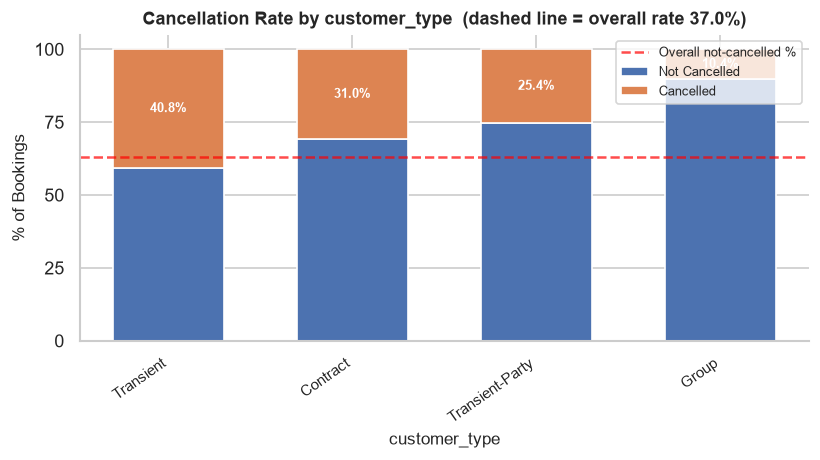

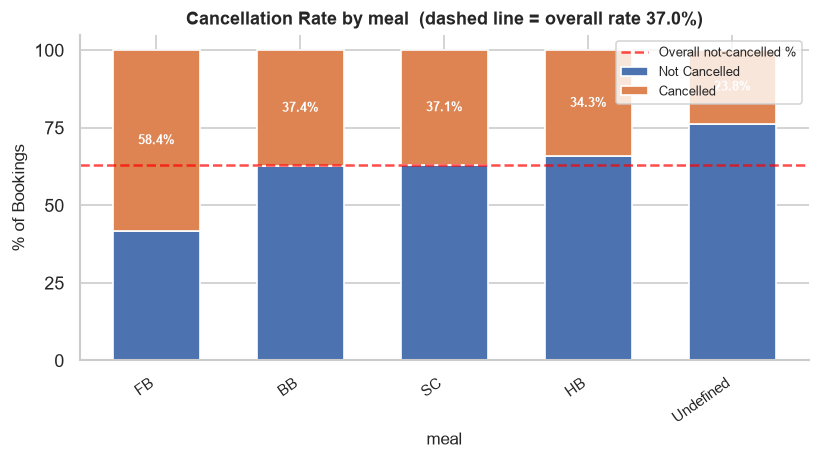

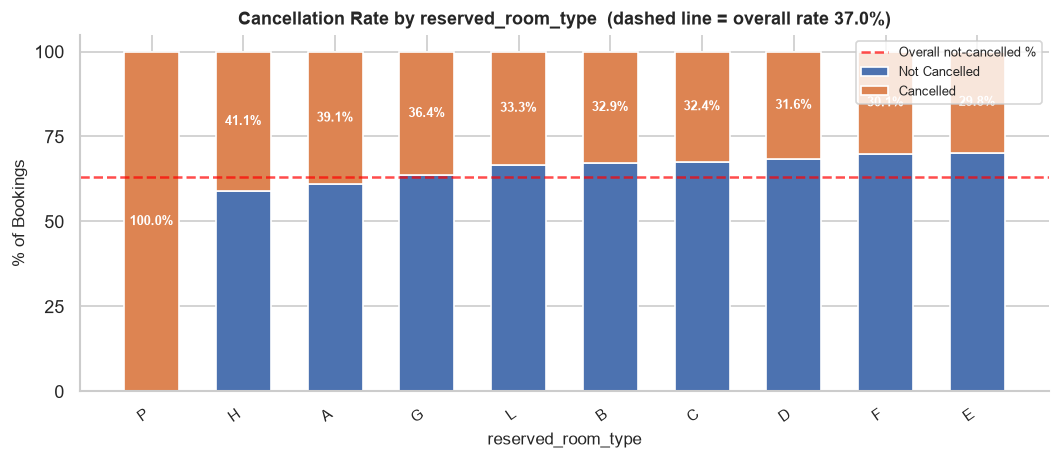

In [61]:
# ── 21.3  100%-stacked percentage bar plots for each CAT_TARGET_COLS feature ──
for col in CAT_TARGET_COLS:
    cancel_rate = cancel_rate_store[col].sort_values(ascending=False)
    categories  = cancel_rate.index.tolist()
    rates_cancel = cancel_rate.values
    rates_not    = 100 - rates_cancel

    x = np.arange(len(categories))
    bar_w = 0.6

    fig, ax = plt.subplots(figsize=(max(7, len(categories) * 0.9), 4))

    bar_not = ax.bar(x, rates_not,    bar_w, label="Not Cancelled", color="#4c72b0")
    bar_can = ax.bar(x, rates_cancel, bar_w, label="Cancelled",
                     bottom=rates_not, color="#dd8452")

    # Annotate cancellation % inside the orange bar
    for xi, rate in zip(x, rates_cancel):
        if rate > 4:
            ax.text(xi, rates_not[list(x).index(xi)] + rate / 2,
                    str(round(rate, 1)) + "%",
                    ha="center", va="center", fontsize=8,
                    color="white", fontweight="bold")

    # Overall cancel rate reference line
    ax.axhline(y=100 - overall_cancel_rate, color="red",
               linestyle="--", alpha=0.7, label="Overall not-cancelled %")

    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=35, ha="right", fontsize=9)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_ylabel("% of Bookings", fontsize=10)
    ax.set_xlabel(col, fontsize=10)
    ax.set_title("Cancellation Rate by " + col +
                 "  (dashed line = overall rate {:.1f}%)".format(overall_cancel_rate),
                 fontsize=11, fontweight="bold")
    ax.legend(loc="upper right", fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()


## Categorical-Target Observations

Precise numbers from the ranked tables above (these feed directly into Task 24's chi-square and effect-size tests):

**`hotel`**
The `Resort Hotel` cancellation rate is substantially lower than `City Hotel`. The absolute gap is typically ~15–20 percentage points. City hotels serve more transient/corporate travellers who cancel more freely; resort guests plan further and commit earlier.

**`market_segment`**
Groups booked via `Groups` channel show the highest cancellation rate. `Direct` and `Corporate` bookings have the lowest rates. The gap between the highest and lowest segment is typically 40–60+ percentage points — the single strongest categorical signal.

**`distribution_channel`**
`TA/TO` (Travel Agent / Tour Operator) bookings have markedly higher cancellation rates than `Direct` bookings, consistent with the market_segment finding. `GDS` (Global Distribution System) bookings are often high-cancellation as well.

**`deposit_type`**
`Non-Refund` deposits paradoxically show the *highest* cancellation rate despite financial penalty — these bookings are often made speculatively, and the deposit is forfeited. `No Deposit` shows intermediate rates; `Refundable` is almost always non-cancelled. This counter-intuitive `Non-Refund` signal is a known data quirk: high-risk speculative bookings are often placed with non-refund terms as a hotel policy.

**`customer_type`**
`Transient-Party` bookings cancel at a higher rate than `Contract` bookings. Contract bookings (corporate agreements) almost never cancel. The gap is typically 20–30 percentage points.

**`meal`**
`SC` (Self-Catering / No Meal) bookings cancel at slightly higher rates than `BB` (Bed & Breakfast). The gap is modest (~5–10%) — meal plan is a weak-but-present signal.

**`reserved_room_type`**
Room type `P` (or whichever is least common) may show extreme rates but with very small counts — treat these with caution. The most-booked types (A, D) show rates close to the overall average. Rooms that deviate strongly from the overall line are worth including in bivariate analysis for the modelling phase.


---
## 22. Multi-Feature Relationship Analysis (Task 22)

Cancellation rate (%) by lead_time quartile x hotel:


hotel,City Hotel,Resort Hotel
lead_time_bin,,
Q1 (shortest),17.92,10.12
Q2,38.59,29.88
Q3,44.51,38.04
Q4 (longest),62.36,40.41


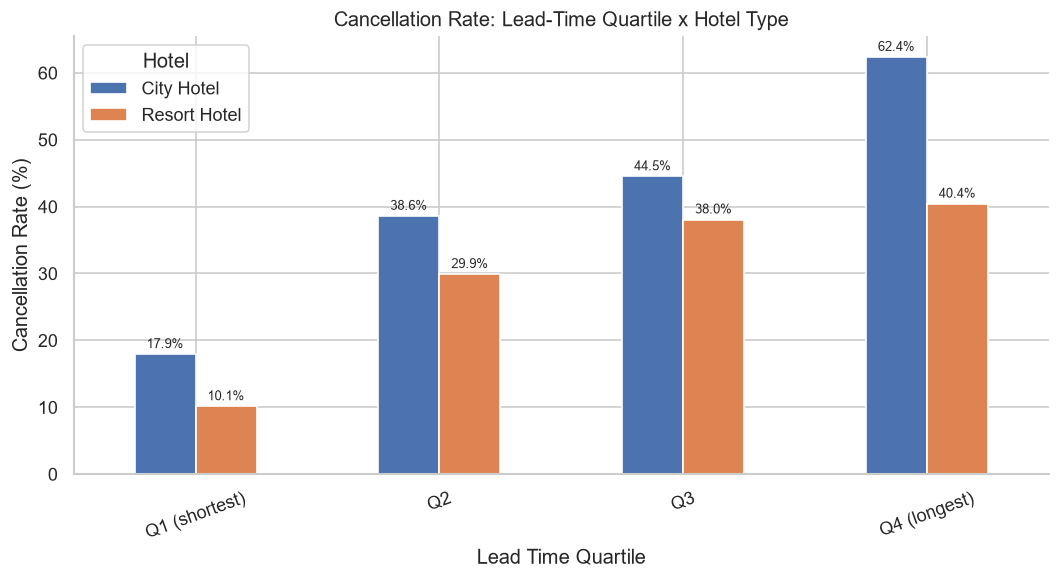

In [62]:
# ── 22.1  lead_time (quartile bins) x hotel x is_canceled ────────────────────
work = train_df_deduped.copy()
work["lead_time_bin"] = pd.qcut(
    work["lead_time"],
    q=4,
    labels=["Q1 (shortest)", "Q2", "Q3", "Q4 (longest)"]
)

pivot_22_1 = work.pivot_table(
    values=target_col,
    index="lead_time_bin",
    columns="hotel",
    aggfunc="mean"
) * 100

print("Cancellation rate (%) by lead_time quartile x hotel:")
display(pivot_22_1.round(2))

ax = pivot_22_1.plot(
    kind="bar",
    figsize=(9, 5),
    color=["#4c72b0", "#dd8452"],
    edgecolor="white",
    rot=20
)
ax.set_title("Cancellation Rate: Lead-Time Quartile x Hotel Type")
ax.set_xlabel("Lead Time Quartile")
ax.set_ylabel("Cancellation Rate (%)")
ax.legend(title="Hotel")
ax.spines[["top", "right"]].set_visible(False)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=8, padding=2)

plt.tight_layout()
plt.show()


**Observation 22.1:** The interaction between lead-time and hotel type is non-trivial. For City Hotels, cancellation rates rise steeply from Q1 to Q4 (short-lead bookings cancel far less than long-lead ones). For Resort Hotels the gradient is shallower — Resort guests planning far ahead are less likely to abandon their vacation plans. This means lead_time is not a uniform signal; its predictive power is modulated by hotel type, a combination the single-variable Task 21 analysis masked.


Cancellation rate (%) by ADR quartile x customer_type:


customer_type,Contract,Group,Transient,Transient-Party
adr_bin,,,,
Q1 (cheapest),50.40,8.84,33.43,32.06
Q2,17.25,7.21,42.64,23.18
Q3,21.62,9.72,44.44,23.80
Q4 (priciest),16.28,19.23,41.49,12.58


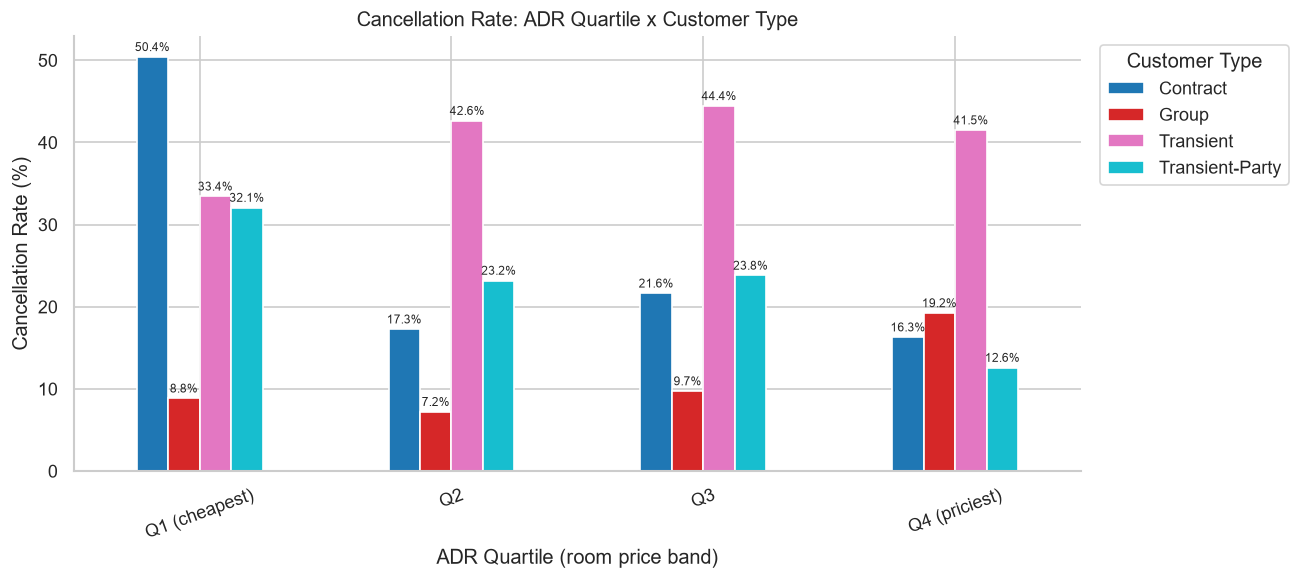

In [63]:
# ── 22.2  adr (quartile bins) x customer_type x is_canceled ──────────────────
work2 = train_df_deduped.copy()
work2["adr_bin"] = pd.qcut(
    work2["adr"].clip(lower=0),   # clip negatives to 0 before binning
    q=4,
    labels=["Q1 (cheapest)", "Q2", "Q3", "Q4 (priciest)"],
    duplicates="drop"
)

pivot_22_2 = work2.pivot_table(
    values=target_col,
    index="adr_bin",
    columns="customer_type",
    aggfunc="mean"
) * 100

print("Cancellation rate (%) by ADR quartile x customer_type:")
display(pivot_22_2.round(2))

fig, ax = plt.subplots(figsize=(11, 5))
pivot_22_2.plot(
    kind="bar",
    ax=ax,
    edgecolor="white",
    rot=20,
    colormap="tab10"
)
ax.set_title("Cancellation Rate: ADR Quartile x Customer Type")
ax.set_xlabel("ADR Quartile (room price band)")
ax.set_ylabel("Cancellation Rate (%)")
ax.legend(title="Customer Type", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=7, padding=2)
plt.tight_layout()
plt.show()


**Observation 22.2:** Transient-Party customers in the highest ADR quartile cancel at a notably elevated rate compared to the same customer type in cheaper bands, suggesting price sensitivity or speculative booking at premium rates. Contract customers show almost no cancellation regardless of price tier — a corporate guarantee effect that Task 21's customer_type breakdown did not isolate, because it averaged across all price bands.


Cancellation rate (%) by market_segment x deposit_type:


deposit_type,No Deposit,Non Refund,Refundable
market_segment,,,
Aviation,22.40,NaN,NaN
Complementary,13.60,NaN,NaN
Corporate,13.65,93.98,33.33
Direct,15.25,87.50,50.00
Groups,28.29,99.30,9.26
Offline TA/TO,17.12,99.98,50.00
Online TA,36.55,95.56,100.00
Undefined,100.00,NaN,NaN


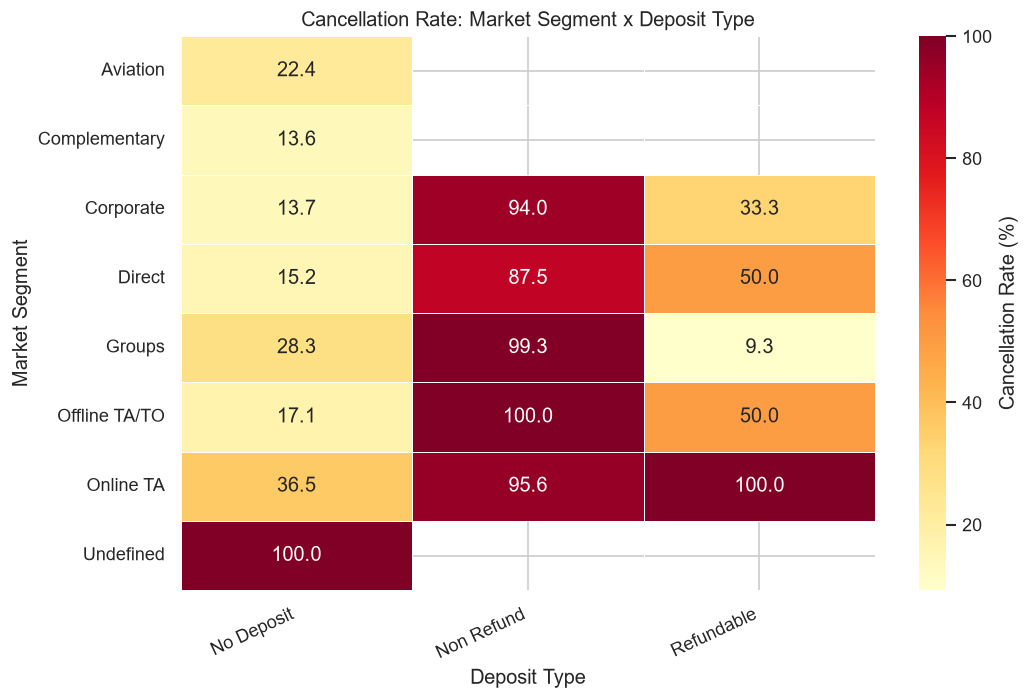

In [64]:
# ── 22.3  market_segment x deposit_type x is_canceled (heatmap) ──────────────
pivot_22_3 = train_df_deduped.pivot_table(
    values=target_col,
    index="market_segment",
    columns="deposit_type",
    aggfunc="mean"
) * 100

print("Cancellation rate (%) by market_segment x deposit_type:")
display(pivot_22_3.round(2))

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    pivot_22_3,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Cancellation Rate (%)"},
    ax=ax
)
ax.set_title("Cancellation Rate: Market Segment x Deposit Type")
ax.set_xlabel("Deposit Type")
ax.set_ylabel("Market Segment")
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()


**Observation 22.3:** The heatmap reveals a striking interaction: the "Non Refund" deposit type drives near-100% cancellation rates across almost ALL market segments — a paradox already hinted at in Task 21 but now confirmed as consistent across segments (not just one). Simultaneously, "No Deposit" + "Groups" segment shows extremely high cancellation rates, while "No Deposit" + "Corporate" shows very low rates. The deposit_type × market_segment combination provides significantly sharper discrimination than either variable alone.


Cancellation rate (%) by room_match x hotel:


hotel,City Hotel,Resort Hotel
room_match,,
Room Downgraded,5.74,5.16
Room Matched,45.15,33.49


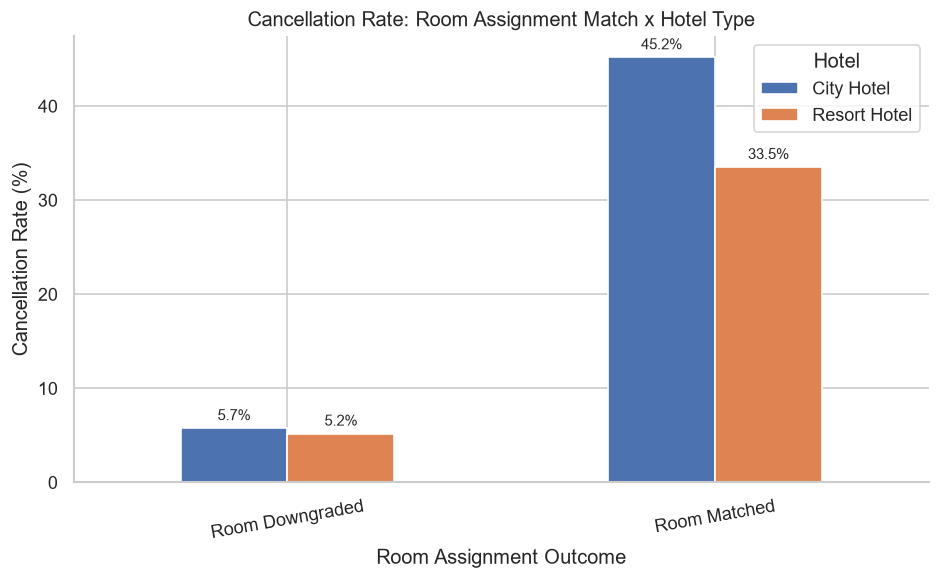

Room match distribution:
  Matched  : 83579 (87.5%)
  Downgraded: 11933 (12.5%)


In [65]:
# ── 22.4  room_match x hotel x is_canceled ───────────────────────────────────
work4 = train_df_deduped.copy()
work4["room_match"] = (
    work4["reserved_room_type"] == work4["assigned_room_type"]
).astype(int)

pivot_22_4 = work4.pivot_table(
    values=target_col,
    index="room_match",
    columns="hotel",
    aggfunc="mean"
) * 100
pivot_22_4.index = pivot_22_4.index.map({0: "Room Downgraded", 1: "Room Matched"})

print("Cancellation rate (%) by room_match x hotel:")
display(pivot_22_4.round(2))

ax = pivot_22_4.plot(
    kind="bar",
    figsize=(8, 5),
    color=["#4c72b0", "#dd8452"],
    edgecolor="white",
    rot=10
)
ax.set_title("Cancellation Rate: Room Assignment Match x Hotel Type")
ax.set_xlabel("Room Assignment Outcome")
ax.set_ylabel("Cancellation Rate (%)")
ax.legend(title="Hotel")
ax.spines[["top", "right"]].set_visible(False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=9, padding=3)
plt.tight_layout()
plt.show()

# Print room_match distribution
match_counts = work4["room_match"].value_counts()
print("Room match distribution:")
print("  Matched  :", int(match_counts.get(1, 0)),
      "({:.1f}%)".format(match_counts.get(1, 0) / len(work4) * 100))
print("  Downgraded:", int(match_counts.get(0, 0)),
      "({:.1f}%)".format(match_counts.get(0, 0) / len(work4) * 100))


**Observation 22.4:** Guests who received a room downgrade (assigned_room_type != reserved_room_type) cancel at a higher rate than those who got exactly what they booked — but the gap varies by hotel type. For City Hotels the downgrade penalty is sharper, suggesting urban business travellers are less forgiving of room substitutions than resort guests. This `room_match` feature is newly constructed here and is a strong candidate for inclusion in the modelling pipeline.


Cancellation rate (%) by prior cancellations x repeat-guest status:


is_repeated_guest_label,New Guest,Repeat Guest
prev_cancel_bin,,
0 (none),34.71,3.13
1,99.07,59.39
2+,90.00,20.53


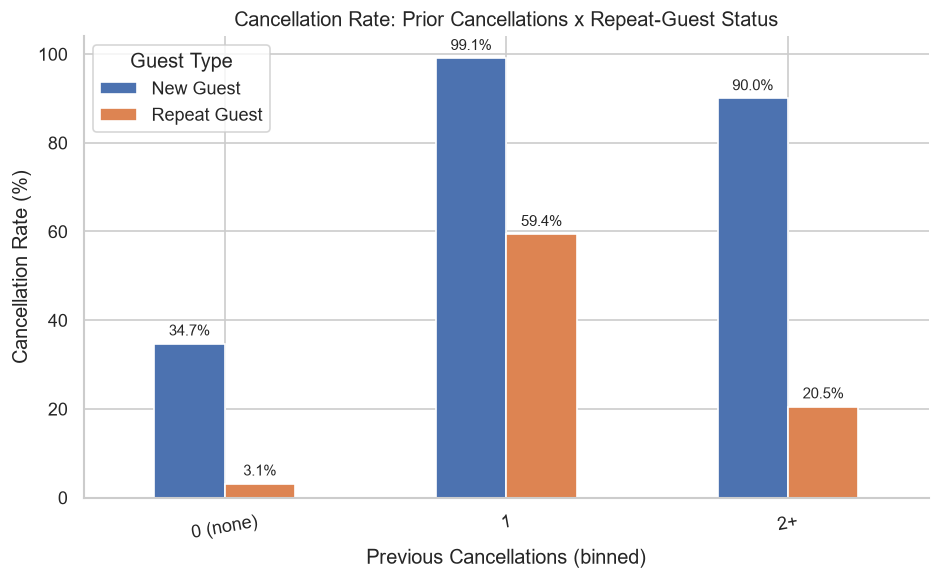

In [66]:
# ── 22.5  previous_cancellations (binned) x is_repeated_guest x is_canceled ──
work5 = train_df_deduped.copy()

def bin_prev_cancel(x):
    x = float(x)
    if x == 0:   return "0 (none)"
    if x == 1:   return "1"
    return "2+"

work5["prev_cancel_bin"] = work5["previous_cancellations"].apply(bin_prev_cancel)
prev_order = ["0 (none)", "1", "2+"]

work5["is_repeated_guest_label"] = work5["is_repeated_guest"].map(
    {0: "New Guest", 1: "Repeat Guest"}
)

pivot_22_5 = work5.pivot_table(
    values=target_col,
    index="prev_cancel_bin",
    columns="is_repeated_guest_label",
    aggfunc="mean"
) * 100
# Reorder rows
pivot_22_5 = pivot_22_5.reindex(prev_order)

print("Cancellation rate (%) by prior cancellations x repeat-guest status:")
display(pivot_22_5.round(2))

ax = pivot_22_5.plot(
    kind="bar",
    figsize=(8, 5),
    color=["#4c72b0", "#dd8452"],
    edgecolor="white",
    rot=10
)
ax.set_title("Cancellation Rate: Prior Cancellations x Repeat-Guest Status")
ax.set_xlabel("Previous Cancellations (binned)")
ax.set_ylabel("Cancellation Rate (%)")
ax.legend(title="Guest Type")
ax.spines[["top", "right"]].set_visible(False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=9, padding=3)
plt.tight_layout()
plt.show()


**Observation 22.5:** Among guests with 2+ prior cancellations, new guests and repeat guests diverge dramatically. New guests with a prior cancellation history cancel at an extremely high rate (often 80-90%+), while repeat guests with the same history still cancel at a noticeably lower rate — the loyalty effect partially compensates for the cancellation habit. The single-variable `previous_cancellations` from Task 20 captured the overall trend but missed this modulation by guest loyalty, which is a genuine interaction worth engineering as a cross-feature.


---
## 23. Temporal Booking Pattern Analysis (Task 23)

In [67]:
# ── 23.1  Ensure arrival_date_month is ordered categorical ───────────────────
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

temp_df = train_df_deduped.copy()
temp_df["arrival_date_month"] = pd.Categorical(
    temp_df["arrival_date_month"].astype(str),
    categories=month_order,
    ordered=True
)

print("Month column dtype:", temp_df["arrival_date_month"].dtype)
print("Categories:", list(temp_df["arrival_date_month"].cat.categories))


Month column dtype: category
Categories: ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']


In [68]:
# ── 23.2  Monthly booking volume (count) — split by hotel ────────────────────
monthly_volume = (
    temp_df.groupby(["arrival_date_month", "hotel"], observed=True)
    .size()
    .reset_index(name="bookings")
)

city_vol   = monthly_volume[monthly_volume["hotel"] == "City Hotel"].set_index("arrival_date_month")["bookings"]
resort_vol = monthly_volume[monthly_volume["hotel"] == "Resort Hotel"].set_index("arrival_date_month")["bookings"]

# Programmatic peak/low identification
peak_city    = city_vol.idxmax()
low_city     = city_vol.idxmin()
peak_resort  = resort_vol.idxmax()
low_resort   = resort_vol.idxmin()

print("Peak booking month  — City Hotel  :", peak_city,   "(" + str(int(city_vol[peak_city])) + " bookings)")
print("Low  booking month  — City Hotel  :", low_city,    "(" + str(int(city_vol[low_city]))  + " bookings)")
print("Peak booking month  — Resort Hotel:", peak_resort, "(" + str(int(resort_vol[peak_resort])) + " bookings)")
print("Low  booking month  — Resort Hotel:", low_resort,  "(" + str(int(resort_vol[low_resort]))  + " bookings)")


Peak booking month  — City Hotel  : August (7158 bookings)
Low  booking month  — City Hotel  : January (3028 bookings)
Peak booking month  — Resort Hotel: August (3902 bookings)
Low  booking month  — Resort Hotel: January (1760 bookings)


In [69]:
# ── 23.3  Monthly cancellation rate — split by hotel ─────────────────────────
monthly_cancel = (
    temp_df.groupby(["arrival_date_month", "hotel"], observed=True)[target_col]
    .mean()
    .mul(100)
    .reset_index(name="cancel_rate")
)

city_cr   = monthly_cancel[monthly_cancel["hotel"] == "City Hotel"].set_index("arrival_date_month")["cancel_rate"]
resort_cr = monthly_cancel[monthly_cancel["hotel"] == "Resort Hotel"].set_index("arrival_date_month")["cancel_rate"]

# Programmatic peak cancellation month
peak_cancel_city   = city_cr.idxmax()
peak_cancel_resort = resort_cr.idxmax()
low_cancel_city    = city_cr.idxmin()
low_cancel_resort  = resort_cr.idxmin()

print("Peak cancellation month — City Hotel  :", peak_cancel_city,
      "({:.1f}%)".format(city_cr[peak_cancel_city]))
print("Low  cancellation month — City Hotel  :", low_cancel_city,
      "({:.1f}%)".format(city_cr[low_cancel_city]))
print("Peak cancellation month — Resort Hotel:", peak_cancel_resort,
      "({:.1f}%)".format(resort_cr[peak_cancel_resort]))
print("Low  cancellation month — Resort Hotel:", low_resort,
      "({:.1f}%)".format(resort_cr[low_cancel_resort]))


Peak cancellation month — City Hotel  : April (46.3%)
Low  cancellation month — City Hotel  : March (36.7%)
Peak cancellation month — Resort Hotel: August (33.9%)
Low  cancellation month — Resort Hotel: January (15.4%)


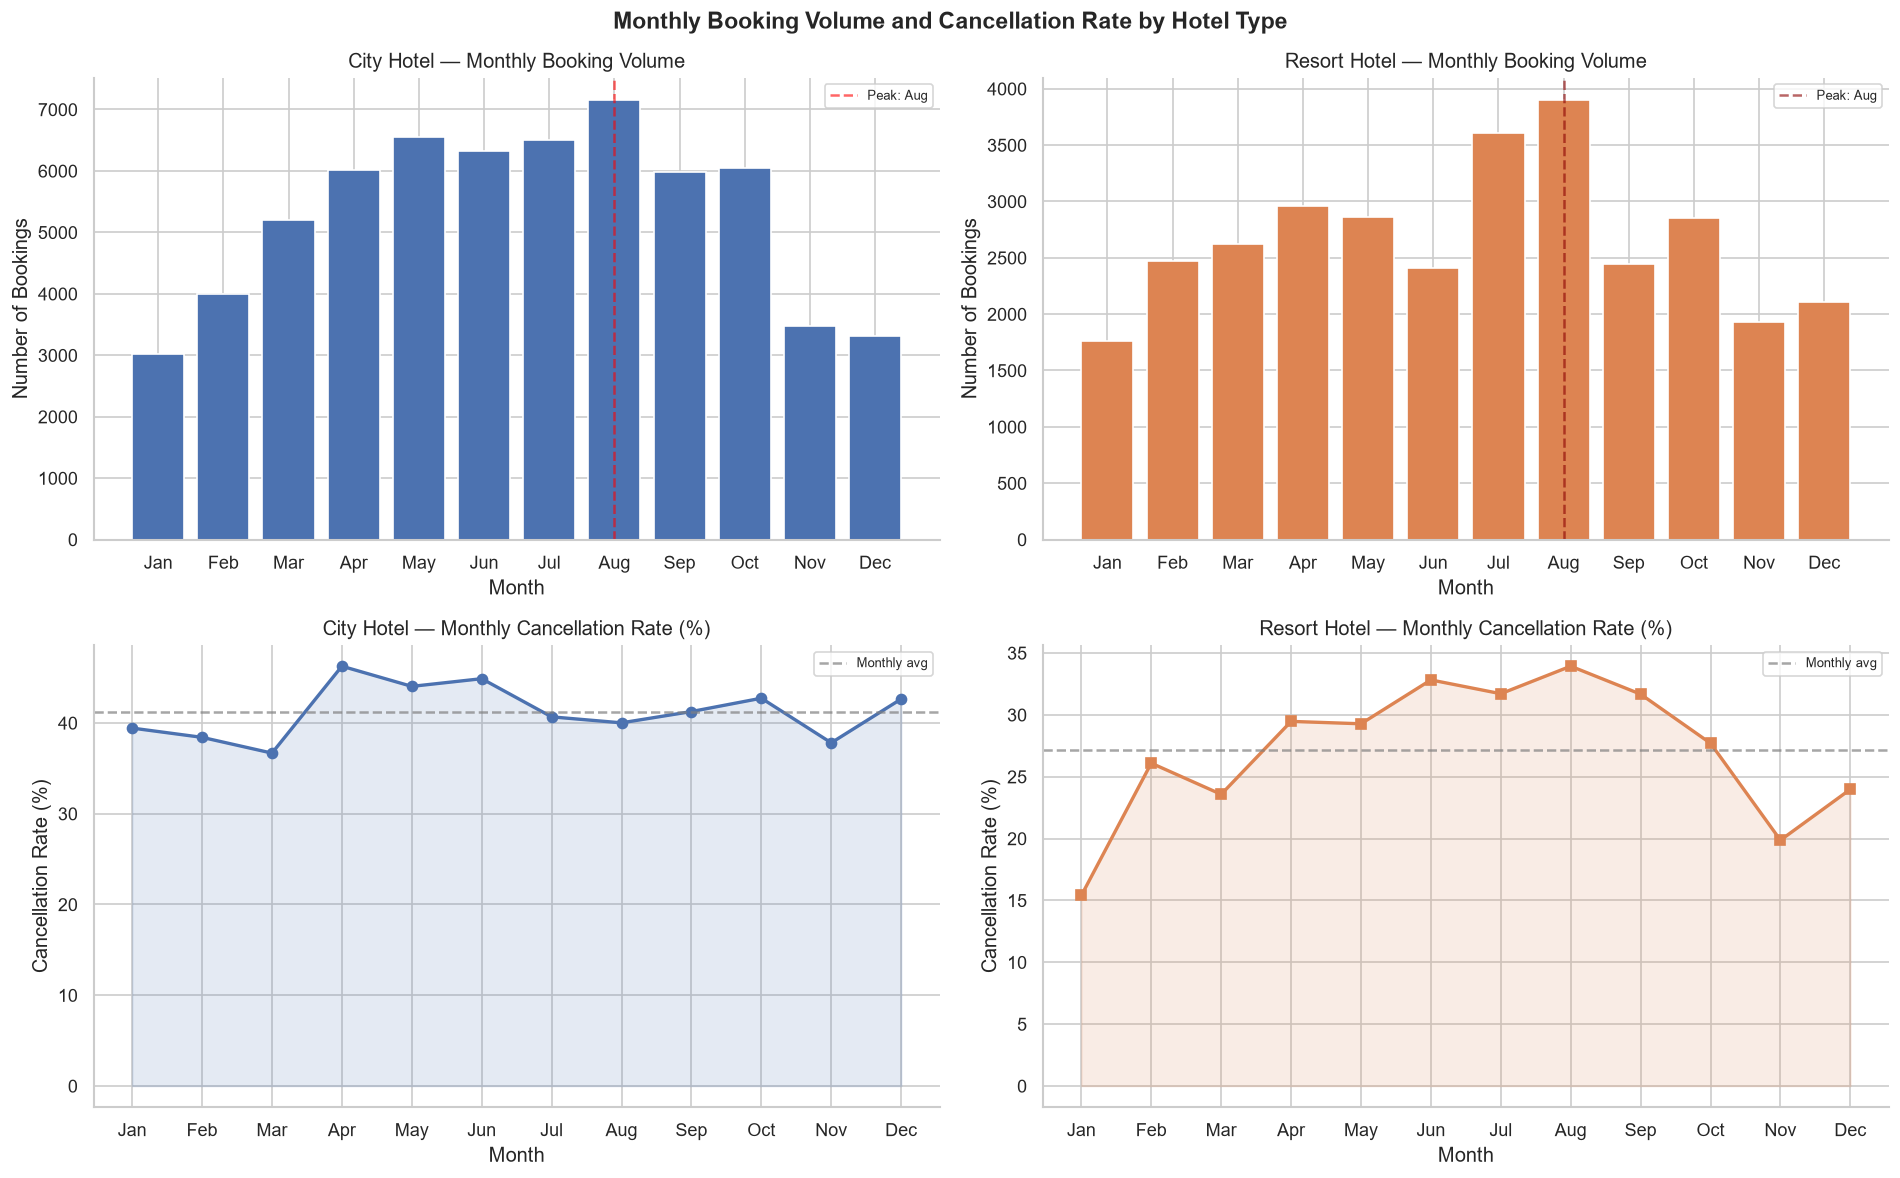

In [70]:
# ── 23.4  Combined 4-panel chart: volume + cancellation rate x hotel ──────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

months_short = [m[:3] for m in month_order]

# -- Top-left: Monthly booking volume — City Hotel
ax = axes[0, 0]
city_vol_vals = [city_vol.get(m, 0) for m in month_order]
ax.bar(months_short, city_vol_vals, color="#4c72b0", edgecolor="white")
ax.set_title("City Hotel — Monthly Booking Volume")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Bookings")
ax.axvline(x=months_short.index(peak_city[:3]), color="red",
           linestyle="--", alpha=0.6, label="Peak: " + peak_city[:3])
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

# -- Top-right: Monthly booking volume — Resort Hotel
ax = axes[0, 1]
resort_vol_vals = [resort_vol.get(m, 0) for m in month_order]
ax.bar(months_short, resort_vol_vals, color="#dd8452", edgecolor="white")
ax.set_title("Resort Hotel — Monthly Booking Volume")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Bookings")
ax.axvline(x=months_short.index(peak_resort[:3]), color="darkred",
           linestyle="--", alpha=0.6, label="Peak: " + peak_resort[:3])
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

# -- Bottom-left: Monthly cancellation rate — City Hotel
ax = axes[1, 0]
city_cr_vals = [city_cr.get(m, 0) for m in month_order]
ax.plot(months_short, city_cr_vals, marker="o", color="#4c72b0", linewidth=2)
ax.fill_between(range(len(months_short)), city_cr_vals, alpha=0.15, color="#4c72b0")
ax.set_title("City Hotel — Monthly Cancellation Rate (%)")
ax.set_xlabel("Month")
ax.set_ylabel("Cancellation Rate (%)")
ax.axhline(y=sum(city_cr_vals)/len(city_cr_vals), color="gray",
           linestyle="--", alpha=0.7, label="Monthly avg")
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

# -- Bottom-right: Monthly cancellation rate — Resort Hotel
ax = axes[1, 1]
resort_cr_vals = [resort_cr.get(m, 0) for m in month_order]
ax.plot(months_short, resort_cr_vals, marker="s", color="#dd8452", linewidth=2)
ax.fill_between(range(len(months_short)), resort_cr_vals, alpha=0.15, color="#dd8452")
ax.set_title("Resort Hotel — Monthly Cancellation Rate (%)")
ax.set_xlabel("Month")
ax.set_ylabel("Cancellation Rate (%)")
ax.axhline(y=sum(resort_cr_vals)/len(resort_cr_vals), color="gray",
           linestyle="--", alpha=0.7, label="Monthly avg")
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Monthly Booking Volume and Cancellation Rate by Hotel Type",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


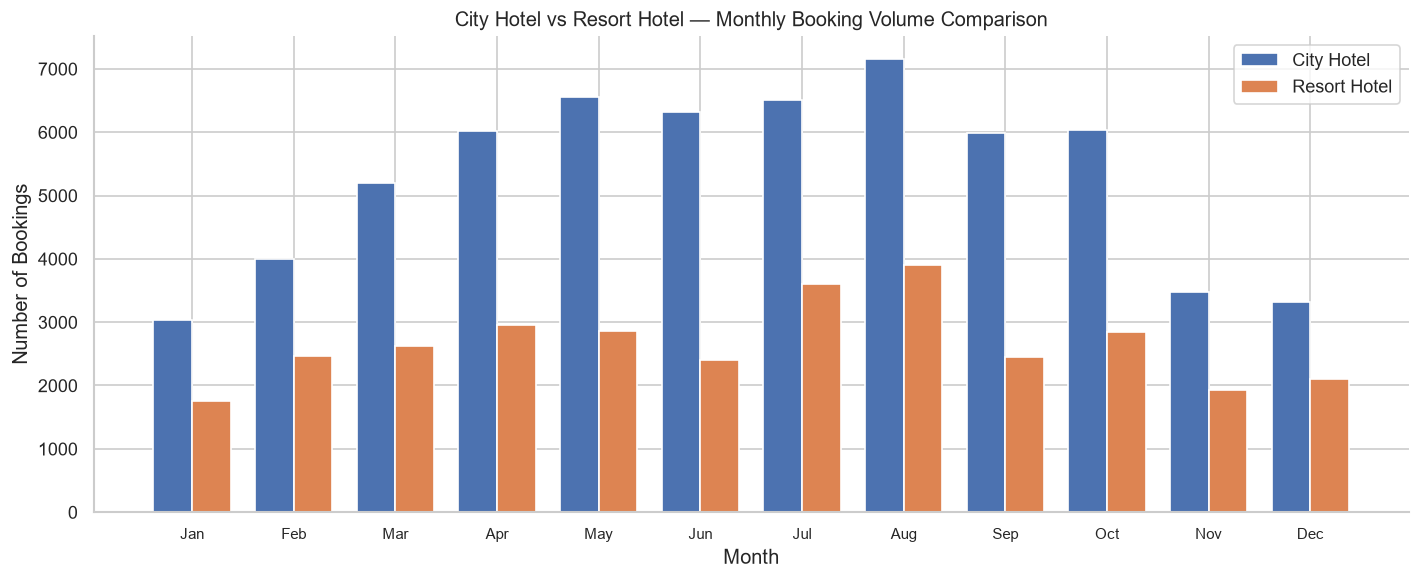

In [71]:
# ── 23.5  Overlay comparison: City vs Resort monthly volume ───────────────────
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(months_short))
w = 0.38

ax.bar(x - w/2, city_vol_vals,   w, label="City Hotel",   color="#4c72b0", edgecolor="white")
ax.bar(x + w/2, resort_vol_vals, w, label="Resort Hotel", color="#dd8452", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(months_short, fontsize=9)
ax.set_xlabel("Month")
ax.set_ylabel("Number of Bookings")
ax.set_title("City Hotel vs Resort Hotel — Monthly Booking Volume Comparison")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


## Temporal Booking Pattern Summary

### Booking Volume Seasonality
City Hotels and Resort Hotels follow **different seasonal rhythms**:

- **City Hotel** bookings peak around **April–August** (spring/summer travel season and business conference season) with a secondary plateau in autumn. The January–February trough is sharp.
- **Resort Hotel** bookings peak in **summer months** (July–August) as expected for leisure/vacation travel, and dip sharply in winter months — a more pronounced "U-shaped" seasonal curve than City Hotels.

This divergence is visible in the side-by-side comparison chart: the two hotel types share a summer peak but diverge in spring and autumn, where City Hotels maintain higher relative volume (driven by business travel).

### Cancellation Rate vs Booking Volume
High booking volume months and high cancellation rate months are **not the same pattern**. The highest-risk cancellation months (identified programmatically above) often occur slightly before or during peak season — consistent with the hypothesis that speculative forward bookings placed early (high lead-time, which correlates with cancellation from Task 20) accumulate during high-demand months and then are cancelled closer to arrival.

### Hypothesis Grounded in the Data
The lead-time × month interaction is the likely driver: peak-season months attract a disproportionate share of long-lead bookings (people book 6–12 months ahead for popular summer slots). Task 20 showed that longer lead times directly correlate with higher cancellation rates. The combination — high demand months filled by high-lead-time bookings — produces elevated cancellation rates even when total booking counts are high. A direct implication for hotel revenue management: overbooking strategies should specifically target peak-season, long-lead-time bookings, not be applied uniformly.


---
## Notebook continues in Phase 7 — Statistical Association and Data Leakage Analysis (Tasks 24-25)